In [1]:
import numpy as np
import pandas as pd
import emukit
import GPy
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_film = pd.read_excel('...', sheet_name='11_30_film')
print(df_film.columns)
df_film.columns = ['ML Condition', 'Number', 'Speed [mm/s]',
       'Power [%]', 'Frequency [KHz]', 'Spacing [mm]', 'Type',
       'Success or Fail', 'Notes']
success_conditions = df_film[df_film['Success or Fail']==1]['ML Condition'].values
df_film.iloc[:,:-1]

Index(['ML Condition', 'Number', 'Speed [mm/s]', 'Power [%]',
       'Frequency [KHz]', 'Spacing [mm]', 'Type', 'Success or Fail', 'Notes'],
      dtype='object')


,ML Condition,Number,Speed [mm/s],Power [%],Frequency [KHz],Spacing [mm],Type,Success or Fail
0,1,1,200,70,10,0.01,3,1
1,2,1,900,40,20,0.05,3,1
2,3,1,1000,30,30,0.01,3,1
3,4,2,100,20,20,0.11,2,0
4,5,2,600,30,20,0.07,2,1
5,6,2,900,10,30,0.09,3,0
6,7,3,300,100,20,0.03,1,1
7,8,3,1000,40,20,0.13,2,1
8,9,4,100,30,10,0.15,2,1
9,10,4,1000,60,20,0.11,3,1


In [3]:
df_csc = pd.read_excel('...', sheet_name='11_30_csc')
print(df_csc.columns)
df_csc.columns = ['ML Condition', 'Number', 'Speed [mm/s]',
       'Power [%]', 'Frequency [KHz]', 'Spacing [mm]', 'Type',
       'FDT [s]', 'RFDT']
df_csc = df_csc.sort_values(by=list(df_csc.iloc[:,[0,-1]].columns)).drop_duplicates('ML Condition', keep = 'last', ignore_index = True)
df_csc = df_csc[df_csc['ML Condition'].isin(success_conditions)]
df_csc

Index(['ML Condition', 'Number', 'Speed [mm/s]', 'Power [%]',
       'Frequency [KHz]', 'Spacing [mm]', 'Type', 'FDT [s]', 'RFDT'],
      dtype='object')


,ML Condition,Number,Speed [mm/s],Power [%],Frequency [KHz],Spacing [mm],Type,FDT [s],RFDT
0,1,1,200,70,10,0.01,3,54.81,2.16
1,2,1,900,40,20,0.05,3,305.71,12.05
2,3,1,1000,30,30,0.01,3,126.34,4.98
4,5,2,600,30,20,0.07,2,271.46,10.70
6,7,3,300,100,20,0.03,1,120.25,4.74
7,8,3,1000,40,20,0.13,2,114.67,4.52
8,9,4,100,30,10,0.15,2,385.12,15.18
9,10,4,1000,60,20,0.11,3,343.26,13.53
11,12,5,1000,50,10,0.05,1,354.93,13.99
12,13,8,700,90,10,0.11,2,399.32,15.74


In [4]:
df_preliminary  = pd.read_excel('...', sheet_name='Sheet1')
print(df_preliminary.columns)
df_preliminary.columns = ['', 'Number', 'Speed [mm/s]',
       'Power [%]', 'Frequency [KHz]', 'Spacing [mm]', 'Type',
       'FDT [s]', 'RFDT']
df_preliminary = df_preliminary.iloc[:,1:]
df_preliminary

Index(['ML Condition', 'Number', 'Speed [mm/s]', 'Power [%]',
       'Frequency [kHz]', 'Spacing [mm]', 'Type', 'FDT [s]', 'RFDT'],
      dtype='object')


,Number,Speed [mm/s],Power [%],Frequency [KHz],Spacing [mm],Type,FDT [s],RFDT
0,8,400,80,40,0.05,1,166.46,6.56
1,3,100,60,10,0.09,1,146.13,5.76
2,5,700,40,50,0.11,1,140.51,5.54
3,1,1500,40,30,0.05,1,166.31,6.56
4,7,700,90,30,0.05,1,319.45,12.59
5,2,1500,50,50,0.07,1,116.23,4.58
6,1,1000,30,20,0.15,1,297.52,11.73
7,9,800,70,10,0.07,1,373.46,14.72
8,7,300,90,10,0.01,1,257.03,10.13
9,4,900,60,50,0.13,1,316.50,12.48


In [5]:
numb_min, numb_max, numb_step = [1, 10, 1]
numb_var = np.arange(numb_min, numb_max+numb_step, numb_step)
numb_num = len(numb_var)

speed_min, speed_max, speed_step = [100, 1500, 100]
speed_var = np.arange(speed_min, speed_max+speed_step, speed_step)
speed_num = len(speed_var)

power_min, power_max, power_step = [10, 100, 10]
power_var = np.arange(power_min, power_max+power_step, power_step) 
power_num = len(power_var)

freq_min, freq_max, freq_step = [10, 50, 10]
freq_var = np.arange(freq_min, freq_max+freq_step, freq_step)
freq_num = len(freq_var)

spac_min, spac_max, spac_step = [0.01, 0.15, 0.02]
spac_var = np.arange(spac_min, spac_max+spac_step, spac_step)
spac_num = len(spac_var)

type_min, type_max, type_step = [1, 3, 1]
type_var = np.arange(type_min, type_max+type_step, type_step)
type_num = len(type_var)


var_array = [numb_var, speed_var, 
             power_var, freq_var, 
             spac_var, type_var]
x_labels = ['Number', 
            'Speed [mm/s]',
            'Power [%]', 
            'Frequency [KHz]', 
            'Spacing [mm]', 
            'Type']
def x_normalizer(X):
    
    def max_min_scaler(x, x_max, x_min):
        return (x-x_min)/(x_max-x_min)
    
    x_norm = []
    for x in (X):
           x_norm.append([max_min_scaler(x[i], 
                                         max(var_array[i]), 
                                         min(var_array[i])) for i in range(len(x))])  
    return np.array(x_norm)

def x_denormalizer(x_norm):
    def max_min_rescaler(x, x_max, x_min):
        return x*(x_max-x_min)+x_min
    
    x_original = []
    for x in (x_norm):
           x_original.append([max_min_rescaler(x[i], 
                                         max(var_array[i]), 
                                         min(var_array[i])) for i in range(len(x))])
    return np.array(x_original)


def get_closest_array(suggested_x):
    
    def get_closest_value(given_value, array_list):
        absolute_difference_function = lambda list_value : abs(list_value - given_value)
        closest_value = min(array_list, key=absolute_difference_function)
        return closest_value
    
    var_list = var_array
    modified_array = []
    for x in suggested_x:
        modified_array.append([get_closest_value(x[i], var_list[i]) for i in range(len(x))])
    return np.array(modified_array)

In [6]:
from emukit.core import ParameterSpace, ContinuousParameter, DiscreteParameter
from emukit.core.initial_designs.random_design import RandomDesign
from emukit.core.initial_designs.latin_design import LatinDesign

parameter_space = ParameterSpace([ContinuousParameter('numb', 0-1/(numb_num-1)/2, 1+1/(numb_num-1)/2),
                                 ContinuousParameter('speed', 0-1/(speed_num-1)/2, 1+1/(speed_num-1)/2),
                                 ContinuousParameter('power', 0-1/(power_num-1)/2, 1+1/(power_num-1)/2),
                                 ContinuousParameter('freq', 0-1/(freq_num-1)/2, 1+1/(freq_num-1)/2),
                                 ContinuousParameter('spac', 0-1/(spac_num-1)/2, 1+1/(spac_num-1)/2),
                                 ContinuousParameter('type', 0-1/(type_num-1)/2, 1+1/(type_num-1)/2)
                                 ])


In [7]:
from typing import Union
from emukit.core.acquisition import Acquisition
from emukit.core.interfaces import IModel, IDifferentiable
from emukit.core.loop import FixedIntervalUpdater, OuterLoop, SequentialPointCalculator
from emukit.core.loop.loop_state import create_loop_state
from emukit.core.optimization import AcquisitionOptimizerBase
from emukit.core.optimization import GradientAcquisitionOptimizer
from emukit.bayesian_optimization.acquisitions.log_acquisition import LogAcquisition
from emukit.bayesian_optimization.local_penalization_calculator import LocalPenalizationPointCalculator
from emukit.bayesian_optimization.acquisitions import ExpectedImprovement, \
                                                      NegativeLowerConfidenceBound, \
                                                      MaxValueEntropySearch, \
                                                      MultipointExpectedImprovement,\
                                                      ProbabilityOfFeasibility
from emukit.core.acquisition import IntegratedHyperParameterAcquisition

class ProbabilisticConstraintBayesianOptimizationLoop2(OuterLoop):
    def __init__(self, space: ParameterSpace, model_objective: Union[IModel, IDifferentiable],
                 model_constraint1: Union[IModel, IDifferentiable], 
                 model_constraint2: Union[IModel, IDifferentiable],
                 acquisition: Acquisition = None,
                 update_interval: int = 1, batch_size: int = 1):

        self.model_objective = model_objective
        self.model_constraint1 = model_constraint1
        self.model_constraint2 = model_constraint2
        
        if acquisition is None:
            acquisition = ExpectedImprovement(model_objective)
        
        acquisition_constraint1 = ScaledProbabilityOfFeasibility(model_constraint1, max_value = 1, min_value = 0.2)
        acquisition_constraint2 = ScaledProbabilityOfFeasibility(model_constraint2, max_value = 1, min_value = 0.8)
        acquisition_constraint = acquisition_constraint1*acquisition_constraint2
        acquisition_constrained = acquisition * acquisition_constraint

        model_updater_objective = FixedIntervalUpdater(model_objective, update_interval)
        model_updater_constraint1 = FixedIntervalUpdater(model_constraint1, update_interval,
                                                        lambda state: state.Y_constraint1)
        model_updater_constraint2 = FixedIntervalUpdater(model_constraint2, update_interval,
                                                        lambda state: state.Y_constraint2)

        acquisition_optimizer = GradientAcquisitionOptimizer(space)
        if batch_size == 1:
            candidate_point_calculator = SequentialPointCalculator(acquisition_constrained, acquisition_optimizer)
        else:
            log_acquisition = LogAcquisition(acquisition_constrained)
            candidate_point_calculator = LocalPenalizationPointCalculator(log_acquisition, acquisition_optimizer,
                                                                          model_objective, space, batch_size)
        loop_state = create_loop_state(model_objective.X, model_objective.Y)
        
        super(ProbabilisticConstraintBayesianOptimizationLoop2, self).__init__(candidate_point_calculator,
                                                                              [model_updater_objective, model_updater_constraint1,model_updater_constraint2],
                                                                              loop_state)


In [8]:
from typing import Tuple, Union
import scipy.stats
import numpy as np
from emukit.core.acquisition import Acquisition
from emukit.core.interfaces import IModel, IDifferentiable

class ScaledProbabilityOfFeasibility(Acquisition):

    def __init__(self, model: Union[IModel, IDifferentiable], jitter: float = float(0),
                 max_value: float = float(1), min_value: float = float(0)) -> None:
        self.model = model
        self.jitter = jitter
        self.max_value = max_value
        self.min_value = min_value

    def evaluate(self, x: np.ndarray) -> np.ndarray:
        mean, variance = self.model.predict(x)
        mean += self.jitter
        standard_deviation = np.sqrt(variance)
        cdf = scipy.stats.norm.cdf(0, mean, standard_deviation)
        return cdf*(self.max_value-self.min_value)+self.min_value

    def evaluate_with_gradients(self, x: np.ndarray) -> Tuple:
        mean, variance = self.model.predict(x)
        standard_deviation = np.sqrt(variance)
        dmean_dx, dvariance_dx = self.model.get_prediction_gradients(x)
        dstandard_devidation_dx = dvariance_dx / (2 * standard_deviation)
        mean += self.jitter
        u = - mean / standard_deviation
        pdf = scipy.stats.norm.pdf(0, mean, standard_deviation)
        cdf = scipy.stats.norm.cdf(0, mean, standard_deviation)
        dcdf_dx = - pdf * (dmean_dx + dstandard_devidation_dx * u)
        
        return cdf*(self.max_value-self.min_value)+self.min_value, dcdf_dx

    def has_gradients(self):
        return isinstance(self.model, IDifferentiable)

In [9]:
np.random.seed(10)

from GPy.models import GPRegression
from emukit.model_wrappers import GPyModelWrapper

x_init = x_normalizer(df_csc.iloc[:,1:7].values)
y_init = np.transpose([df_csc.iloc[:,-1].values])
xc_init = x_normalizer(df_film.iloc[:,1:7].values)
yc_init = np.transpose([df_film.iloc[:,-2].values])
X, Y, Xc, Yc = [x_init, y_init, xc_init, yc_init]

Xc2 = x_normalizer(df_preliminary.iloc[:,0:6].values)
Yc2 = np.transpose([df_preliminary.iloc[:,-1].values])

input_dim = len(X[0])
ker = GPy.kern.Matern52(input_dim = input_dim, ARD =True)
ker.lengthscale.constrain_bounded(1e-1, 1)
ker.variance.constrain_bounded(1e-1, 1000.0)

model_gpy = GPRegression(X , -Y, ker)
model_gpy.Gaussian_noise.variance = 1.5**2
model_gpy.Gaussian_noise.variance.fix()
model_gpy.randomize()
model_gpy.optimize_restarts(num_restarts=20,verbose =False, messages=False)
objective_model = GPyModelWrapper(model_gpy)

input_dim = len(Xc[0])
ker = GPy.kern.RBF(input_dim = input_dim, ARD = True)
ker.lengthscale.constrain_bounded(1e-1, 1) 
ker.variance.constrain_bounded(1e-1, 1000.0) 
yc_offset = 0.5
gpy_constraint_model = GPRegression(Xc, -(Yc-yc_offset), ker)
gpy_constraint_model.randomize()
gpy_constraint_model.optimize_restarts(num_restarts=20,verbose =False, messages=False) 
constraint_model1 = GPyModelWrapper(gpy_constraint_model)

input_dim = len(Xc2[0])
ker = GPy.kern.RBF(input_dim = input_dim, ARD =True)#
ker.lengthscale.constrain_bounded(1e-1, 1)
ker.variance.constrain_bounded(1e-1, 1000.0)
ker += GPy.kern.White(input_dim = input_dim)
yc2_offset = np.mean(Yc2)
gpy_constraint_model2 = GPRegression(Xc2 , -(Yc2-yc2_offset), ker)
gpy_constraint_model2.randomize()
gpy_constraint_model2.optimize_restarts(num_restarts=20,verbose =False, messages=False)
constraint_model2 = GPyModelWrapper(gpy_constraint_model2)


reconstraining parameters Mat52.lengthscale
reconstraining parameters Mat52.variance
reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.variance
reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.variance


In [10]:
objective_model.model.kern.lengthscale

index,GP_regression.Mat52.lengthscale,constraints,priors
[0],1.00000000,"0.1,1.0",
[1],0.63615046,"0.1,1.0",
[2],0.99999984,"0.1,1.0",
[3],0.99999998,"0.1,1.0",
[4],0.59946959,"0.1,1.0",
[5],1.00000000,"0.1,1.0",


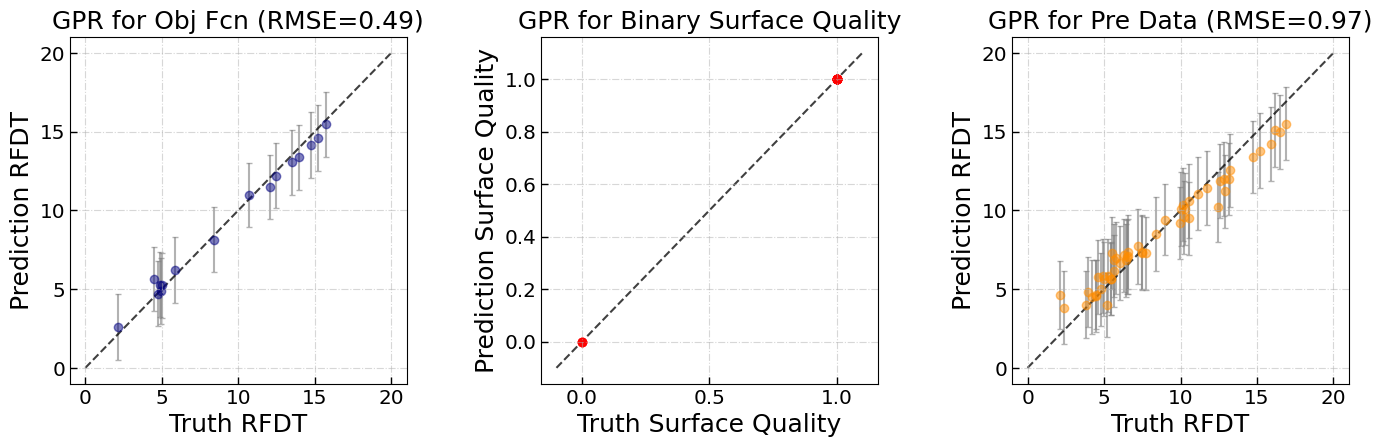

In [11]:
f_obj =  objective_model.model.predict
f_cons1 = constraint_model1.model.predict
f_cons2 = constraint_model2.model.predict

y_pred, y_uncer = f_obj(X)
y_pred = -y_pred[:,-1]
y_uncer = np.sqrt(y_uncer[:,-1])

yc_pred, yc_uncer = f_cons1(Xc)
yc_pred = -yc_pred[:,-1]+yc_offset
yc_uncer = np.sqrt(yc_uncer[:,-1])

yc2_pred, yc2_uncer = f_cons2(Xc2)
yc2_pred = -yc2_pred[:,-1]+yc2_offset
yc2_uncer = np.sqrt(yc2_uncer[:,-1])


from sklearn.metrics import mean_squared_error
fig, axes = plt.subplots(1, 3, figsize=(5.5*3, 4.5))
fs = 18
lims1 = (0, 20)
axes[0].scatter(Y[:,-1], y_pred, alpha = 0.5, c = 'navy' , edgecolor = 'navy')
axes[0].errorbar(Y[:,-1], y_pred, yerr = y_uncer, ms = 0, 
             ls = '', capsize = 2, alpha = 0.6,
             color = 'gray', zorder = 0)
axes[0].plot(lims1, lims1, 'k--', alpha=0.75, zorder=0)
rmse_value = np.sqrt(mean_squared_error(Y[:,-1], y_pred))
title = 'GPR for Obj Fcn' + " (RMSE=%.2f" % rmse_value+')'
axes[0].set_xlabel('Truth RFDT', fontsize = fs)
axes[0].set_ylabel('Prediction RFDT', fontsize = fs)
axes[0].set_title(title, fontsize = fs)

lims2 = (-.1, 1.1)
axes[1].scatter(Yc[:,-1], yc_pred, alpha = 0.6, edgecolor = 'r', c = 'r')
axes[1].errorbar(Yc[:,-1], yc_pred, yerr = yc_uncer, ms = 0, 
             ls = '', capsize = 2, alpha = 0.6,
             color = 'gray', zorder = 0)

axes[1].plot(lims2, lims2, 'k--', alpha=0.75, zorder=0)
title = 'GPR for Binary Surface Quality'
axes[1].set_xlabel('Truth Surface Quality', fontsize = fs)
axes[1].set_ylabel('Prediction Surface Quality', fontsize = fs)
axes[1].set_title(title, fontsize = fs)


lims3 = (0, 30)
axes[2].scatter(Yc2[:,-1], yc2_pred, alpha = 0.5, c = 'darkorange', edgecolor = 'darkorange')
axes[2].errorbar(Yc2[:,-1], yc2_pred, yerr = yc2_uncer, ms = 0, 
             ls = '', capsize = 2, alpha = 0.6,
             color = 'gray', zorder = 0)
axes[2].plot(lims1, lims1, 'k--', alpha=0.75, zorder=0)
rmse_value = np.sqrt(mean_squared_error(Yc2[:,-1], yc2_pred))
title = 'GPR for Pre Data' + " (RMSE=%.2f" % rmse_value+')'

axes[2].set_xlabel('Truth RFDT', fontsize = fs)
axes[2].set_ylabel('Prediction RFDT', fontsize = fs)
axes[2].set_title(title, fontsize = fs)

        
for i in range(len(axes)):
    axes[i].tick_params(direction='in', length=5, width=1, labelsize = fs*.8, grid_alpha = 0.5)
    axes[i].grid(True, linestyle='-.')
plt.subplots_adjust(wspace = 0.4)

plt.show()

In [12]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

mse = mean_squared_error
mse_all = mse(Y[:,-1], y_pred)
print ('all rmse: %.4f' % (np.sqrt(mse_all)))

rsquared_all = r2_score(Y[:,-1], y_pred)
print ('all R^2: %.4f' % (rsquared_all))

sprman_all = spearmanr(Y[:,-1], y_pred)
print ('all spearman: %.4f' % (sprman_all[0]))

all rmse: 0.4888
all R^2: 0.9884
all spearman: 0.9618


In [14]:
acquisition = NegativeLowerConfidenceBound(objective_model, beta = 1)

bayesopt_cons_pr = ProbabilisticConstraintBayesianOptimizationLoop2(model_objective=objective_model, 
                                                          space=parameter_space, 
                                                          acquisition=acquisition,
                                                          model_constraint1=constraint_model1,
                                                          model_constraint2=constraint_model2,
                                                          batch_size = 22)

X_new = bayesopt_cons_pr.candidate_point_calculator.compute_next_points(bayesopt_cons_pr.loop_state)
X_new = x_normalizer(get_closest_array(x_denormalizer(X_new)))

f_obj =  objective_model.model.predict       
f_cons1 = constraint_model1.model.predict
f_cons2 = constraint_model2.model.predict

f_cons_acq = bayesopt_cons_pr.candidate_point_calculator.acquisition.acquisition.evaluate
f_raw_acq = bayesopt_cons_pr.candidate_point_calculator.acquisition.acquisition.acquisition_1.evaluate
f_cons_pr = bayesopt_cons_pr.candidate_point_calculator.acquisition.acquisition.acquisition_2.evaluate

print('total condition no.:', len(Xc))
print('total csc no.:', len(bayesopt_cons_pr.loop_state.Y))
print('maximum Y (RFDT): ', -np.min(np.transpose(np.round(bayesopt_cons_pr.loop_state.Y, 2))))

df_Xnew = pd.DataFrame(get_closest_array(x_denormalizer(X_new)), columns = df_film.columns[1:7])
df_all = pd.concat([df_film.iloc[:,1:7], df_Xnew])
df_all_ = df_all.drop_duplicates()
df_Xnew = df_all_.iloc[20:30]
df_Xnew = df_Xnew.sort_values(by=list(df_film.columns[1:7]), ignore_index = True)
df_Xnew.index = np.arange(len(df_Xnew))+len(df_film)
df_Xnew

total condition no.: 20
total csc no.: 16
maximum Y (RFDT):  15.74


,Number,Speed [mm/s],Power [%],Frequency [KHz],Spacing [mm],Type
20,5.0,800.0,90.0,10.0,0.03,2.0
21,6.0,900.0,60.0,10.0,0.01,3.0
22,6.0,900.0,90.0,10.0,0.05,1.0
23,6.0,900.0,90.0,10.0,0.05,2.0
24,7.0,900.0,60.0,10.0,0.05,1.0
25,7.0,900.0,70.0,10.0,0.05,1.0
26,7.0,900.0,90.0,10.0,0.05,1.0
27,8.0,700.0,50.0,20.0,0.05,1.0
28,8.0,900.0,70.0,10.0,0.05,1.0
29,8.0,900.0,90.0,10.0,0.07,1.0


In [15]:
X_new = x_normalizer(df_Xnew.values)

y_pred_new, y_uncer_new = f_obj(X_new)
y_pred_new = -y_pred_new
y_uncer_new = np.sqrt(y_uncer_new)

acq_produc = f_cons_acq(X_new)
acq_fcn = f_raw_acq(X_new)
acq_cons = f_cons_pr(X_new)

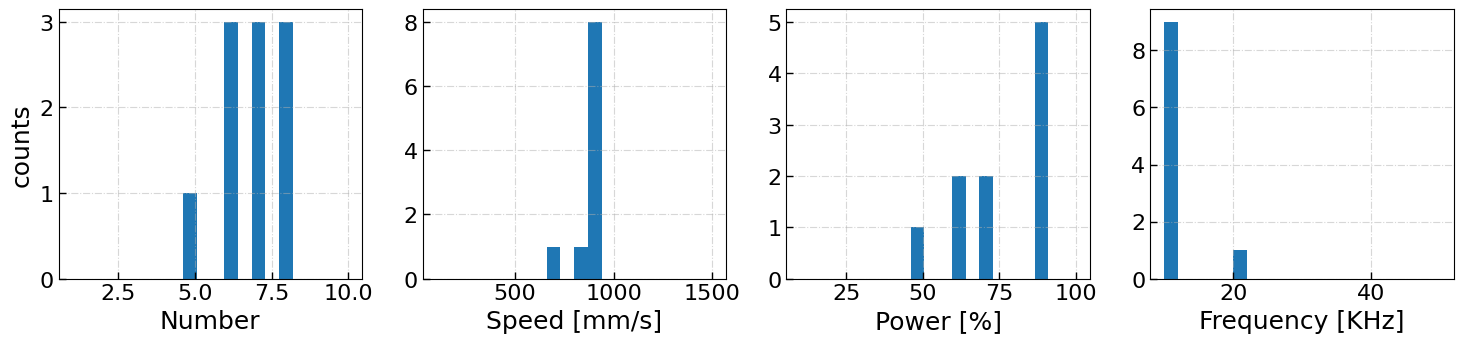

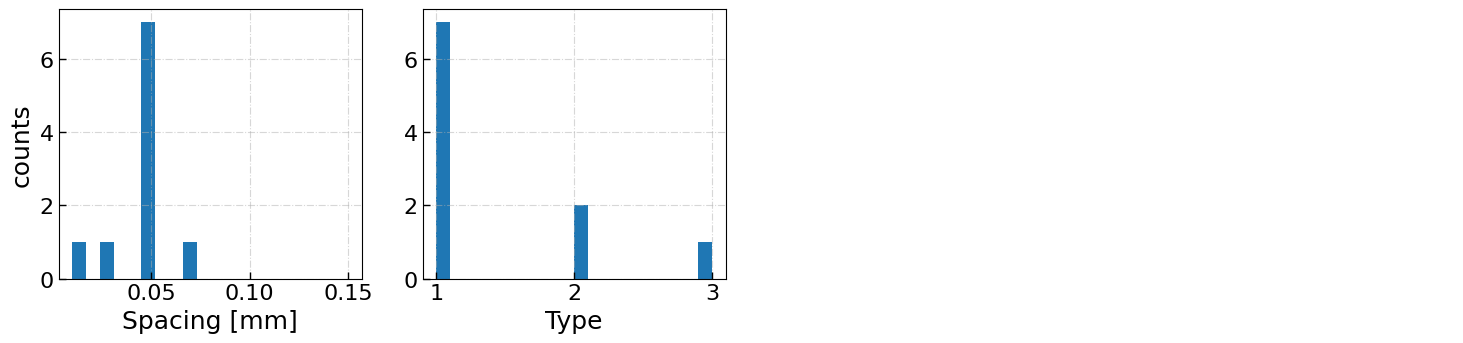

In [16]:
df = df_Xnew
df_cols = df.columns
n_col = 4

for n in np.arange(0, 8, n_col):
    fig,axes = plt.subplots(1, n_col, figsize=(18, 3.5), sharey = False)
    fs = 20
    for i in np.arange(n_col):
        if n< len(df_cols):
            axes[i].hist(df.iloc[:,n], bins= 20, range = (min(var_array[n]),max(var_array[n])))
            axes[i].set_xlabel(df_cols[n], fontsize = 18)
        
        else:
            axes[i].axis("off")
        n = n+1      
    axes[0].set_ylabel('counts', fontsize = 18)
    for i in range(len(axes)):
        axes[i].tick_params(direction='in', length=5, width=1, labelsize = fs*.8, grid_alpha = 0.5)
        axes[i].grid(True, linestyle='-.')
    plt.show()

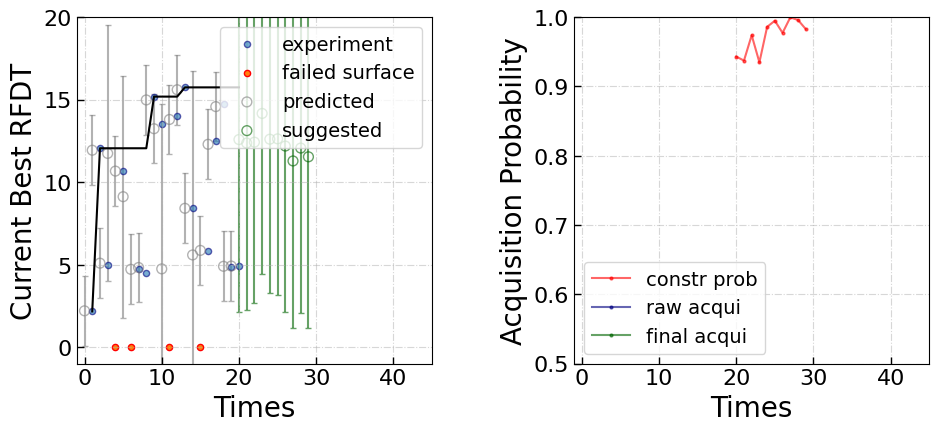

In [17]:
f_obj =  objective_model.model.predict       

csc_eff = df_csc.sort_values('ML Condition').iloc[:,[0,-1]].values
film_quality = df_film.sort_values('ML Condition').iloc[:,[0,-2]].values

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey = False)
fs = 20
exp_cond = np.transpose(csc_eff)[0]
exp_eff = np.transpose(csc_eff)[1]

axes[0].scatter(exp_cond, exp_eff,
            edgecolor = 'navy', s = 20, alpha = 0.6, label = 'experiment')

unsuccess_film = np.transpose(film_quality[film_quality[:,-1] ==0])
axes[0].scatter(unsuccess_film[0], unsuccess_film[1],
                edgecolor = 'red',
                s = 20, label = 'failed surface')
all_cond = np.concatenate([csc_eff, np.transpose(unsuccess_film)])
all_cond = all_cond[np.argsort(all_cond[:,0])]
axes[0].plot(np.transpose(all_cond)[0], np.maximum.accumulate(np.transpose(all_cond)[1]), 
         marker = 'o', ms = 0, c = 'black')

X_sorted = x_normalizer(df_film.sort_values('ML Condition').iloc[:,1:7].values)
y_pred, y_uncer = f_obj(X_sorted)
y_pred = -y_pred[:,-1]
y_uncer = np.sqrt(y_uncer[:,-1])

axes[0].scatter(np.arange(len(X_sorted)), y_pred,
                s = 50, facecolors='none', alpha = 0.6, edgecolor = 'gray', label = 'predicted')
axes[0].errorbar(np.arange(len(X_sorted)), y_pred, yerr = y_uncer,  
                 ms = 0, ls = '', capsize = 2, alpha = 0.6, 
                 color = 'gray', zorder = 0)


y_pred_new, y_uncer_new = f_obj(X_new)
y_pred_new = -y_pred_new[:,-1]
y_uncer_new = np.sqrt(y_uncer_new[:,-1])

axes[0].scatter(np.arange(len(X_new))+len(Xc), y_pred_new,
                s = 50, facecolors='none', alpha = 0.6, edgecolor = 'darkgreen', label = 'suggested')
axes[0].errorbar(np.arange(len(X_new))+len(Xc), y_pred_new, yerr = y_uncer_new,  
                 ms = 0, ls = '', capsize = 2, alpha = 0.6, 
                 color = 'darkgreen', zorder = 0)


axes[0].set_ylabel('Current Best RFDT', fontsize = 20)
axes[0].set_xlabel('Times', fontsize = 20)

axes[0].set_ylim(-1, 20)
axes[0].set_xlim(-1, 45)
axes[0].set_xticks(np.arange(0,41,10))
axes[0].legend(fontsize = fs*0.7)

axes[1].plot(np.arange(len(X_new))+len(Xc), acq_cons, marker = 'o',
                ms = 2, alpha = 0.6, color = 'red', label = 'constr prob')
axes[1].plot(np.arange(len(X_new))+len(Xc), acq_fcn/20, marker = 'o',
                ms = 2, alpha = 0.6, color = 'navy', label = 'raw acqui')

axes[1].plot(np.arange(len(X_new))+len(Xc), acq_produc/20, marker = 'o',
                ms = 2, alpha = 0.6, color = 'darkgreen', label = 'final acqui')


axes[1].set_ylim(0.5, 1)
axes[1].set_xlim(-1, 45)
axes[1].set_xticks(np.arange(0,45,10))
axes[1].set_ylabel('Acquisition Probability', fontsize = fs)
axes[1].set_xlabel('Times', fontsize = fs)

for ax in axes:
    ax.tick_params(direction='in', length=5, width=1, labelsize = fs*.8, grid_alpha = 0.5)
    ax.grid(True, linestyle='-.')
plt.subplots_adjust(wspace = 0.4)
plt.legend(fontsize = fs*0.7)
plt.show()

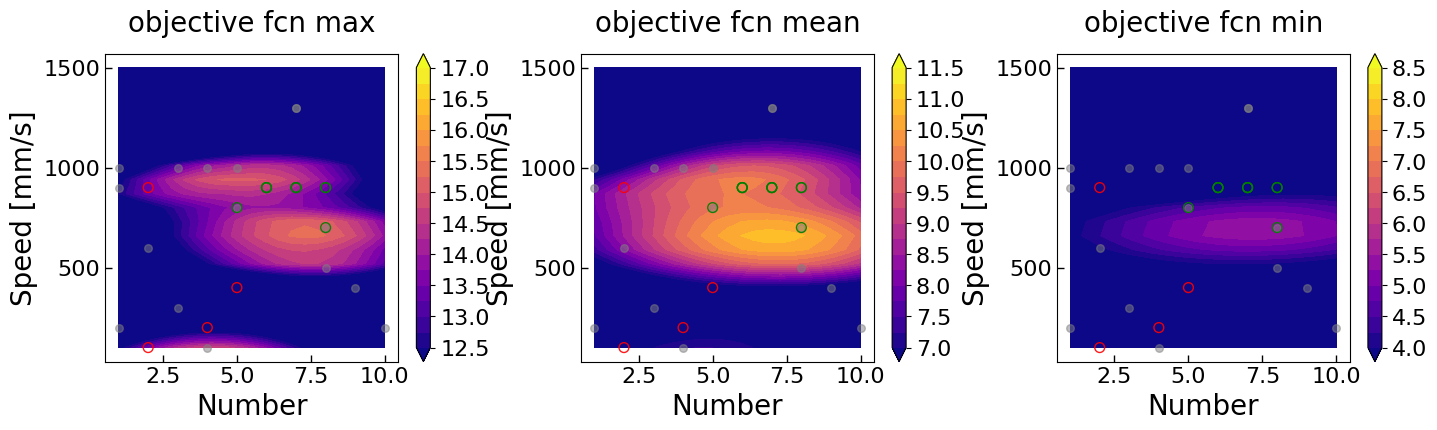

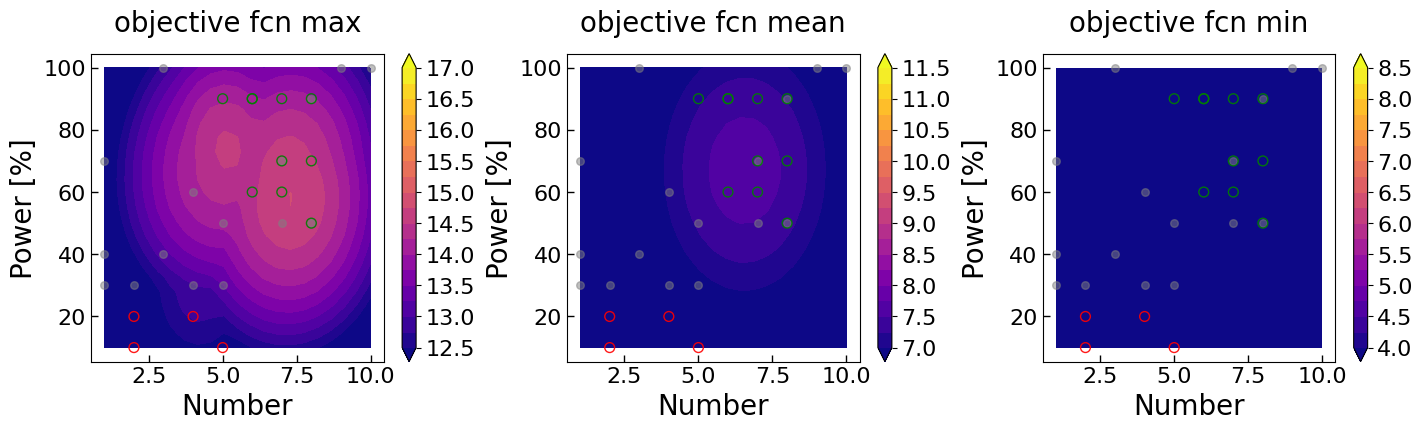

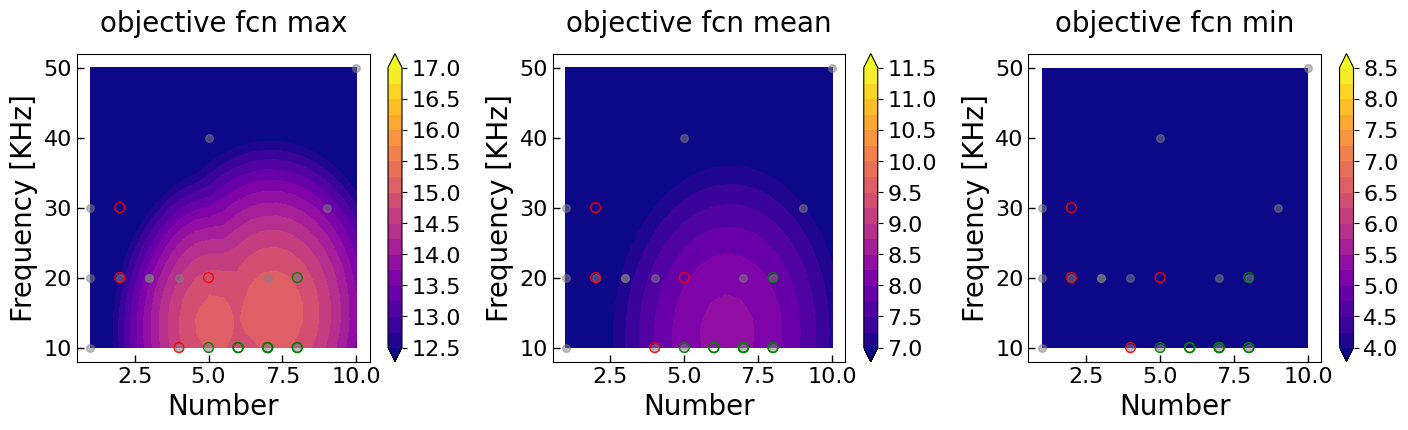

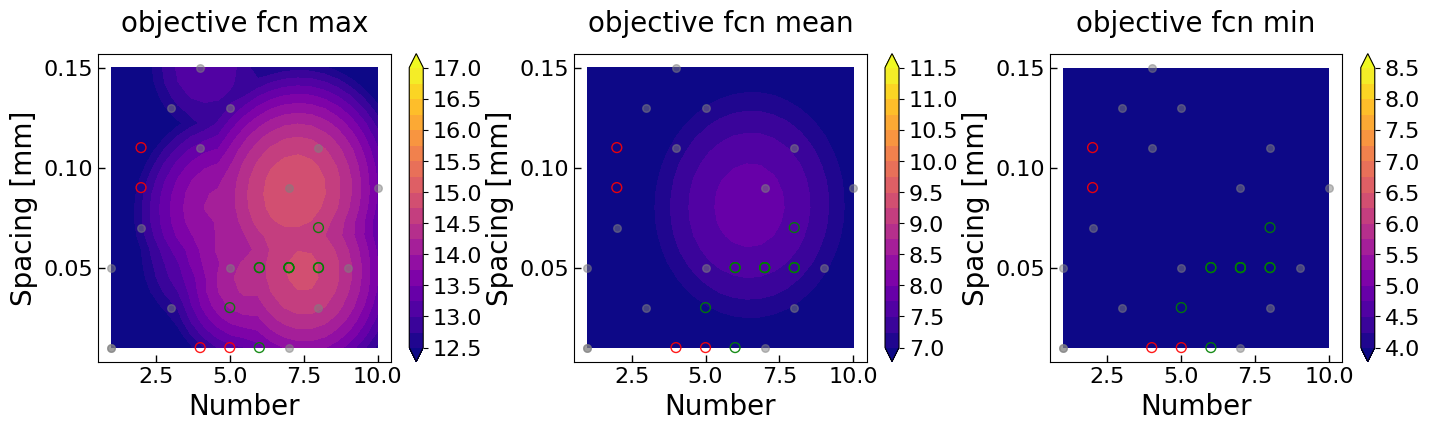

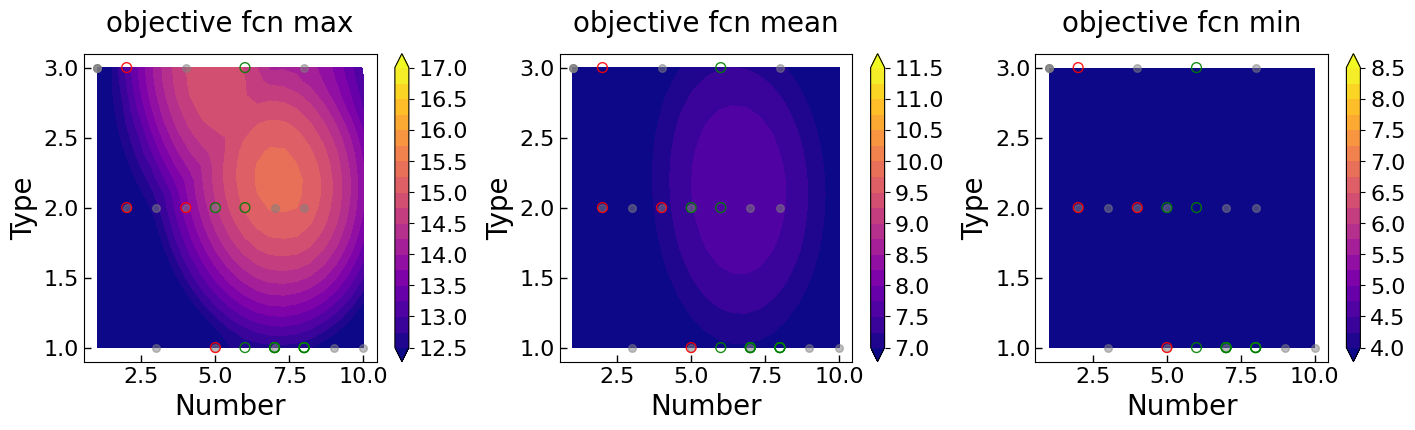

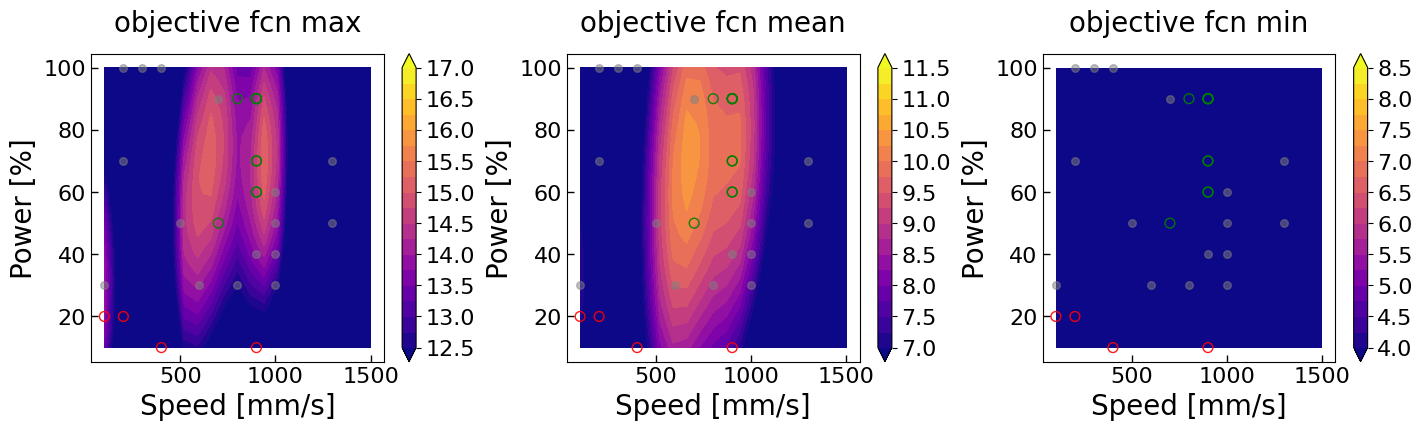

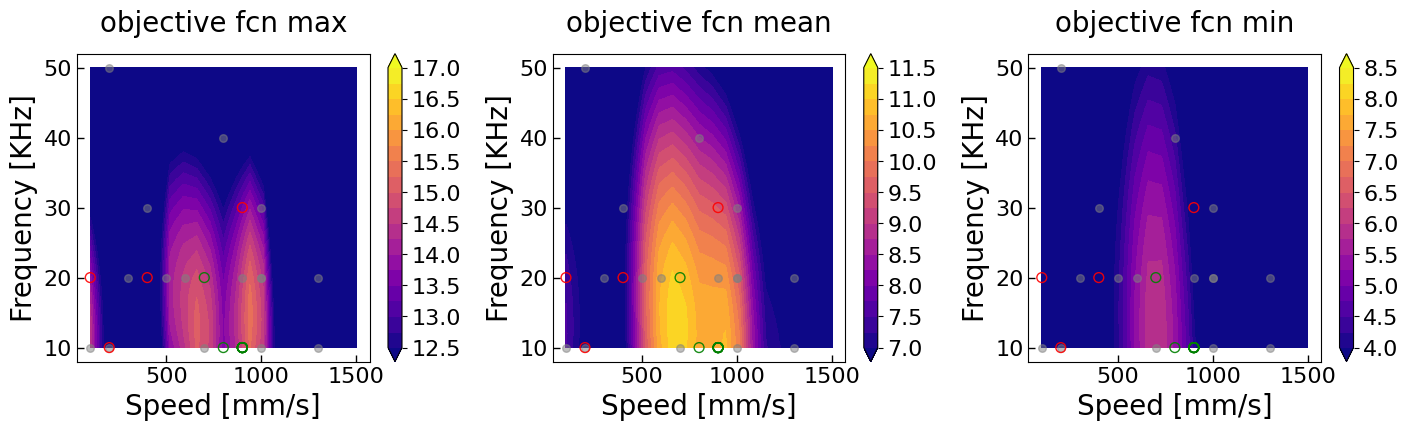

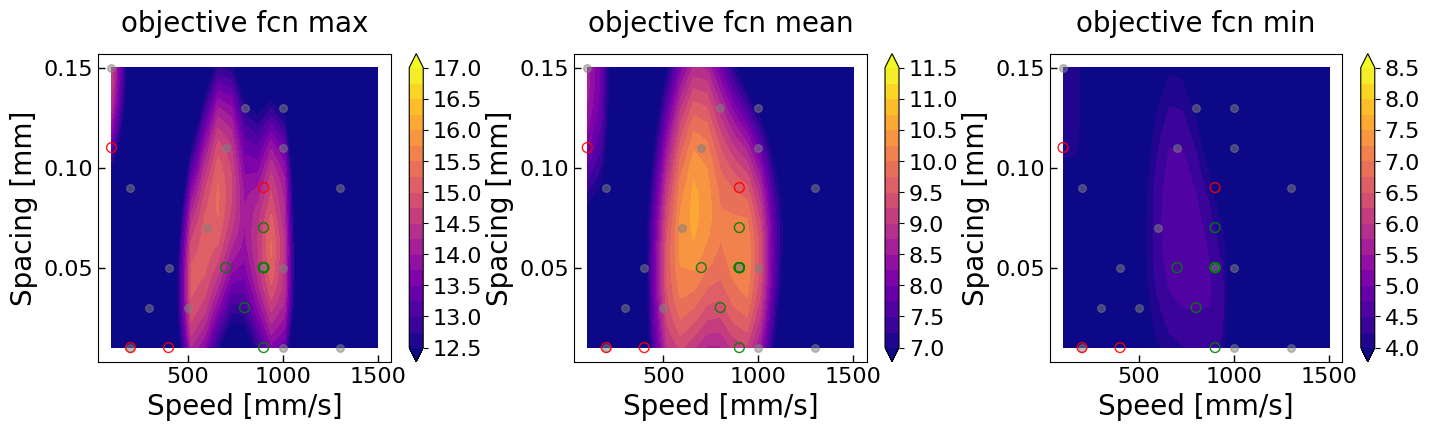

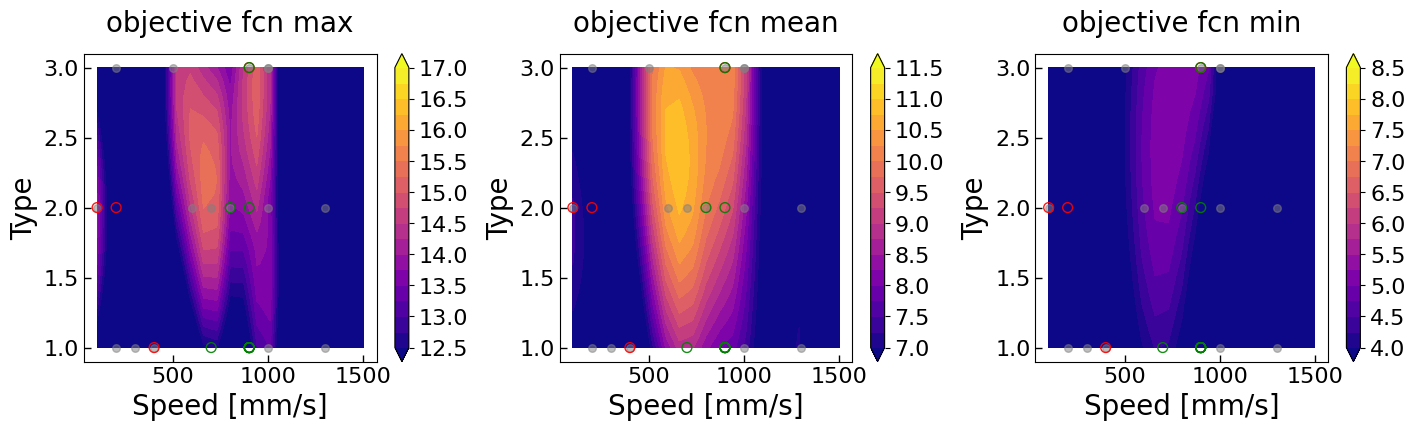

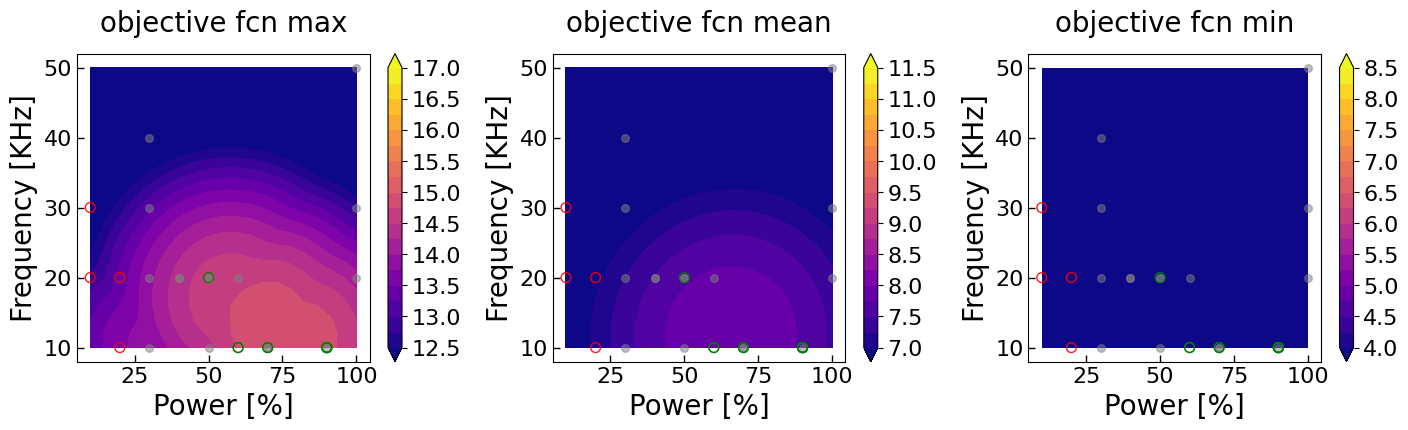

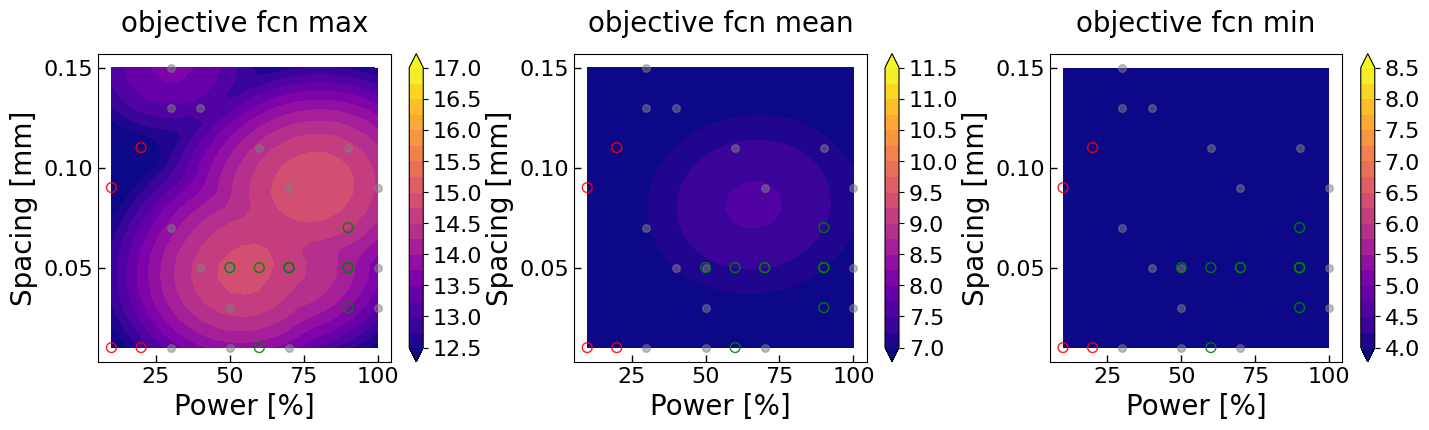

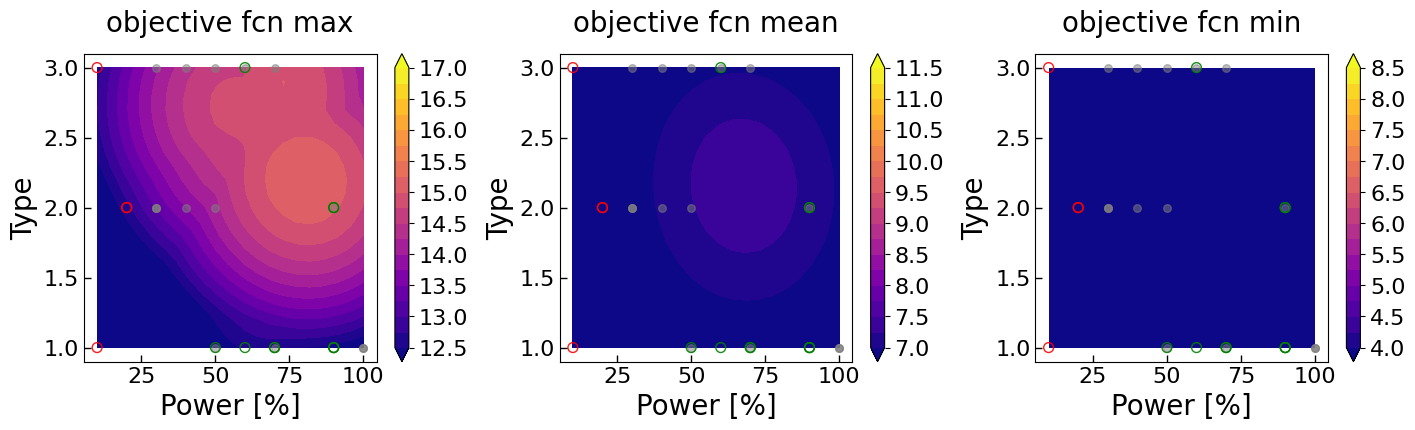

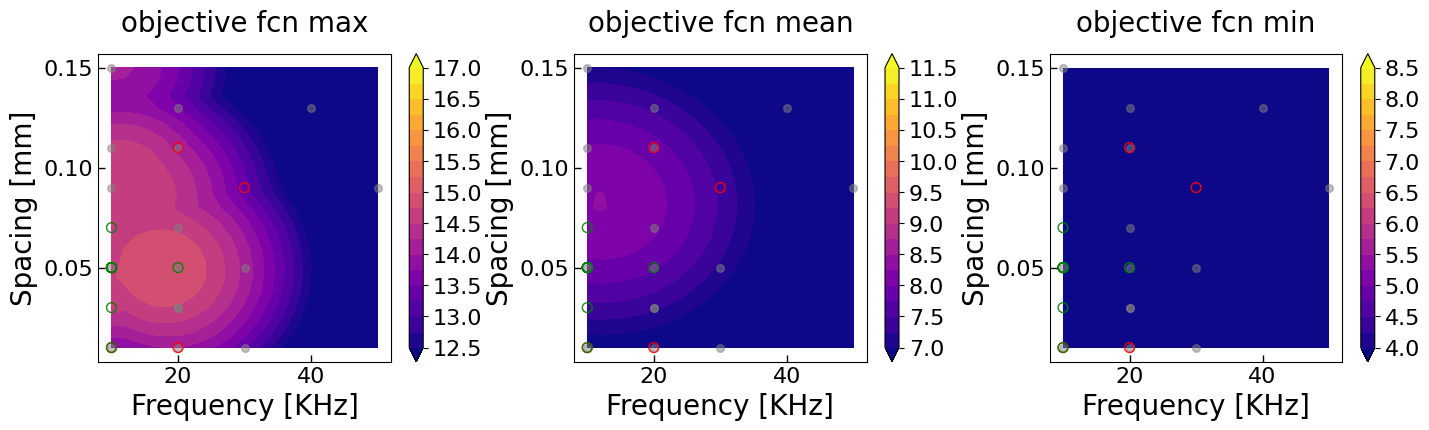

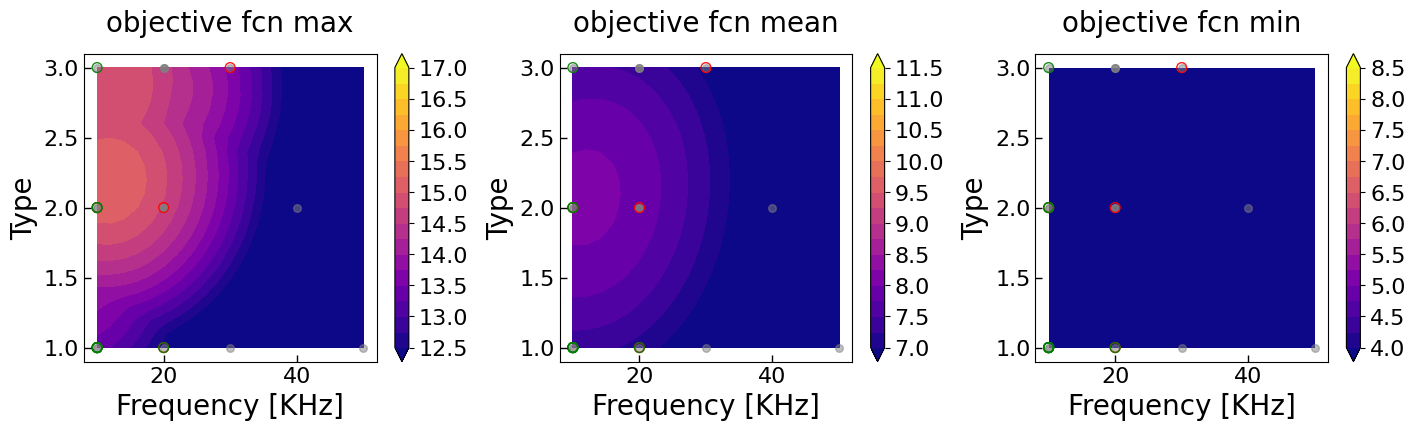

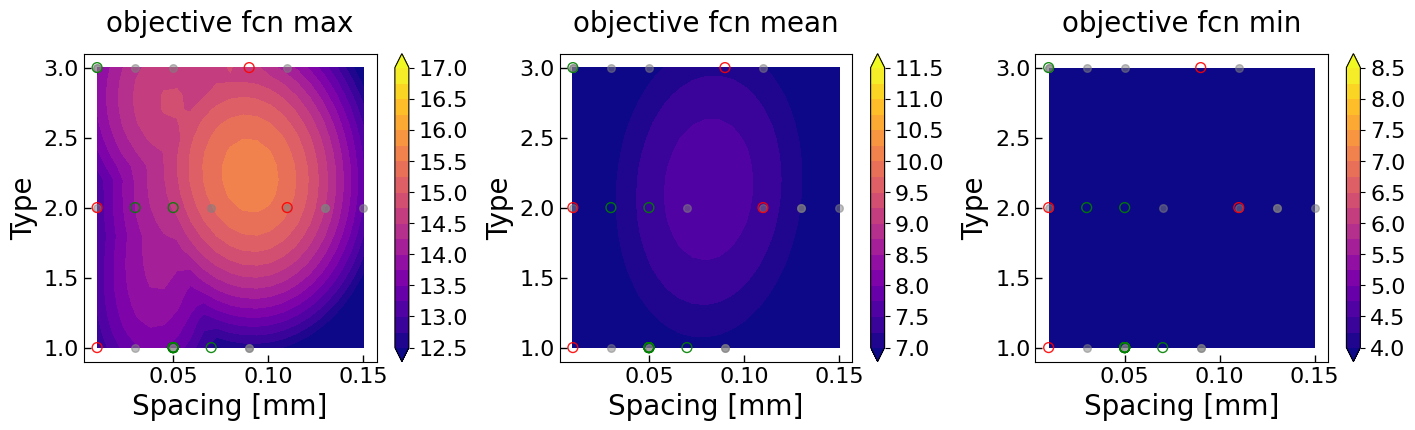

In [22]:
design = RandomDesign(parameter_space)
x_sampled = design.get_samples(200)
x_columns = df_csc.iloc[:,1:7].columns
for i in range(input_dim):
    for j in range(input_dim-i-1):
        

        ind1 = i
        ind2 = j+i+1
        n_steps =21
        x1x2y_pred, x1x2y_uncer =[[],[]]
        for x1 in np.linspace(0, 1, n_steps):
            for x2 in np.linspace(0, 1, n_steps):
                x_temp = np.copy(x_sampled)
                x_temp[:,ind1] = x1
                x_temp[:,ind2] = x2
                y_pred, y_uncer = f_obj(x_temp)
                y_pred = -y_pred
                x1_org = x_denormalizer(x_temp)[0,ind1]
                x2_org = x_denormalizer(x_temp)[0,ind2]
                x1x2y_pred.append([x1_org, x2_org, np.max(y_pred), np.mean(y_pred), np.min(y_pred)])
                x1x2y_uncer.append([x1_org, x2_org, np.max(np.sqrt(y_uncer)), np.mean(np.sqrt(y_uncer)), np.min(np.sqrt(y_uncer))])
        
        x1 = np.array(x1x2y_pred, dtype=object)[:,0].reshape(n_steps, n_steps)
        x2 = np.array(x1x2y_pred, dtype=object)[:,1].reshape(n_steps, n_steps)
            
        y_pred_max = np.array(x1x2y_pred, dtype=object)[:,2].reshape(n_steps, n_steps)
        y_pred_mean = np.array(x1x2y_pred, dtype=object)[:,3].reshape(n_steps, n_steps)
        y_pred_min = np.array(x1x2y_pred, dtype=object)[:,4].reshape(n_steps, n_steps)
        
        y_uncer_max = np.array(x1x2y_uncer, dtype=object)[:,2].reshape(n_steps, n_steps)
        y_uncer_mean = np.array(x1x2y_uncer, dtype=object)[:,3].reshape(n_steps, n_steps)
        y_uncer_min = np.array(x1x2y_uncer, dtype=object)[:,4].reshape(n_steps, n_steps)

        fs = 20
        title_pad = 16
        

        fig,axes = plt.subplots(1, 3, figsize=(17, 4), sharey = False, sharex = False)
        colorbar_offset = [12.5, 7, 4]
        for ax, c_offset, y in zip(axes, colorbar_offset,
                                   [y_pred_max, y_pred_mean, y_pred_min]):
            
            c_plt1 = ax.contourf(x1, x2, y, levels = np.arange(19)*0.25+c_offset, cmap='plasma', extend = 'both')
            cbar = fig.colorbar(c_plt1, ax= ax)
            cbar.ax.tick_params(labelsize=fs*0.8)
            ax.scatter(x_denormalizer(X)[:, ind1], 
                       x_denormalizer(X)[:, ind2], 
                       s = 30, facecolors='gray', alpha = 0.5, edgecolor = 'gray')
            ax.scatter(x_denormalizer(Xc[Yc[:,-1]==0])[:, ind1],
                       x_denormalizer(Xc[Yc[:,-1]==0])[:, ind2], 
                       s = 50, facecolors='none', alpha = 0.9, edgecolor = 'red')

            ax.scatter(x_denormalizer(X_new)[:, ind1], 
                       x_denormalizer(X_new)[:, ind2], 
                       s = 50, facecolors='none', alpha = 0.9, edgecolor = 'green')
            ax.set_xlabel(str(x_columns[ind1]),fontsize =  fs)
            ax.set_ylabel(str(x_columns[ind2]),fontsize =  fs)

            x1_delta = (np.max(x1)-np.min(x1))*0.05
            x2_delta = (np.max(x2)-np.min(x2))*0.05
            ax.set_xlim(np.min(x1)-x1_delta, np.max(x1)+x1_delta)
            ax.set_ylim(np.min(x2)-x2_delta, np.max(x2)+x2_delta)
            ax.tick_params(direction='in', length=5, width=1, labelsize = fs*.8)


        axes[0].set_title('objective fcn max', pad = title_pad,fontsize =  fs)
        axes[1].set_title('objective fcn mean', pad = title_pad,fontsize =  fs)
        axes[2].set_title('objective fcn min', pad = title_pad,fontsize =  fs)

        plt.subplots_adjust(wspace = 0.3)
        plt.show()

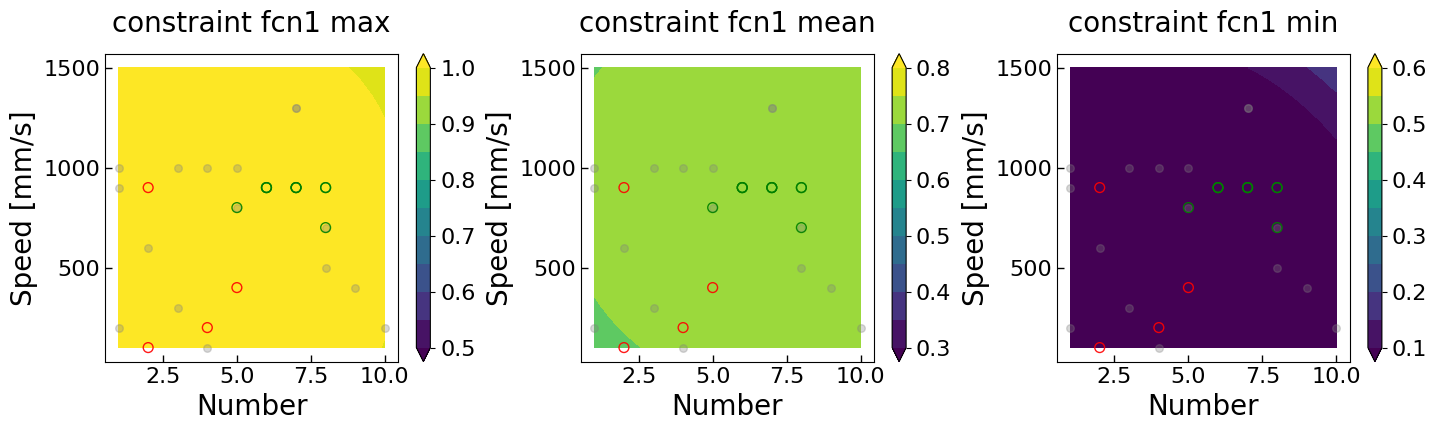

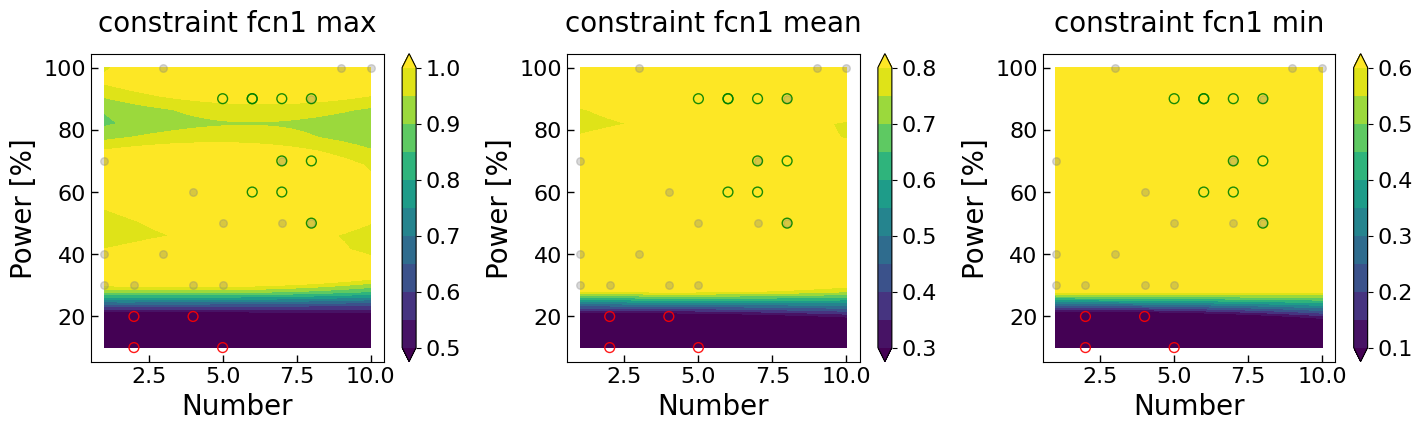

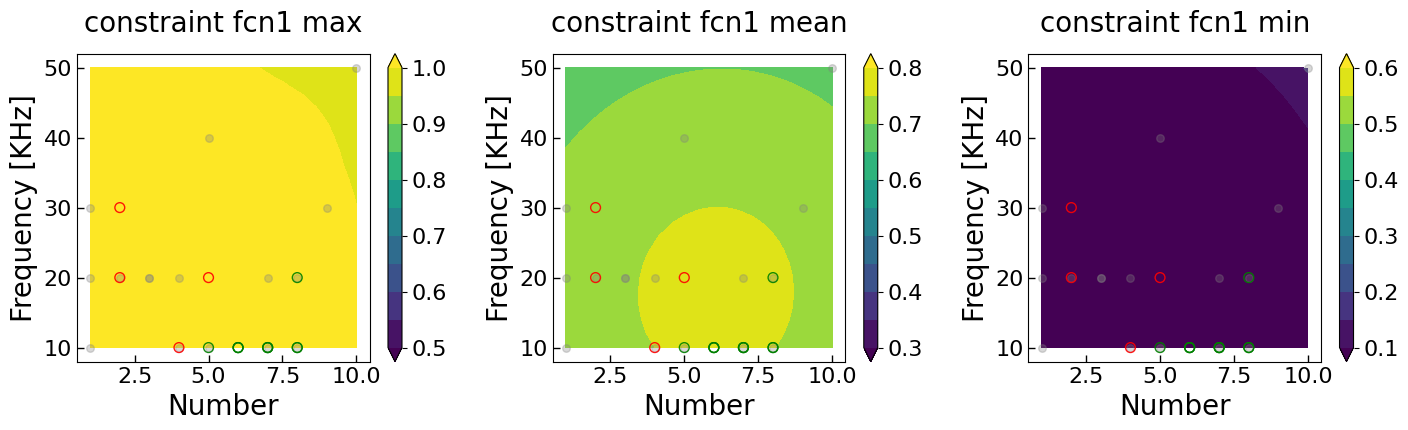

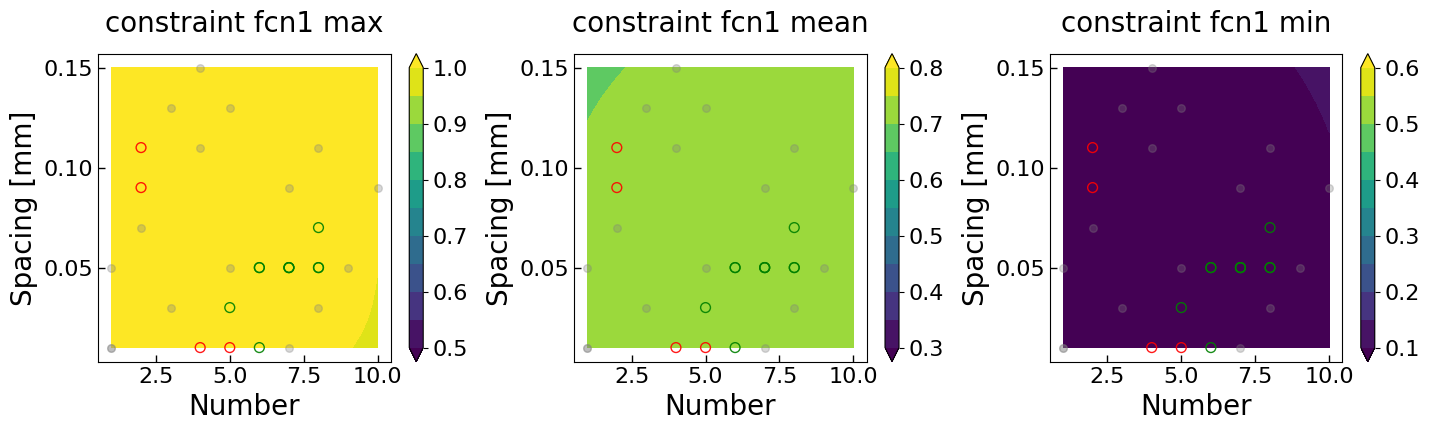

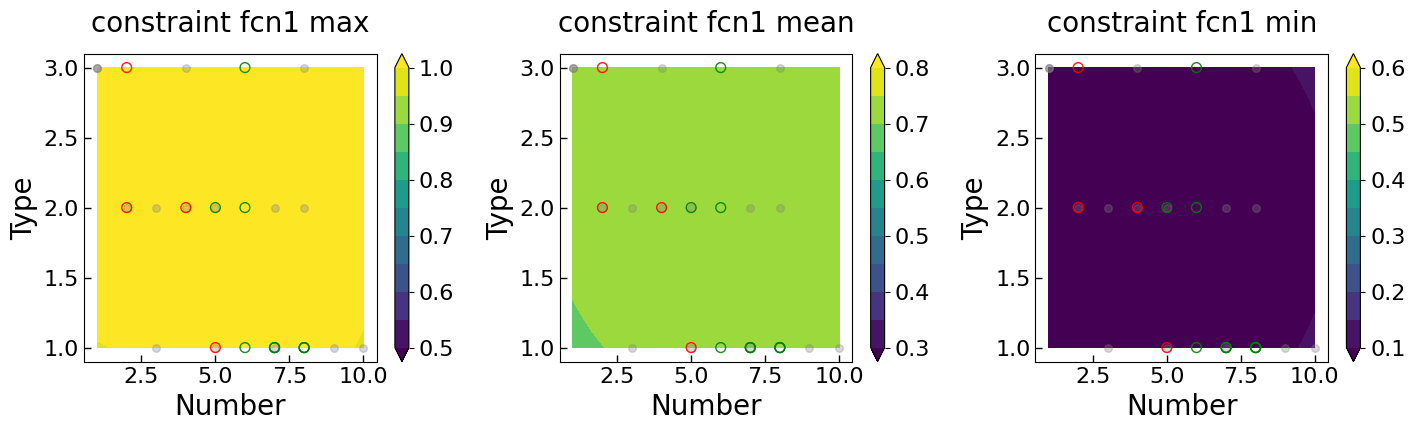

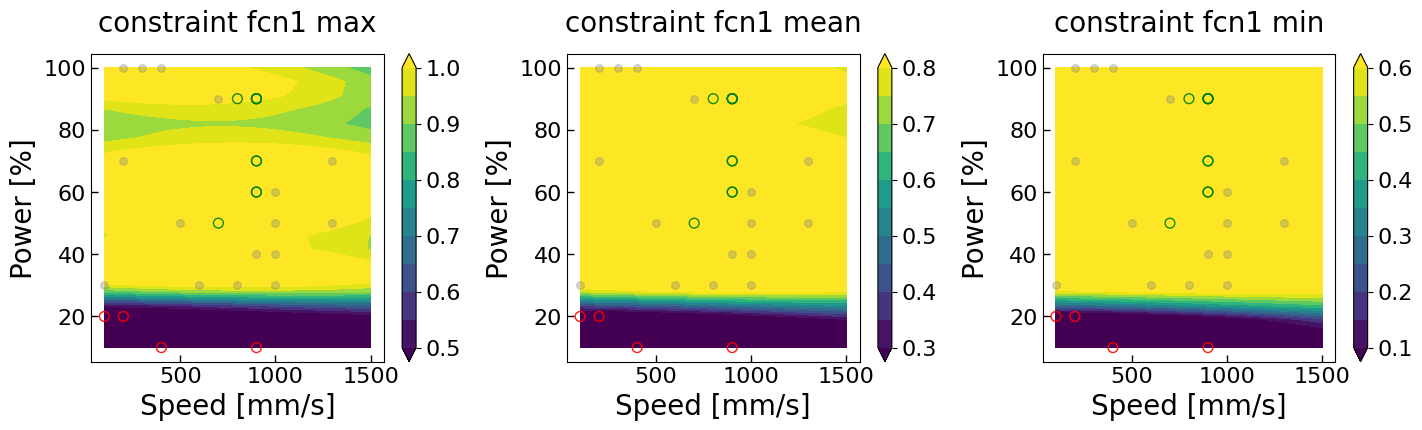

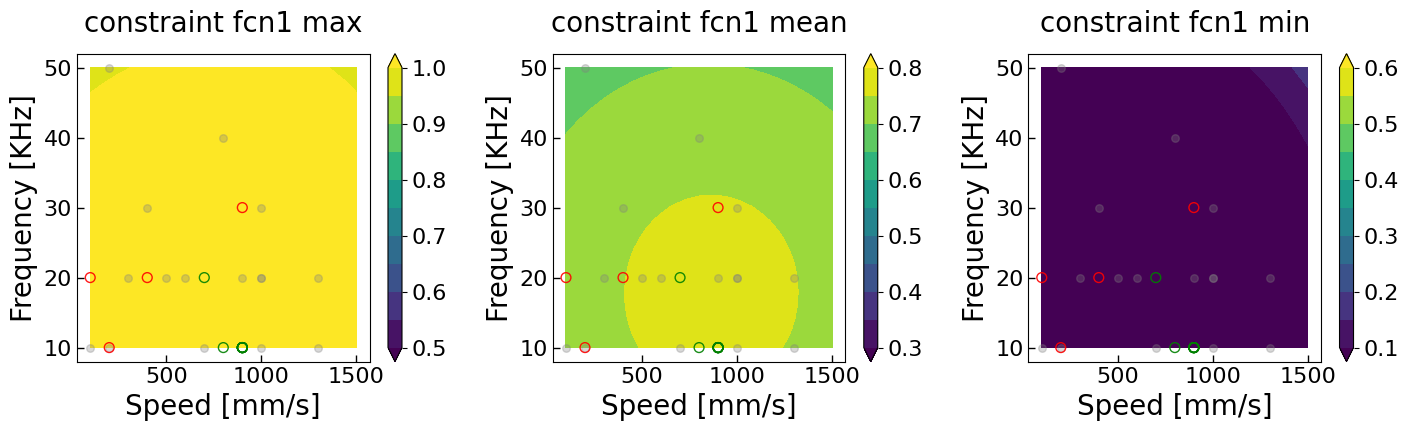

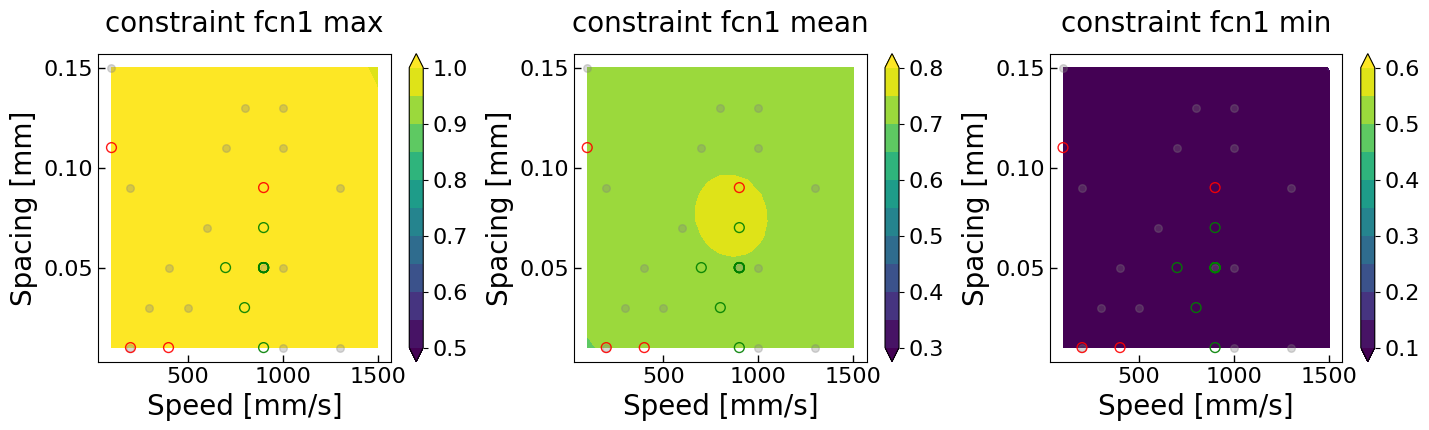

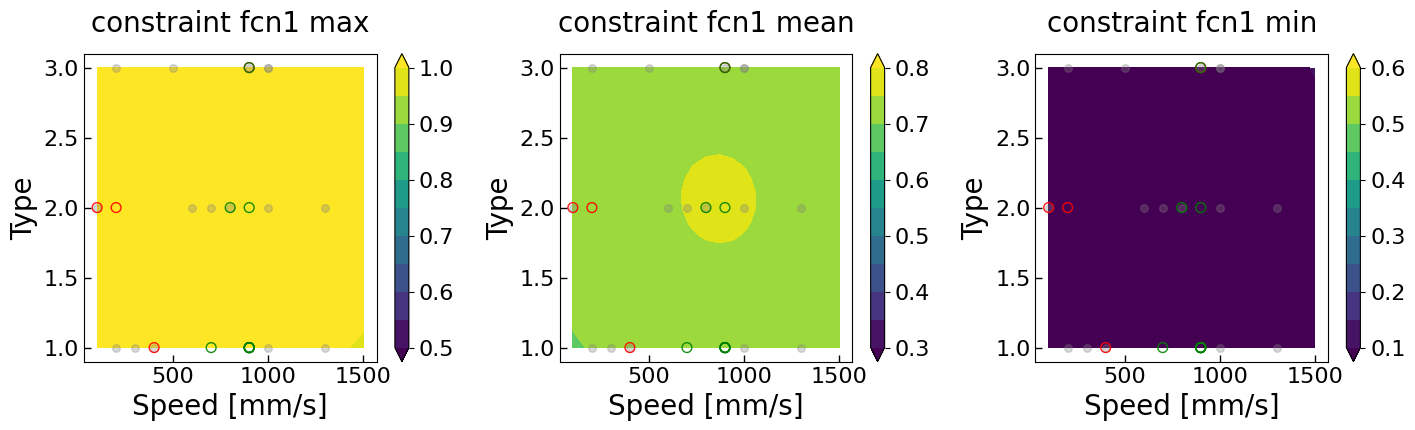

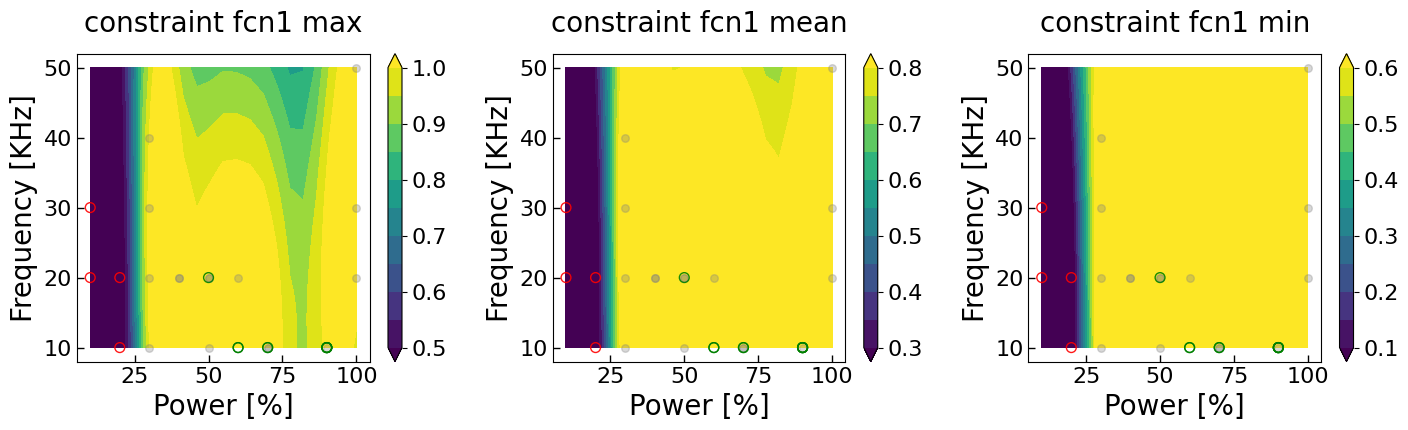

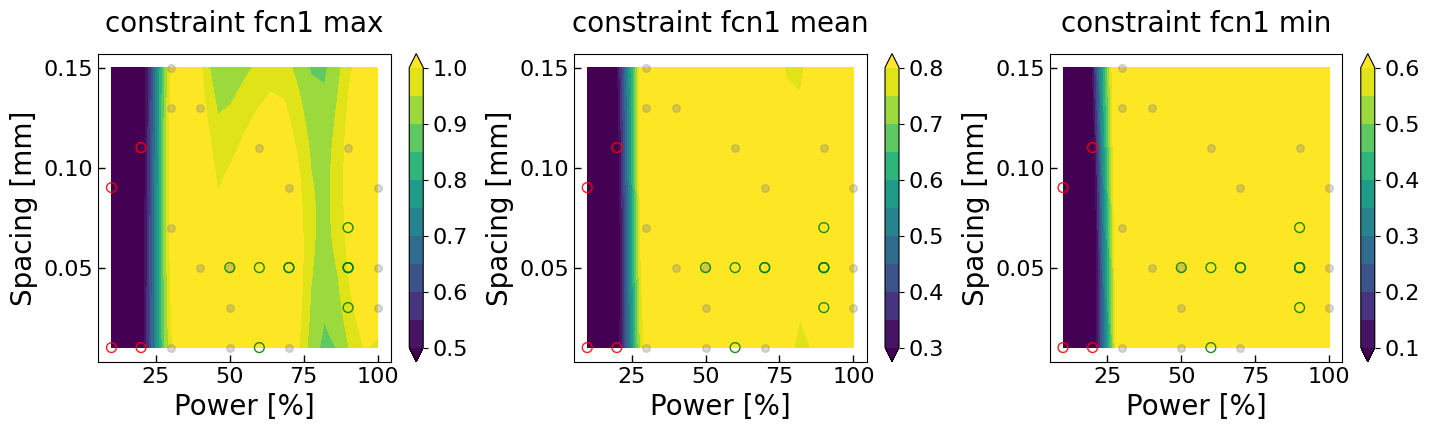

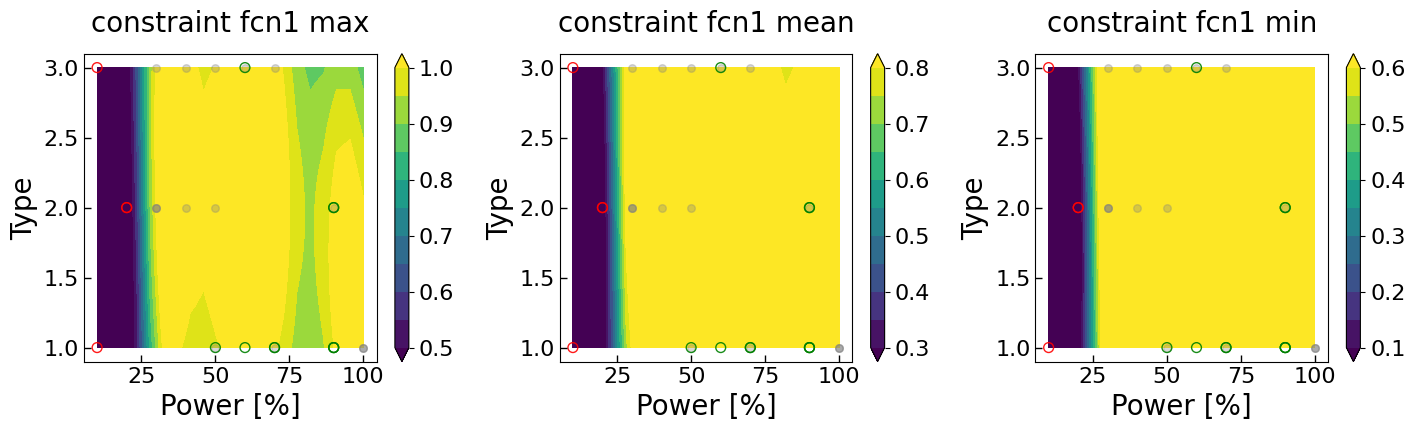

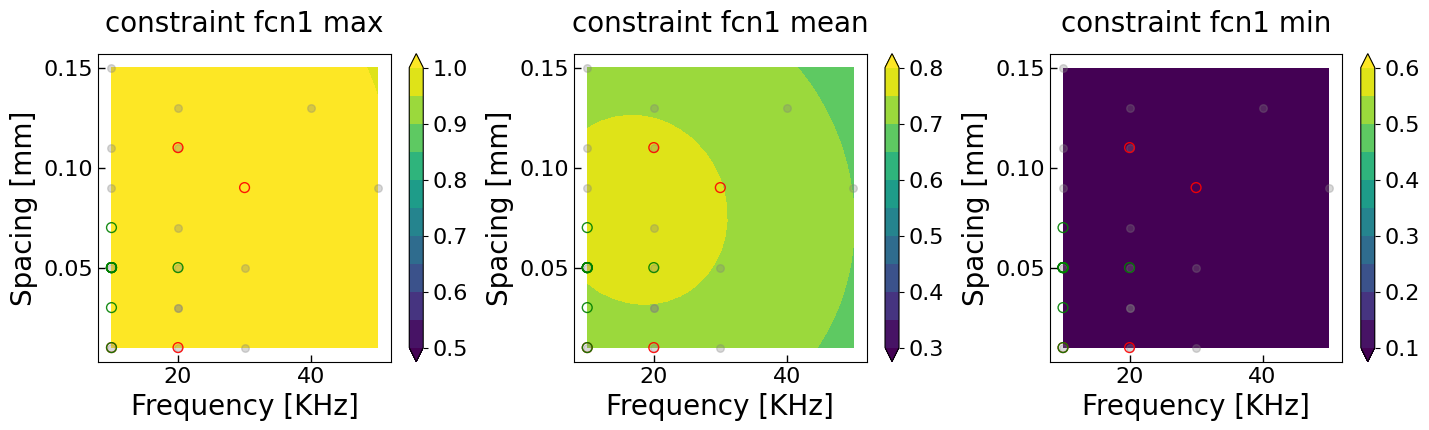

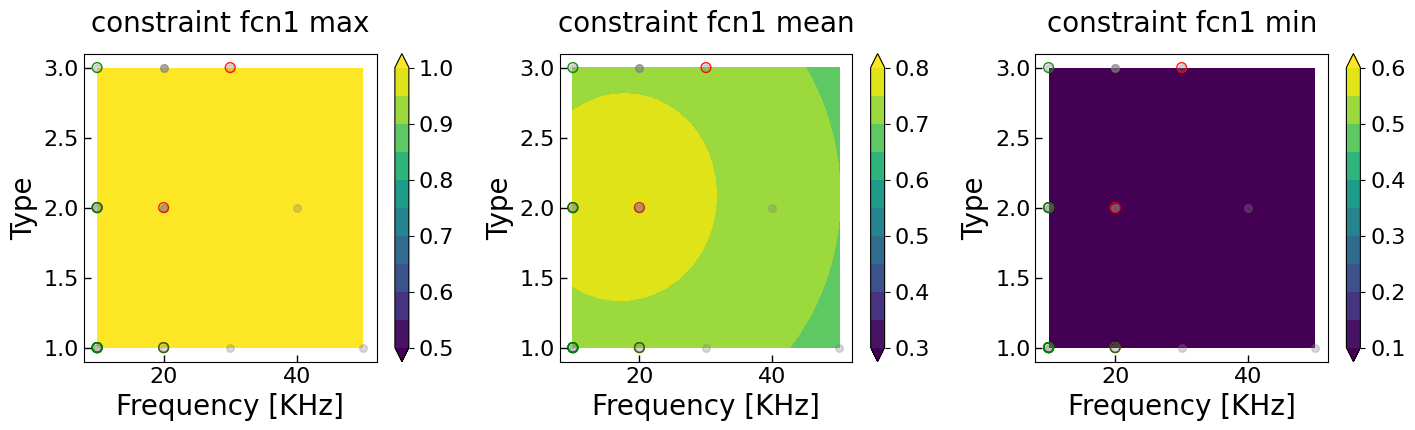

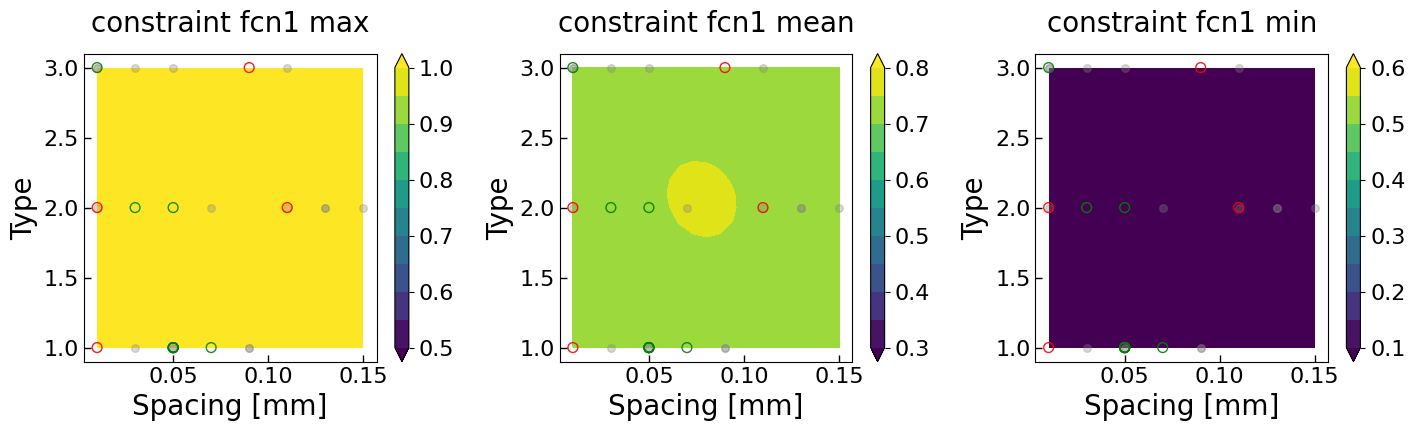

In [23]:
np.random.seed(10)
design = RandomDesign(parameter_space)
x_sampled = design.get_samples(200)
x_columns = df_film.iloc[:,1:7].columns
for i in range(input_dim):
    for j in range(input_dim-i-1):
        ind1 = i
        ind2 = j+i+1
        n_steps =21
        x1x2y_pred, x1x2y_var =[[],[]]
        for x1 in np.linspace(0, 1, n_steps):
            for x2 in np.linspace(0, 1, n_steps):
                x_temp = np.copy(x_sampled)
                x_temp[:,ind1] = x1
                x_temp[:,ind2] = x2
                yc_pr, yc_var = f_cons1(x_temp)
                yc_pr = -yc_pr+yc_offset
                x1_org = x_denormalizer(x_temp)[0,ind1]
                x2_org = x_denormalizer(x_temp)[0,ind2]
                x1x2y_pred.append([x1_org, x2_org, np.max(yc_pr), np.mean(yc_pr), np.min(yc_pr)])
                
        x1c = np.array(x1x2y_pred, dtype=object)[:,0].reshape(n_steps, n_steps)
        x2c = np.array(x1x2y_pred, dtype=object)[:,1].reshape(n_steps, n_steps)
        yc_pr_max = np.array(x1x2y_pred, dtype=object)[:,2].reshape(n_steps, n_steps)
        yc_pr_mean = np.array(x1x2y_pred, dtype=object)[:,3].reshape(n_steps, n_steps)
        yc_pr_min = np.array(x1x2y_pred, dtype=object)[:,4].reshape(n_steps, n_steps)
        
        fs = 20
        title_pad = 16
        
        fig,axes = plt.subplots(1, 3, figsize=(17, 4), sharey = False, sharex = False)
        colorbar_offset = [0.5, 0.3, 0.1]
        for ax, y, c_offset in zip(axes, [yc_pr_max, yc_pr_mean, yc_pr_min],colorbar_offset):
            c_plt1 = ax.contourf(x1c, x2c, y, levels = np.arange(11)*0.05+c_offset, cmap='viridis', extend = 'both')## viridis 
            cbar = fig.colorbar(c_plt1, ax= ax)
            cbar.ax.tick_params(labelsize=fs*0.8)
            ax.scatter(x_denormalizer(X)[:, ind1], 
                       x_denormalizer(X)[:, ind2], 
                       s = 30, facecolors='gray', alpha = 0.3, edgecolor = 'gray')
            ax.scatter(x_denormalizer(Xc[Yc[:,-1]==0])[:, ind1], 
                       x_denormalizer(Xc[Yc[:,-1]==0])[:, ind2], 
                       s = 50, facecolors='none', alpha = 0.9, edgecolor = 'red')     
            ax.scatter(x_denormalizer(X_new)[:, ind1], 
                       x_denormalizer(X_new)[:, ind2], 
                       s = 50, facecolors='none', alpha = 0.9, edgecolor = 'green')
            
            ax.set_xlabel(str(x_columns[ind1]), fontsize = fs)
            ax.set_ylabel(str(x_columns[ind2]), fontsize = fs)

            x1_delta = (np.max(x1c)-np.min(x1c))*0.05
            x2_delta = (np.max(x2c)-np.min(x2c))*0.05
            ax.set_xlim(np.min(x1c)-x1_delta, np.max(x1c)+x1_delta)
            ax.set_ylim(np.min(x2c)-x2_delta, np.max(x2c)+x2_delta)
            ax.tick_params(direction='in', length=5, width=1, labelsize = fs*.8, grid_alpha = 0.5)
            
                                
        axes[0].set_title('constraint fcn1 max', pad = title_pad, fontsize = fs)
        axes[1].set_title('constraint fcn1 mean', pad = title_pad, fontsize = fs)
        axes[2].set_title('constraint fcn1 min', pad = title_pad, fontsize = fs)
        plt.subplots_adjust(wspace = 0.3)
        plt.show()

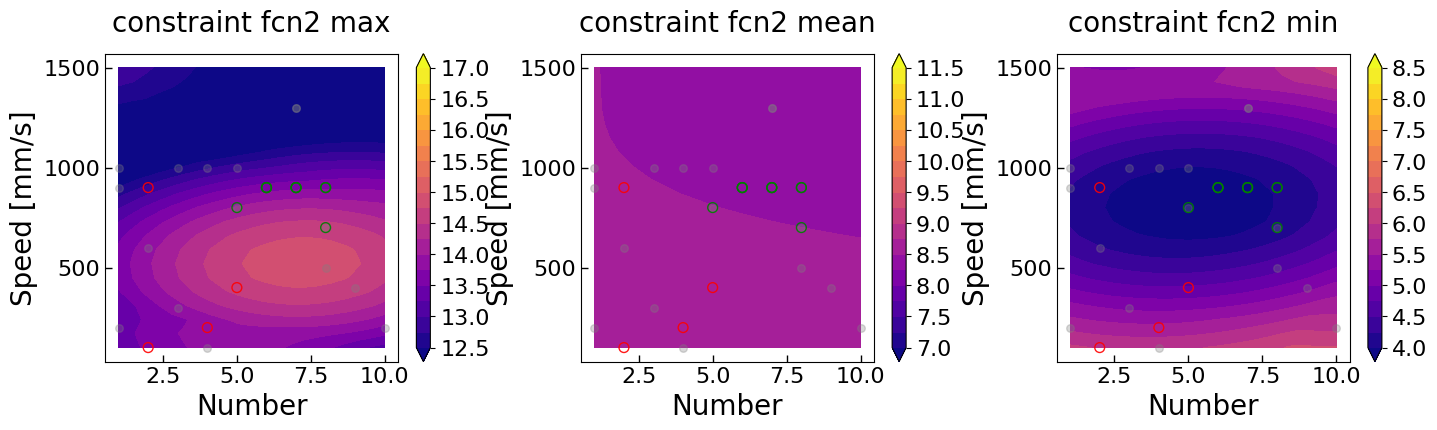

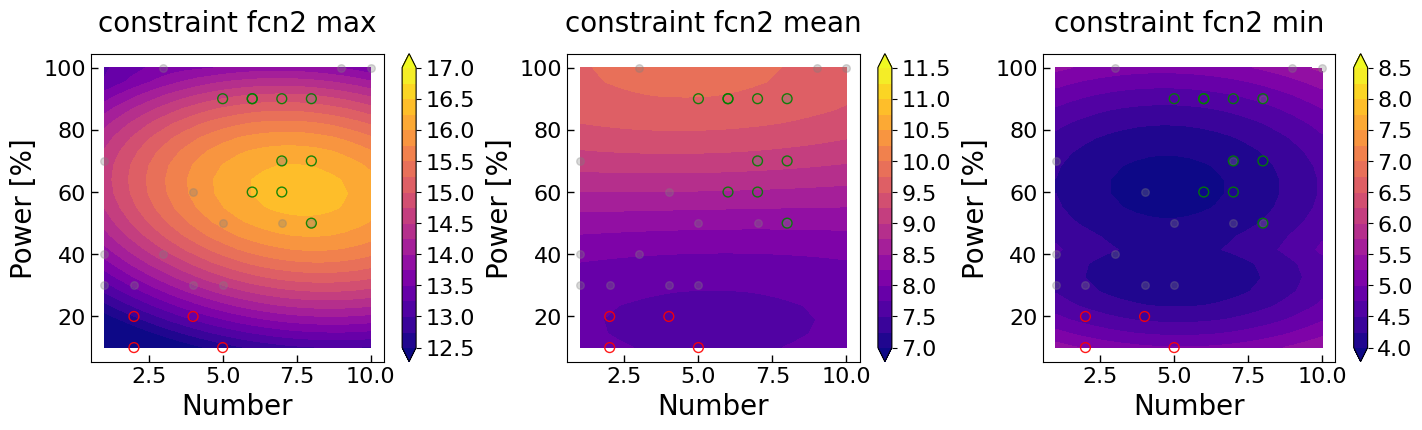

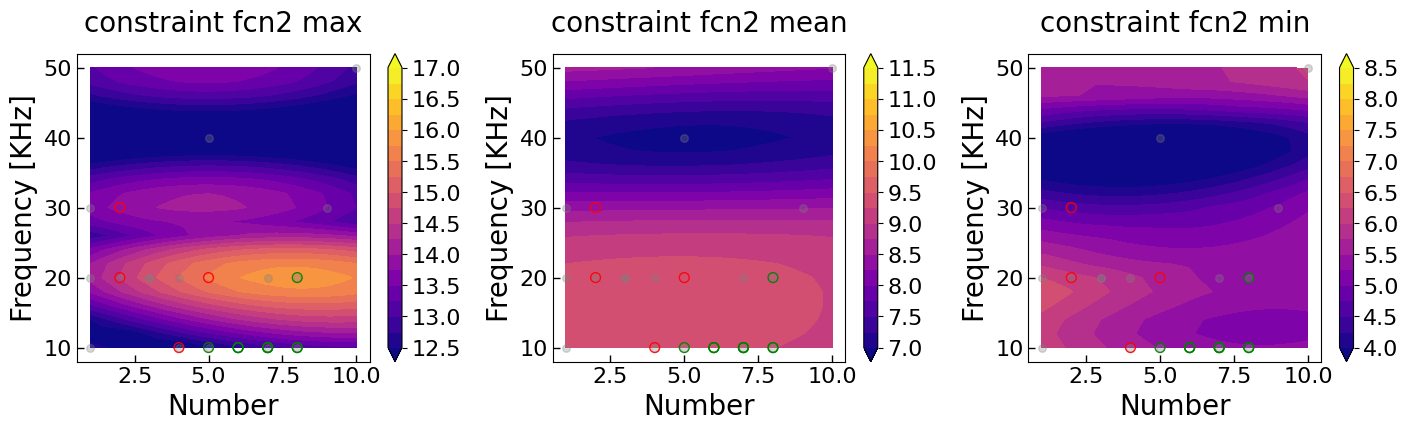

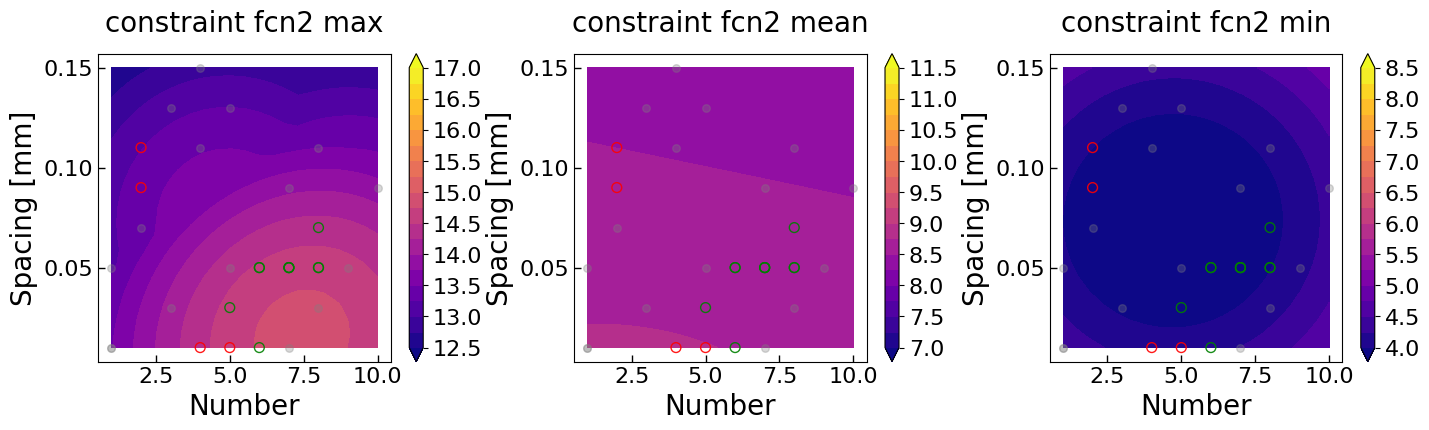

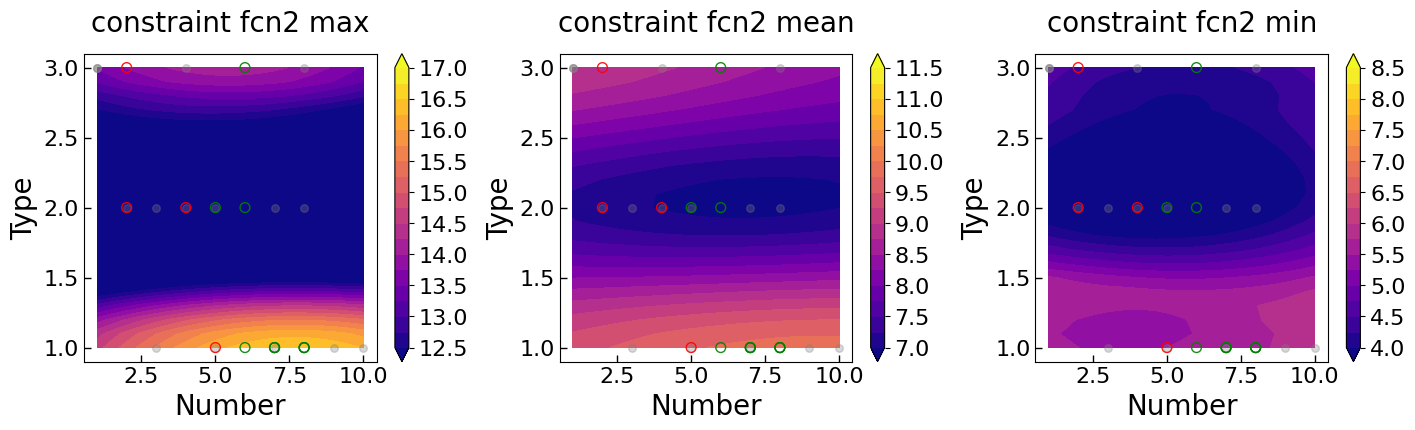

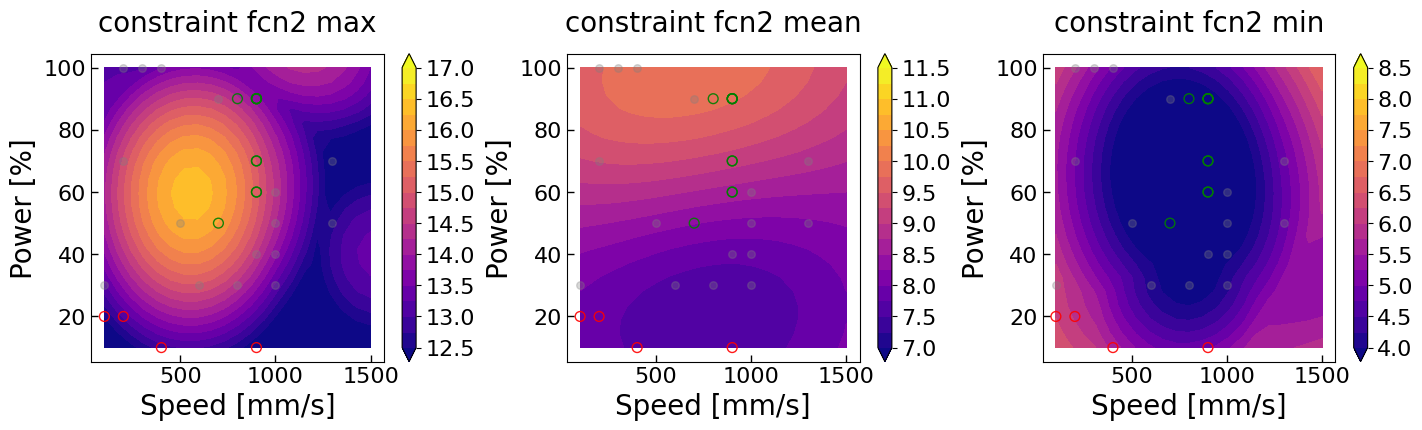

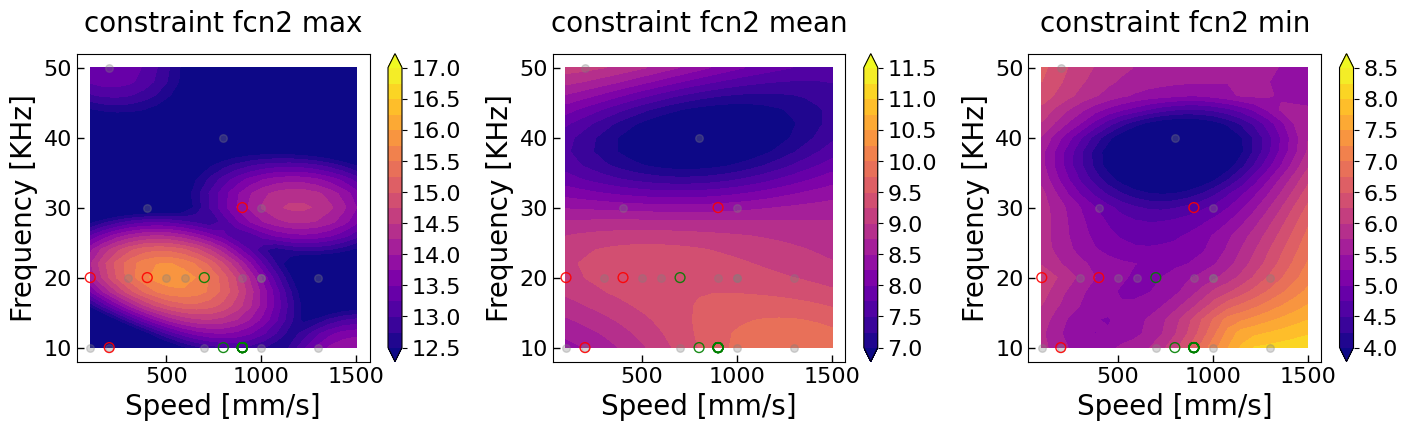

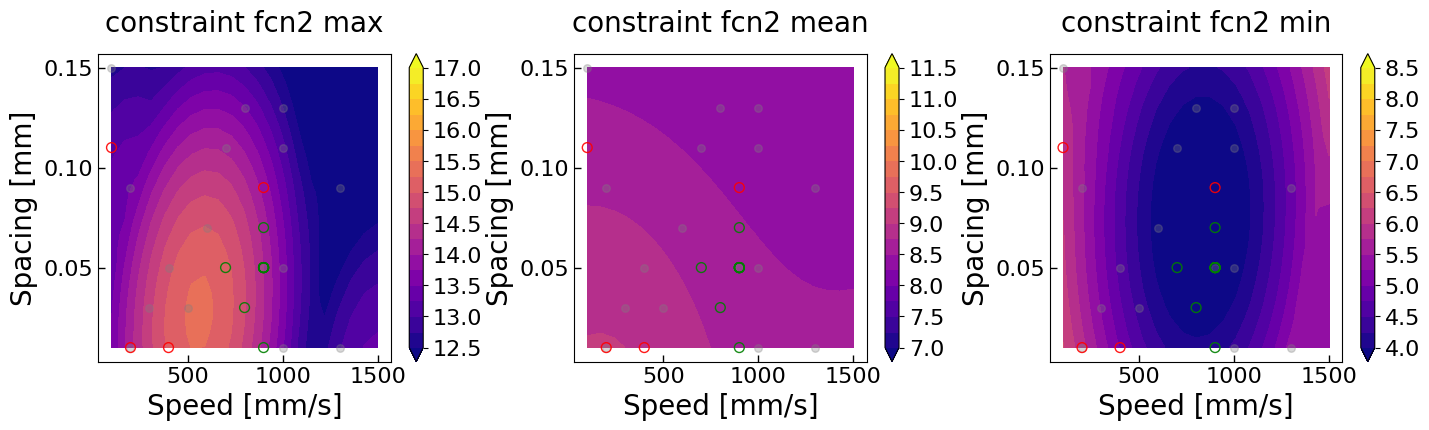

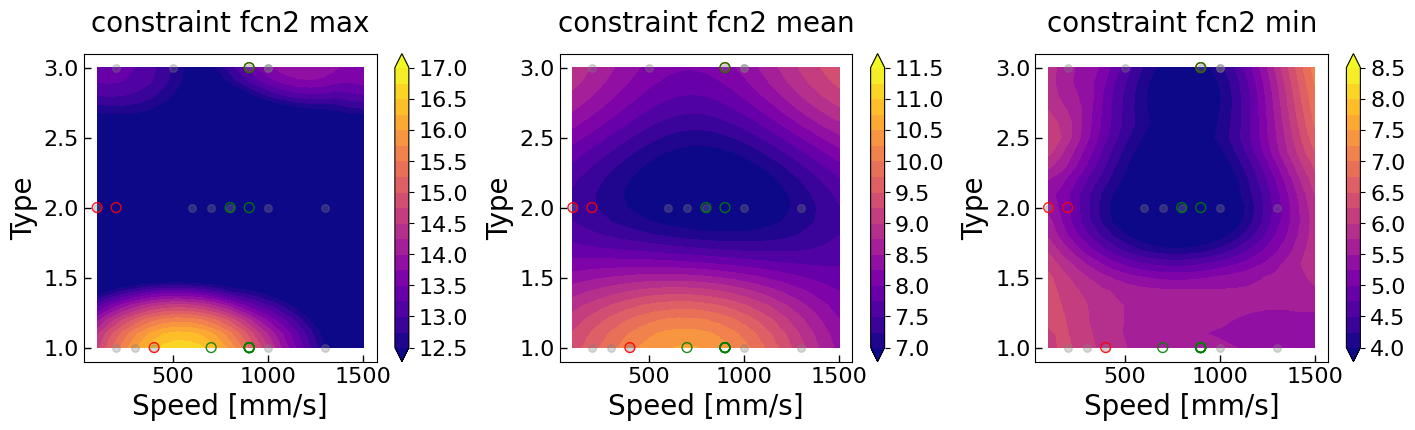

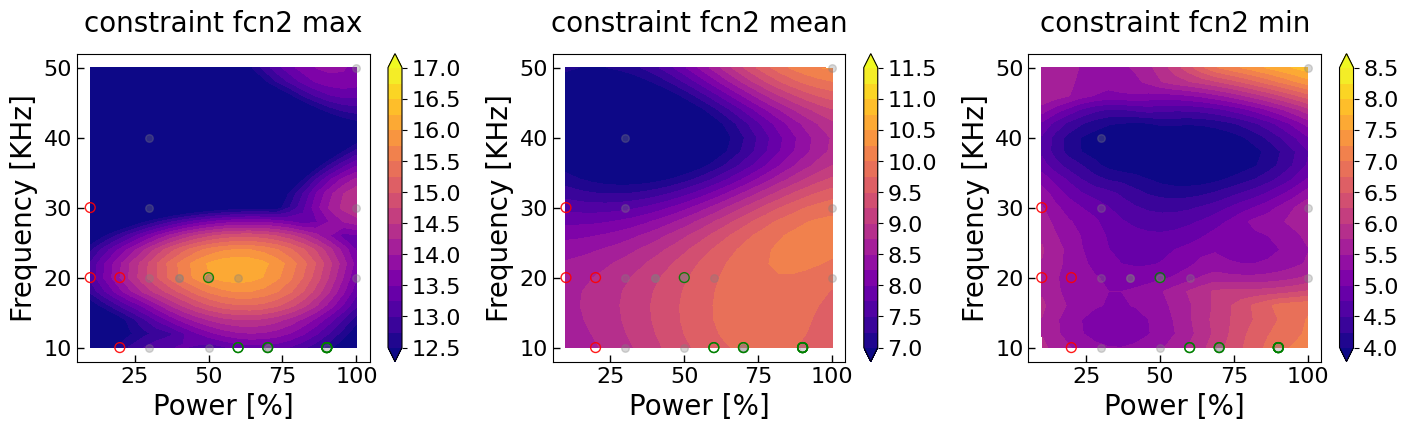

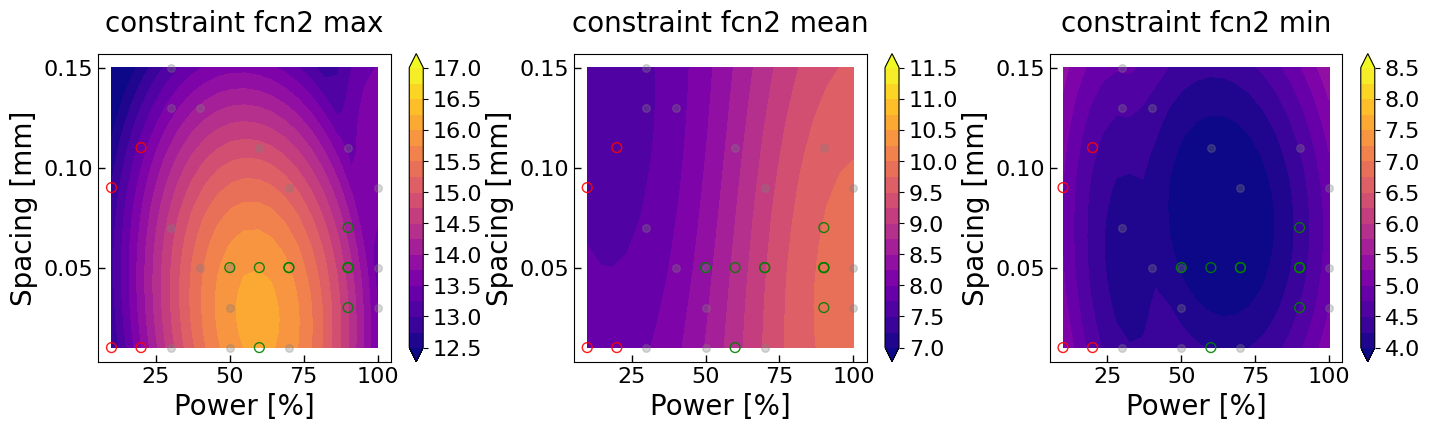

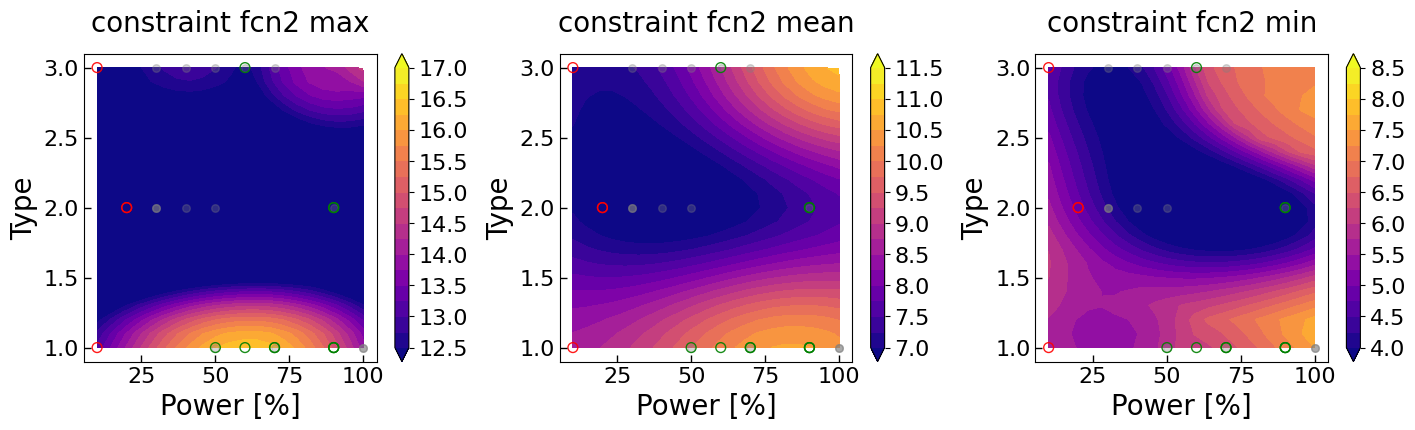

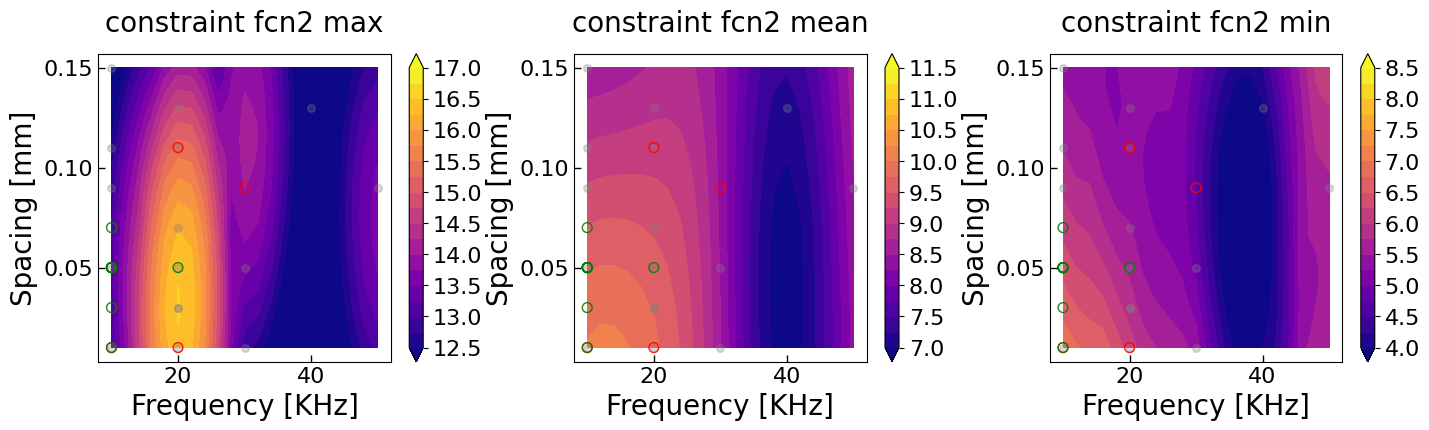

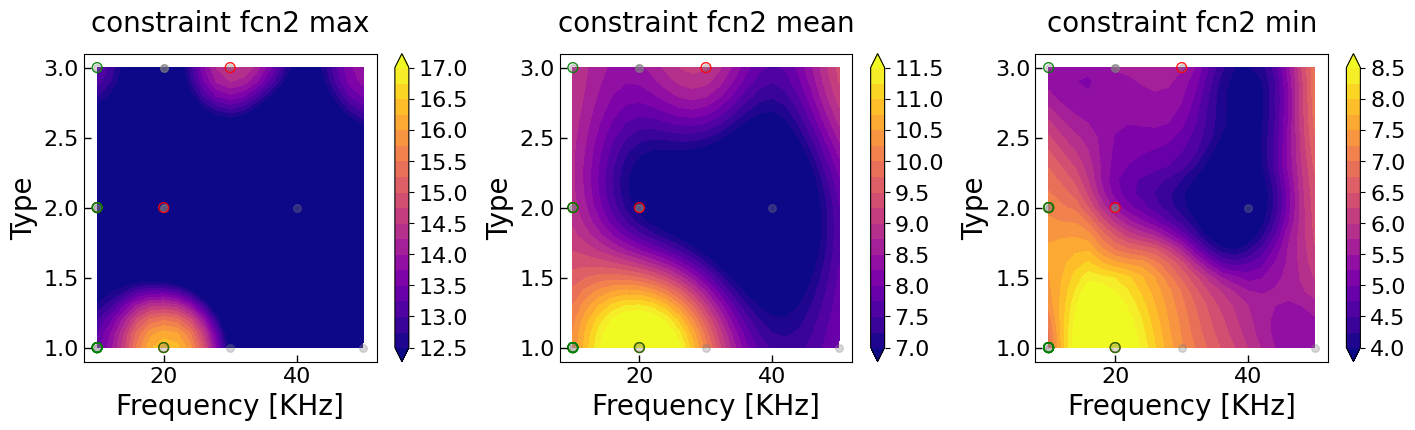

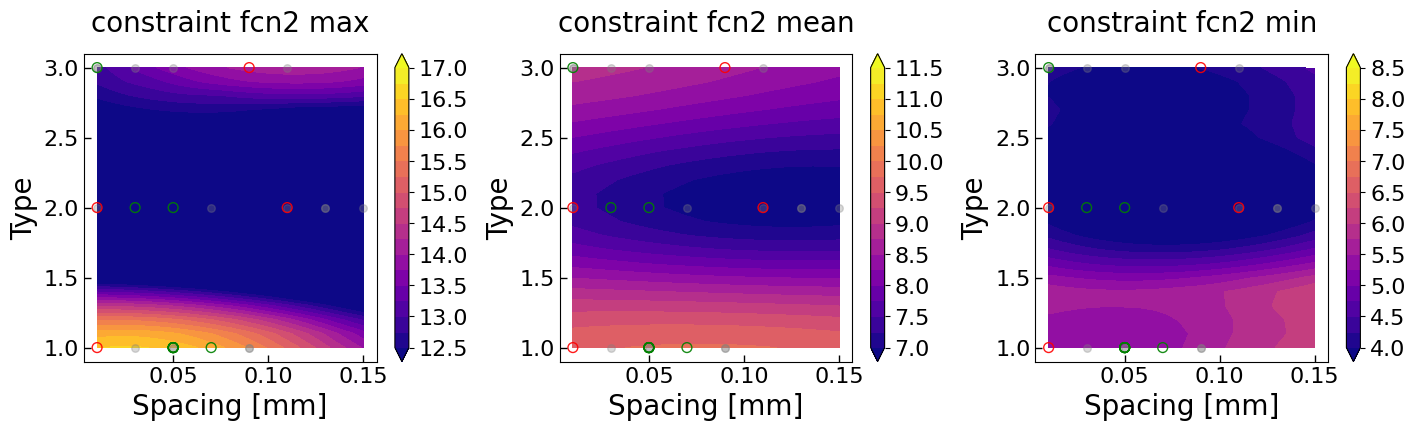

In [24]:
np.random.seed(10)
design = RandomDesign(parameter_space)
x_sampled = design.get_samples(200)
x_columns = df_film.iloc[:,1:7].columns
for i in range(input_dim):
    for j in range(input_dim-i-1):
        ind1 = i
        ind2 = j+i+1
        n_steps =21
        x1x2y_pred, x1x2y_var =[[],[]]
        for x1 in np.linspace(0, 1, n_steps):
            for x2 in np.linspace(0, 1, n_steps):
                x_temp = np.copy(x_sampled)
                x_temp[:,ind1] = x1
                x_temp[:,ind2] = x2
                yc_pr, yc_var = f_cons2(x_temp)
                yc_pr = -yc_pr+yc2_offset
                x1_org = x_denormalizer(x_temp)[0,ind1]
                x2_org = x_denormalizer(x_temp)[0,ind2]
                x1x2y_pred.append([x1_org, x2_org, np.max(yc_pr), np.mean(yc_pr), np.min(yc_pr)])
                
        x1c = np.array(x1x2y_pred, dtype=object)[:,0].reshape(n_steps, n_steps)
        x2c = np.array(x1x2y_pred, dtype=object)[:,1].reshape(n_steps, n_steps)
        yc_pr_max = np.array(x1x2y_pred, dtype=object)[:,2].reshape(n_steps, n_steps)
        yc_pr_mean = np.array(x1x2y_pred, dtype=object)[:,3].reshape(n_steps, n_steps)
        yc_pr_min = np.array(x1x2y_pred, dtype=object)[:,4].reshape(n_steps, n_steps)

        fs = 20
        title_pad = 16
        
        fig,axes = plt.subplots(1, 3, figsize=(17, 4), sharey = False, sharex = False)
        colorbar_offset = [12.5, 7, 4]
        for ax, y, c_offset in zip(axes, [yc_pr_max, yc_pr_mean, yc_pr_min],colorbar_offset):
            c_plt1 = ax.contourf(x1c, x2c, y, levels = np.arange(19)*0.25+c_offset, cmap='plasma', extend = 'both')
            cbar = fig.colorbar(c_plt1, ax= ax)
            cbar.ax.tick_params(labelsize=fs*0.8)
            ax.scatter(x_denormalizer(X)[:, ind1], 
                       x_denormalizer(X)[:, ind2], 
                       s = 30, facecolors='gray', alpha = 0.3, edgecolor = 'gray')
            ax.scatter(x_denormalizer(Xc[Yc[:,-1]==0])[:, ind1], 
                       x_denormalizer(Xc[Yc[:,-1]==0])[:, ind2], 
                       s = 50, facecolors='none', alpha = 0.9, edgecolor = 'red')     
            ax.scatter(x_denormalizer(X_new)[:, ind1], 
                       x_denormalizer(X_new)[:, ind2], 
                       s = 50, facecolors='none', alpha = 0.9, edgecolor = 'green')
            
            ax.set_xlabel(str(x_columns[ind1]), fontsize = fs)
            ax.set_ylabel(str(x_columns[ind2]), fontsize = fs)

            x1_delta = (np.max(x1c)-np.min(x1c))*0.05
            x2_delta = (np.max(x2c)-np.min(x2c))*0.05
            ax.set_xlim(np.min(x1c)-x1_delta, np.max(x1c)+x1_delta)
            ax.set_ylim(np.min(x2c)-x2_delta, np.max(x2c)+x2_delta)
            ax.tick_params(direction='in', length=5, width=1, labelsize = fs*.8, grid_alpha = 0.5)

                
        axes[0].set_title('constraint fcn2 max', pad = title_pad, fontsize = fs)
        axes[1].set_title('constraint fcn2 mean', pad = title_pad, fontsize = fs)
        axes[2].set_title('constraint fcn2 min', pad = title_pad, fontsize = fs)
        plt.subplots_adjust(wspace = 0.3)
        plt.show()

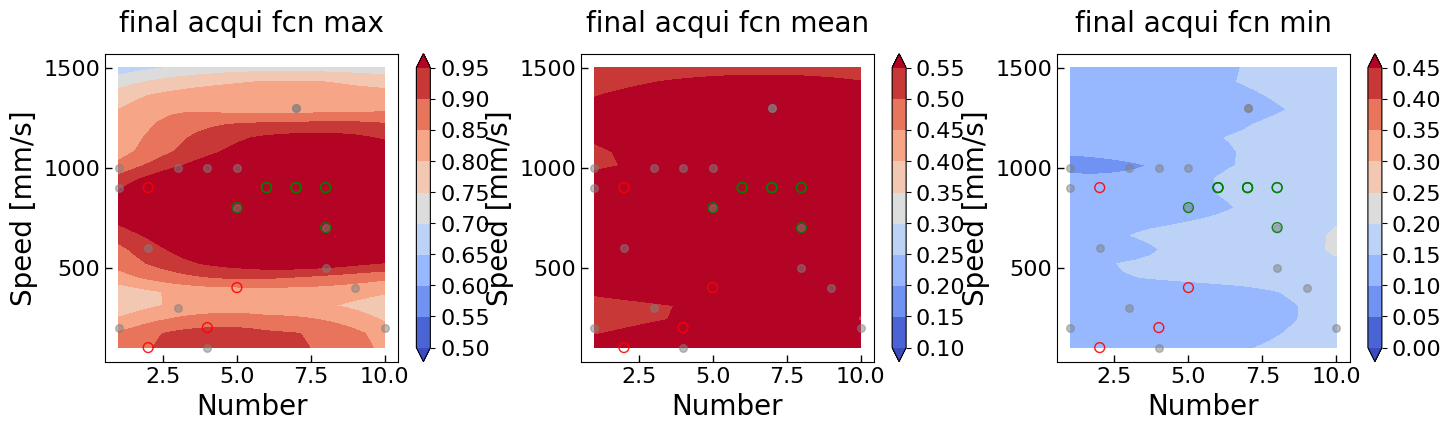

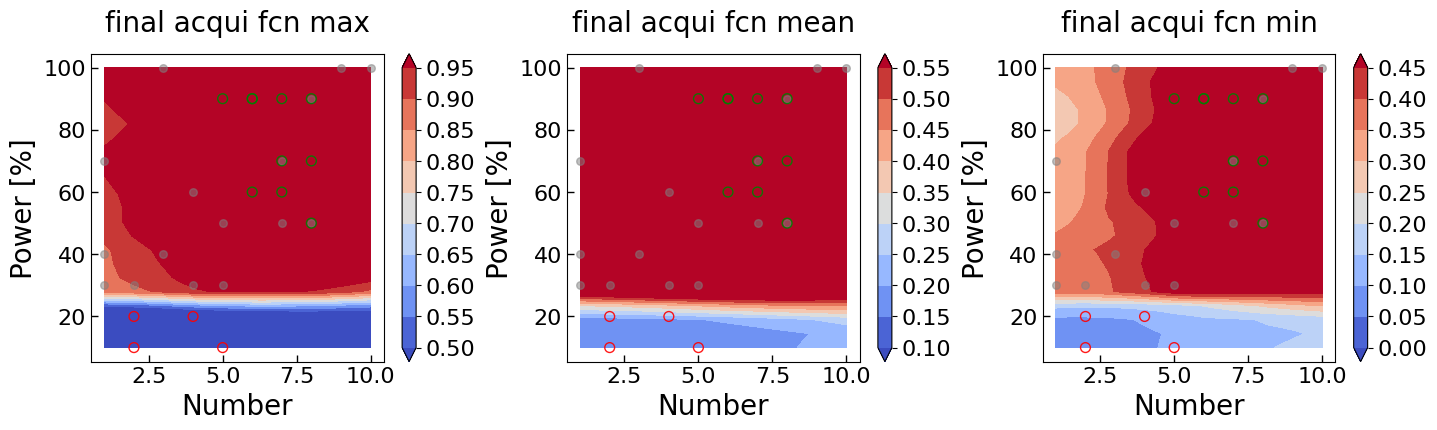

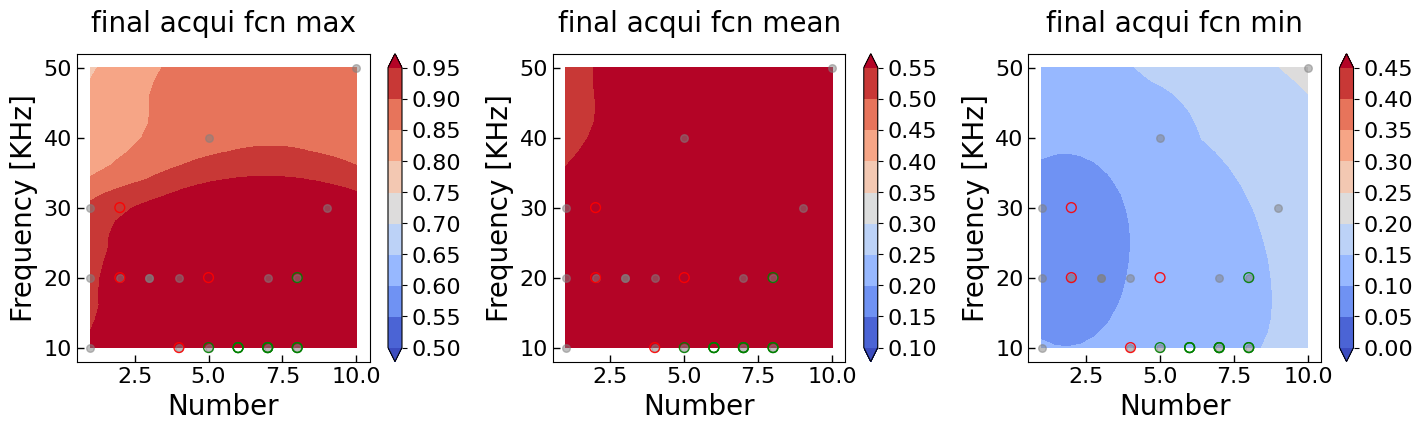

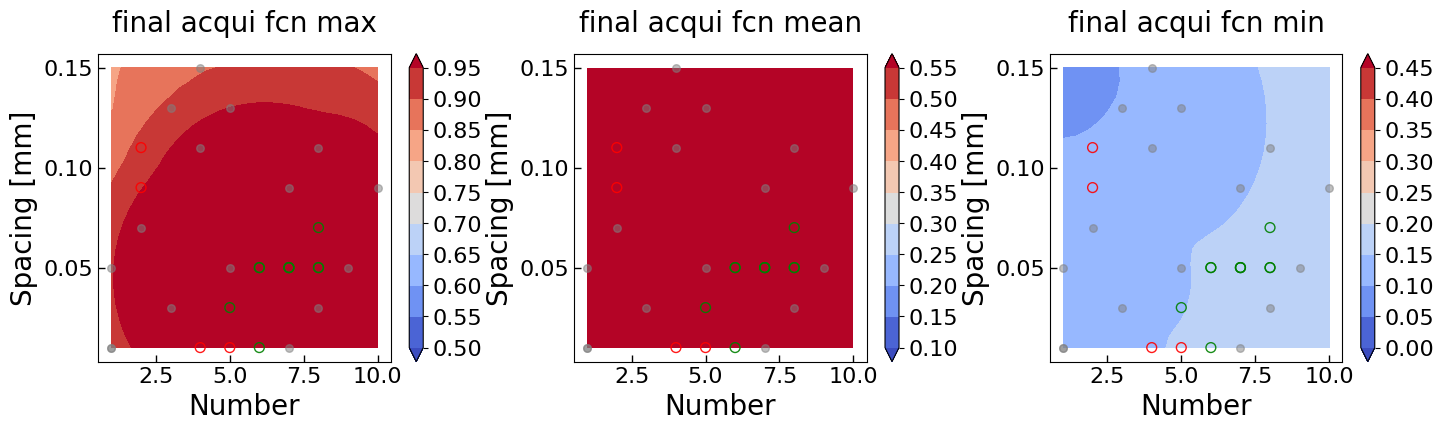

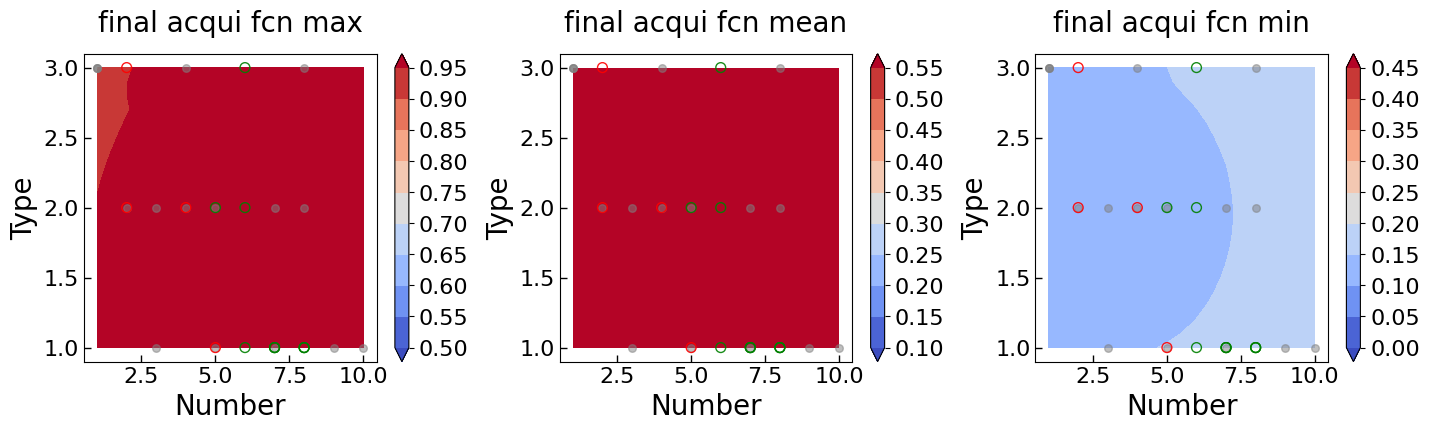

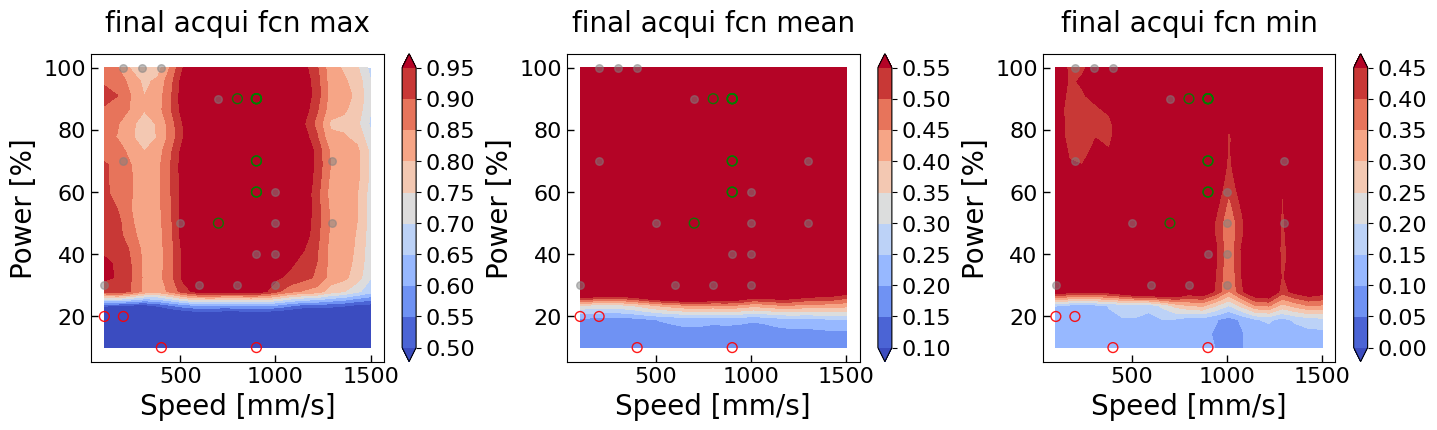

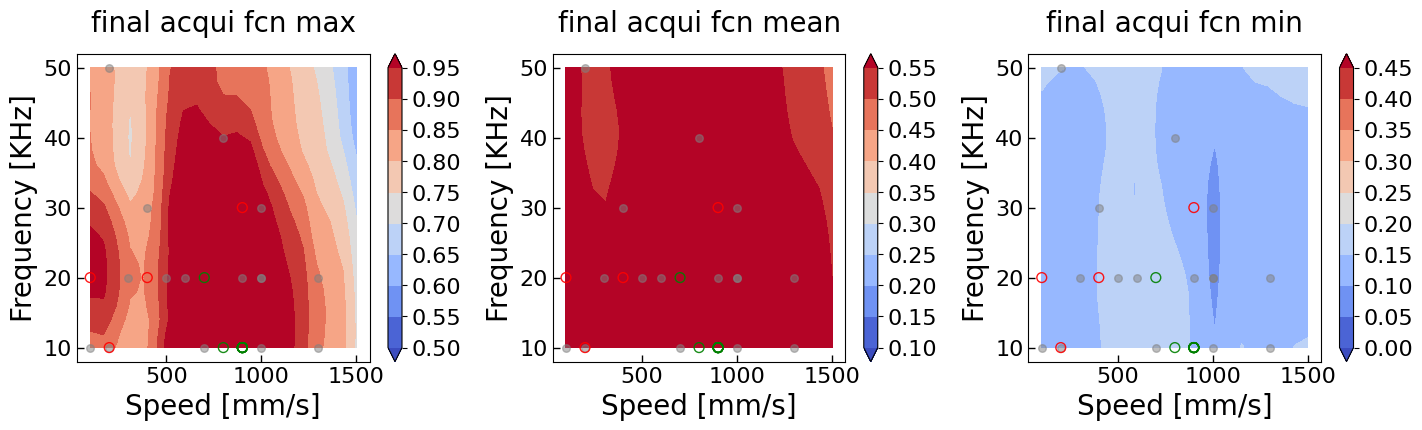

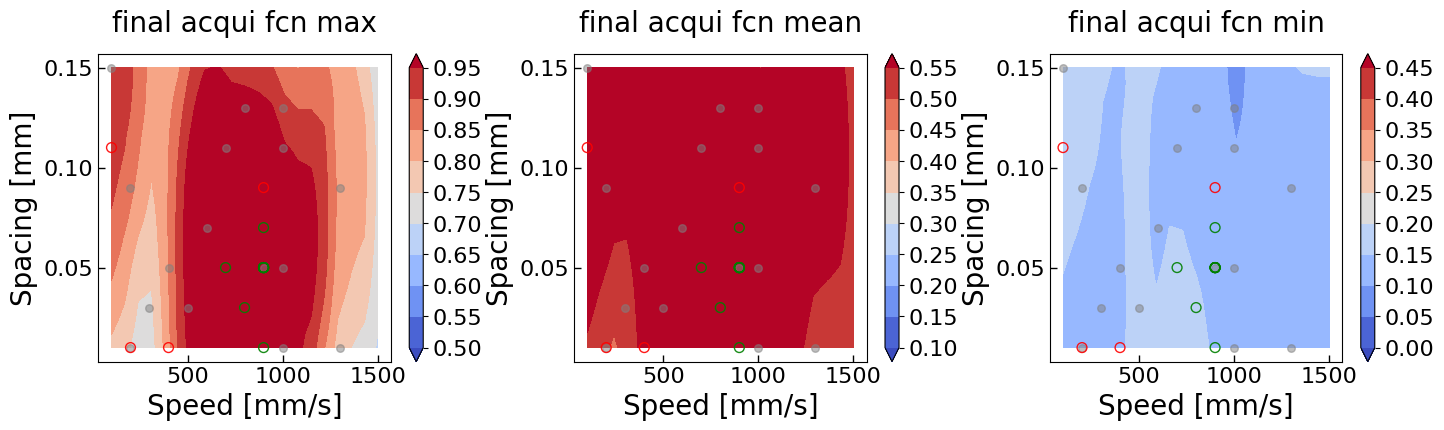

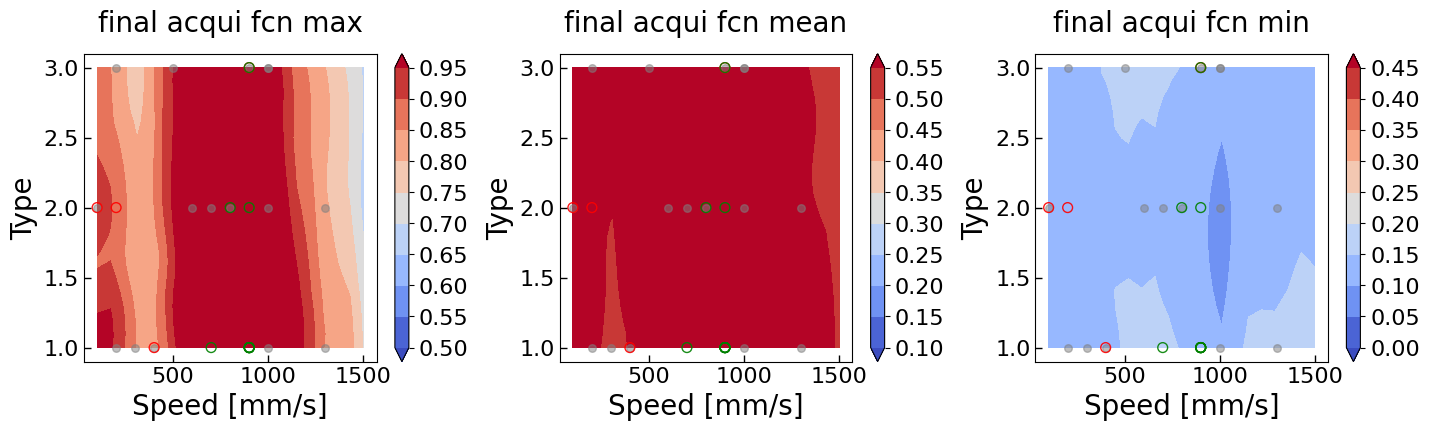

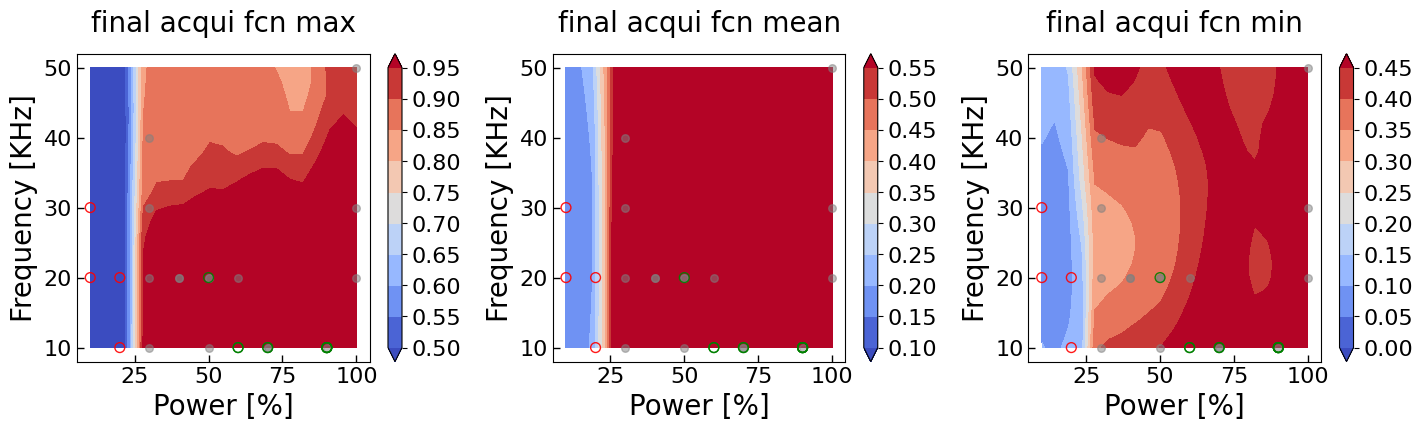

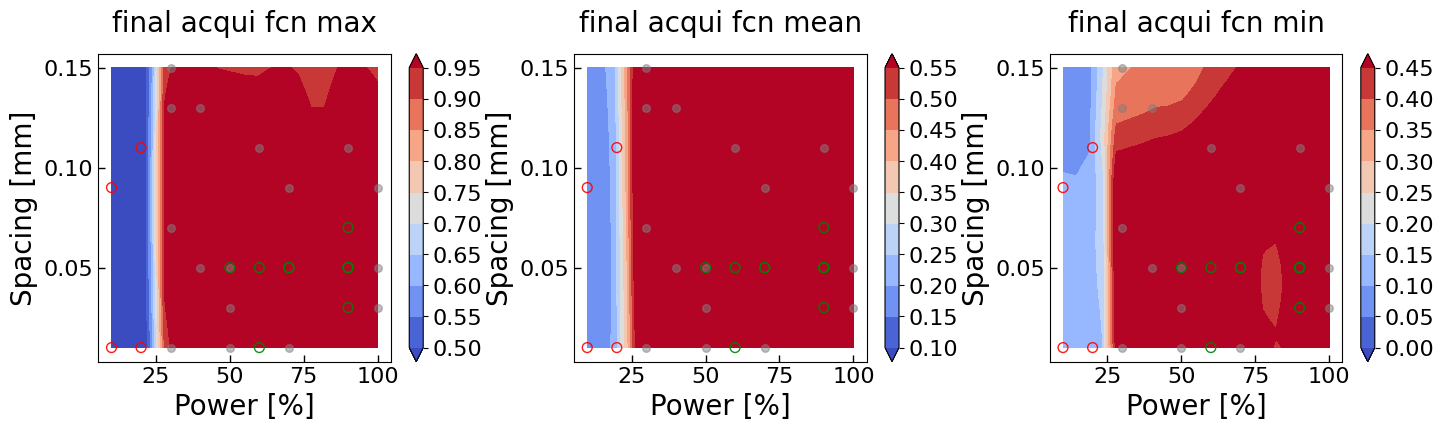

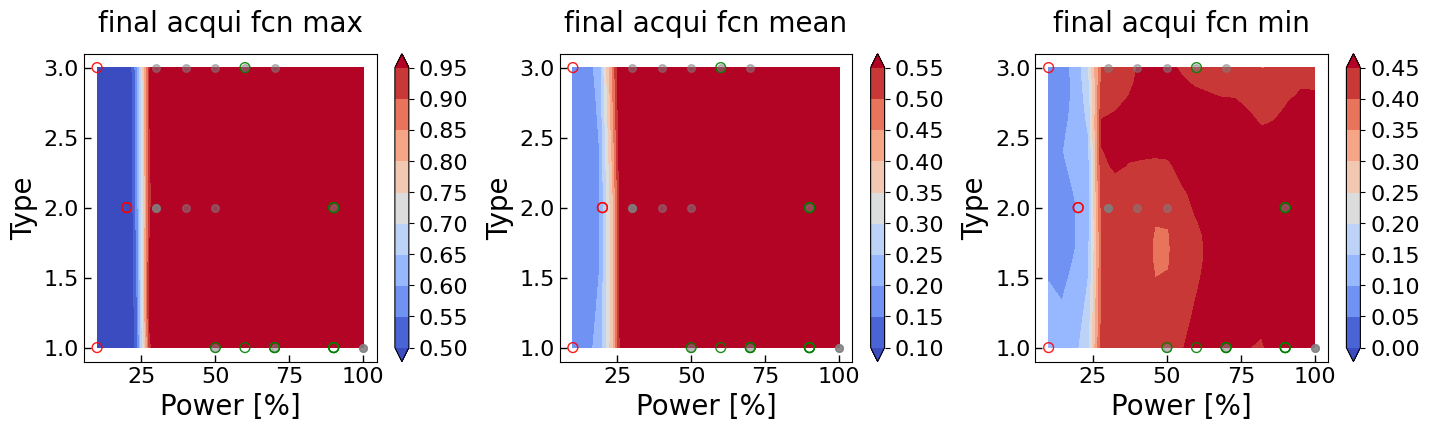

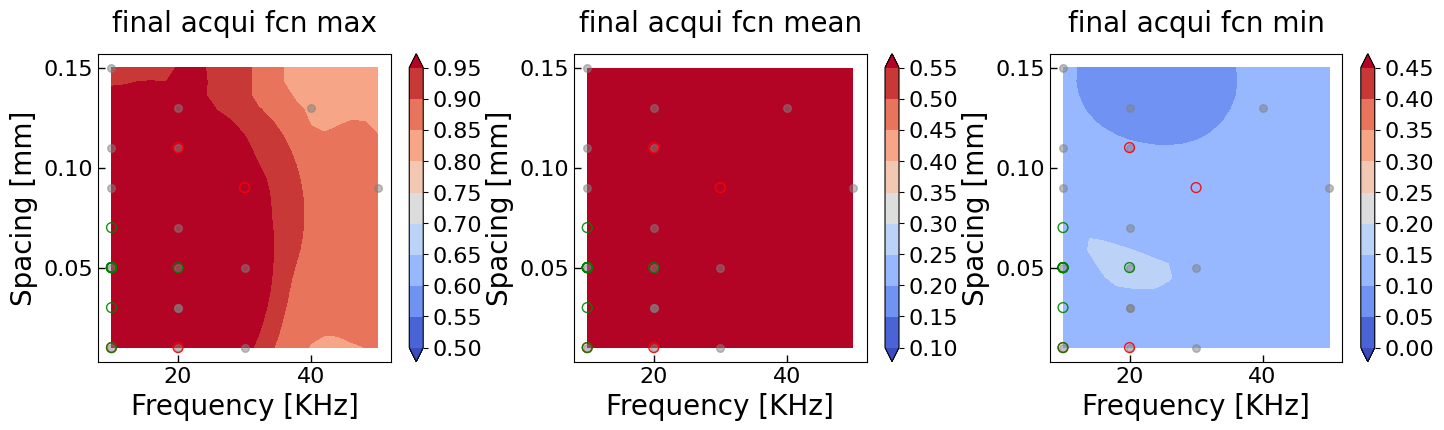

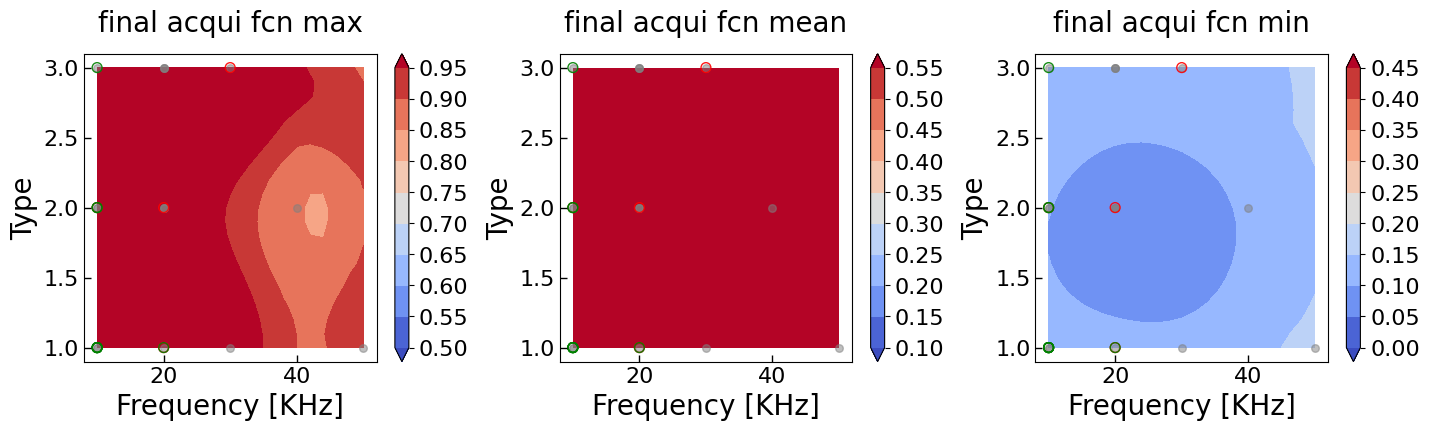

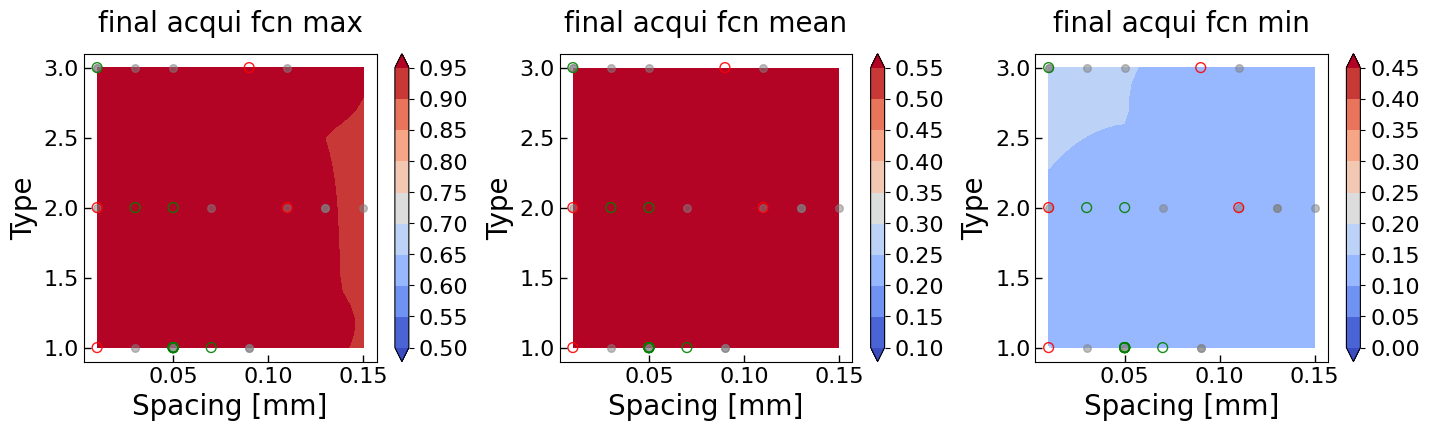

In [25]:
design = RandomDesign(parameter_space)
x_sampled = design.get_samples(200)
x_columns = df_film.iloc[:,1:7].columns
for i in range(input_dim):
    for j in range(input_dim-i-1):
        ind1 = i
        ind2 = j+i+1
        n_steps =21
        x1x2y_pred, x1x2y_var =[[],[]]
        for x1 in np.linspace(0, 1, n_steps):
            for x2 in np.linspace(0, 1, n_steps):
                x_temp = np.copy(x_sampled)
                x_temp[:,ind1] = x1
                x_temp[:,ind2] = x2
                yc_pr = f_cons_acq(x_temp)
                x1_org = x_denormalizer(x_temp)[0,ind1]
                x2_org = x_denormalizer(x_temp)[0,ind2]
                x1x2y_pred.append([x1_org, x2_org, np.max(yc_pr), np.mean(yc_pr), np.min(yc_pr)])
                
        x1c = np.array(x1x2y_pred, dtype=object)[:,0].reshape(n_steps, n_steps)
        x2c = np.array(x1x2y_pred, dtype=object)[:,1].reshape(n_steps, n_steps)
        yc_pr_max = np.array(x1x2y_pred, dtype=object)[:,2].reshape(n_steps, n_steps)
        yc_pr_mean = np.array(x1x2y_pred, dtype=object)[:,3].reshape(n_steps, n_steps)
        yc_pr_min = np.array(x1x2y_pred, dtype=object)[:,4].reshape(n_steps, n_steps)

        fs = 20
        title_pad = 16
        
        fig,axes = plt.subplots(1, 3, figsize=(17, 4), sharey = False, sharex = False)
        colorbar_offset = [0.5, 0.1, 0.0]
        for ax, y, c_offset in zip(axes, [yc_pr_max, yc_pr_mean, yc_pr_min],colorbar_offset):
            c_plt1 = ax.contourf(x1c, x2c, y/20, levels = np.arange(10)*0.05+c_offset, cmap='coolwarm', extend = 'both')# 
            cbar = fig.colorbar(c_plt1, ax= ax)
            cbar.ax.tick_params(labelsize=fs*0.8)
            ax.scatter(x_denormalizer(X)[:, ind1], 
                       x_denormalizer(X)[:, ind2], 
                       s = 30, facecolors='gray', alpha = 0.5, edgecolor = 'gray')
            ax.scatter(x_denormalizer(Xc[Yc[:,-1]==0])[:, ind1], 
                       x_denormalizer(Xc[Yc[:,-1]==0])[:, ind2], 
                       s = 50, facecolors='none', alpha = 0.9, edgecolor = 'red')
            ax.scatter(x_denormalizer(X_new)[:, ind1], 
                       x_denormalizer(X_new)[:, ind2], 
                       s = 50, facecolors='none', alpha = 0.9, edgecolor = 'green')
            ax.set_xlabel(str(x_columns[ind1]),fontsize = fs)
            ax.set_ylabel(str(x_columns[ind2]),fontsize = fs)

            x1_delta = (np.max(x1c)-np.min(x1c))*0.05
            x2_delta = (np.max(x2c)-np.min(x2c))*0.05
            ax.set_xlim(np.min(x1c)-x1_delta, np.max(x1c)+x1_delta)
            ax.set_ylim(np.min(x2c)-x2_delta, np.max(x2c)+x2_delta)
            ax.tick_params(direction='in', length=5, width=1, labelsize = fs*.8, grid_alpha = 0.5)

            
        axes[0].set_title('final acqui fcn max', pad = title_pad,fontsize = fs)
        axes[1].set_title('final acqui fcn mean', pad = title_pad,fontsize = fs)
        axes[2].set_title('final acqui fcn min', pad = title_pad,fontsize = fs)
        plt.subplots_adjust(wspace = 0.3)
        plt.show()

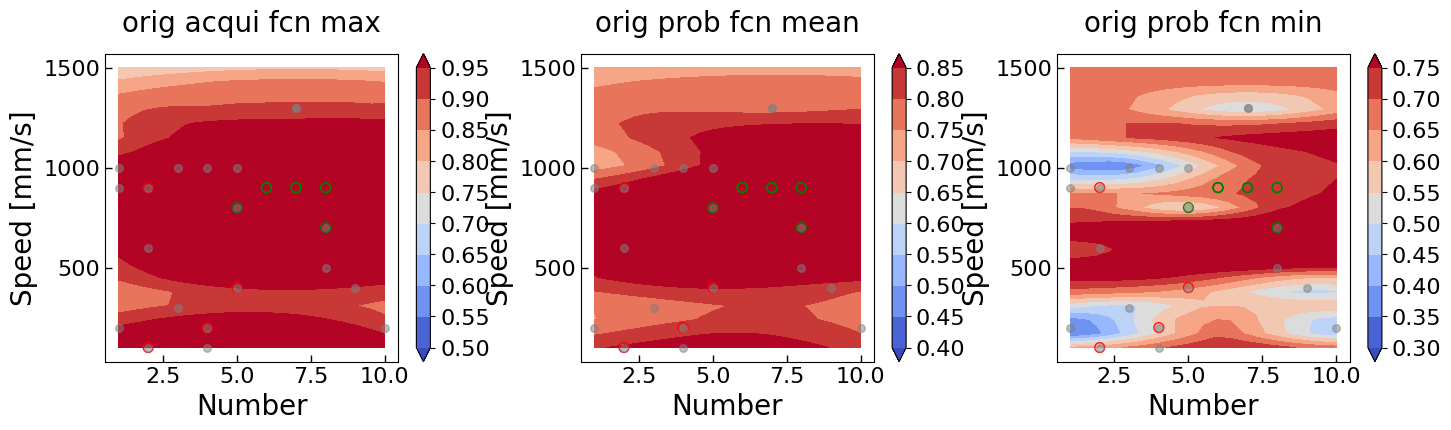

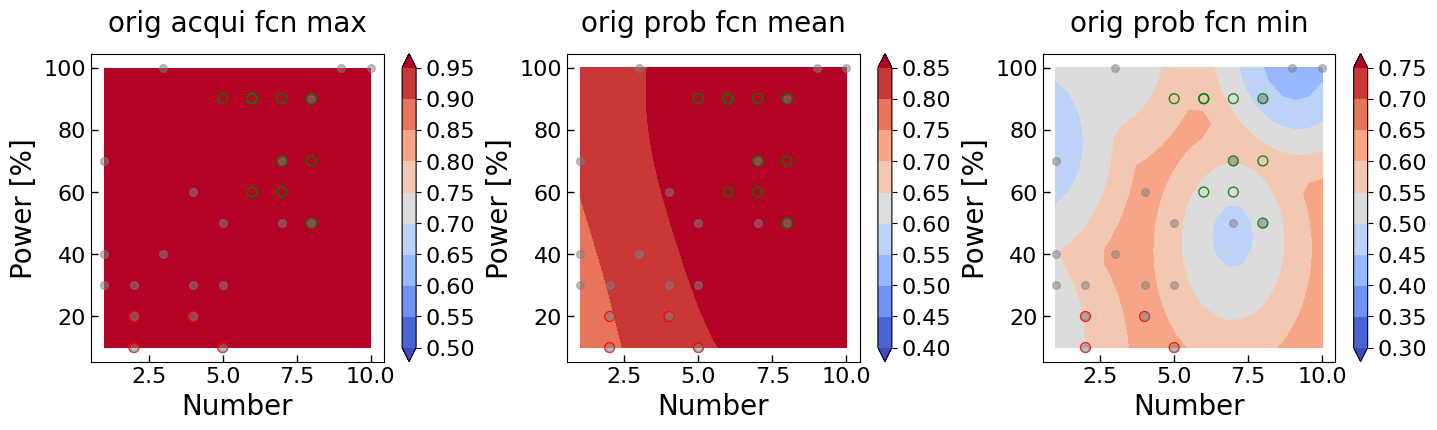

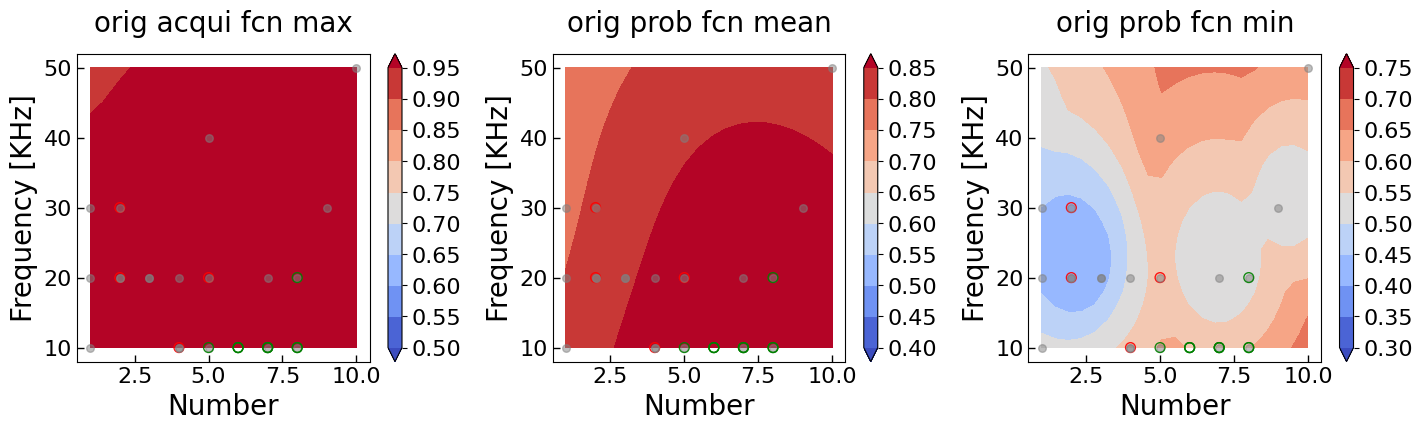

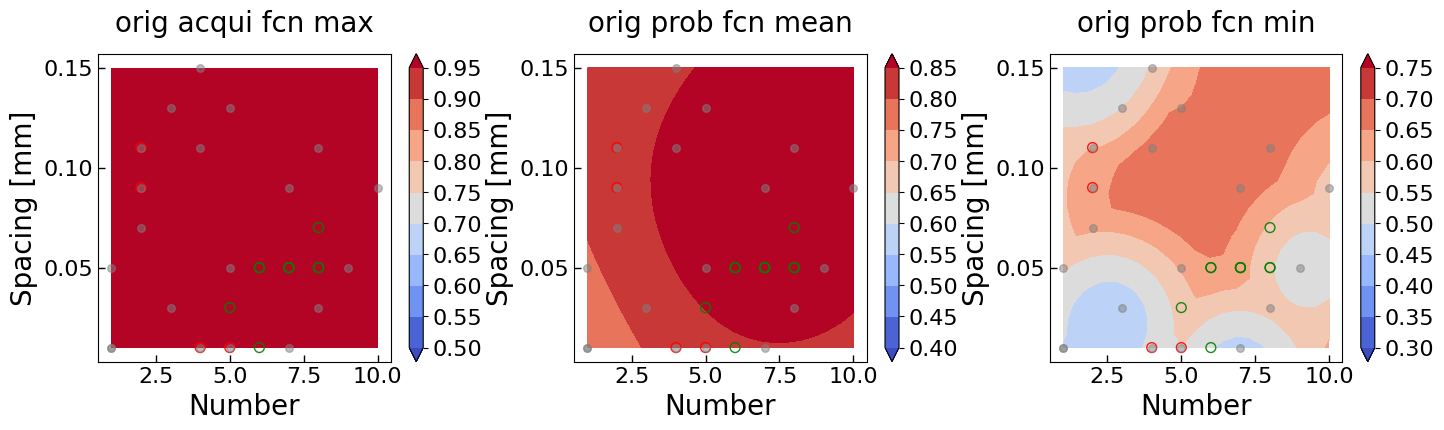

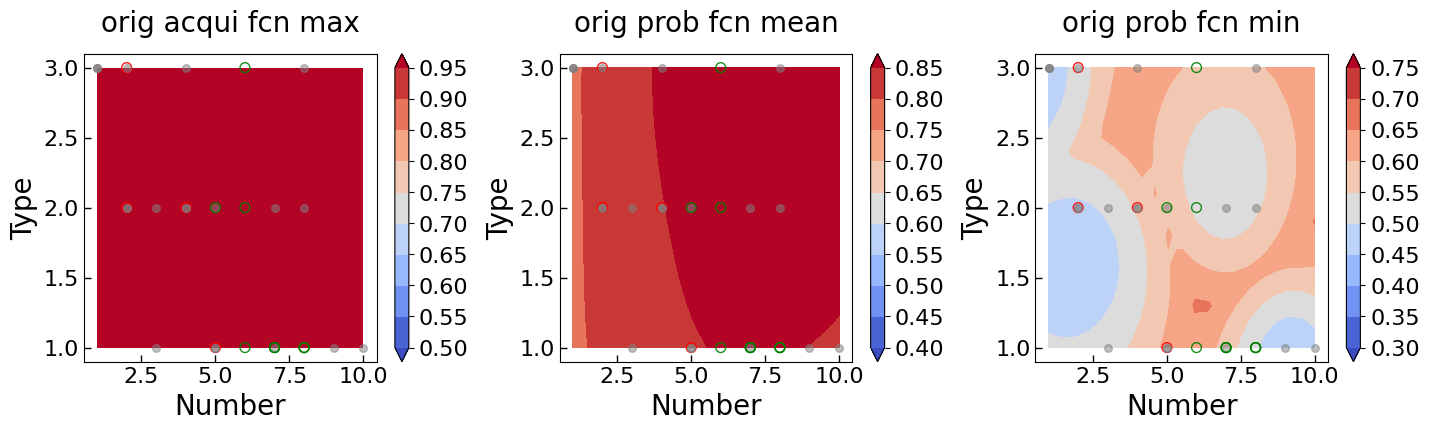

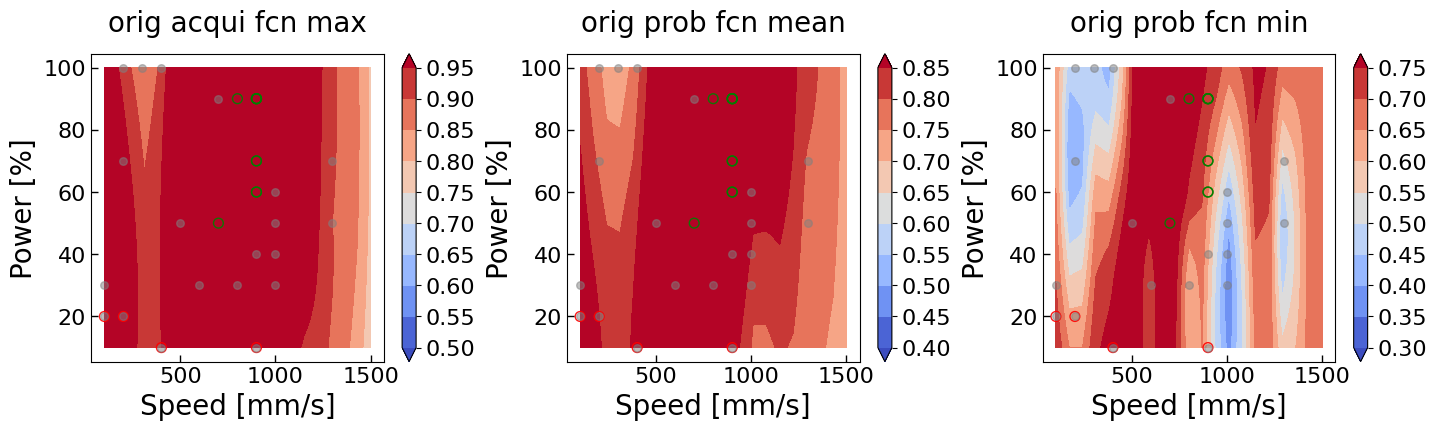

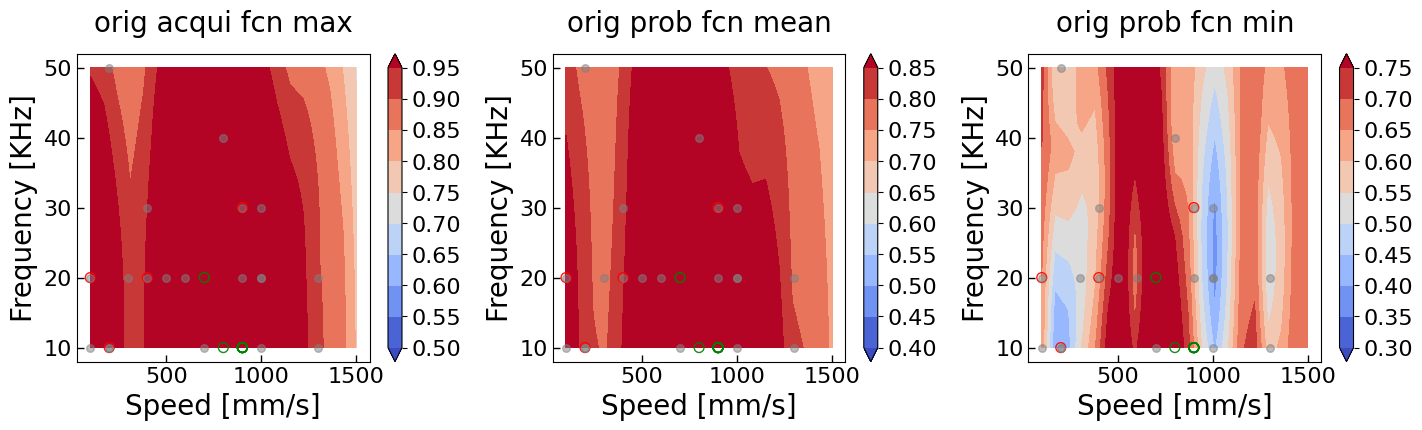

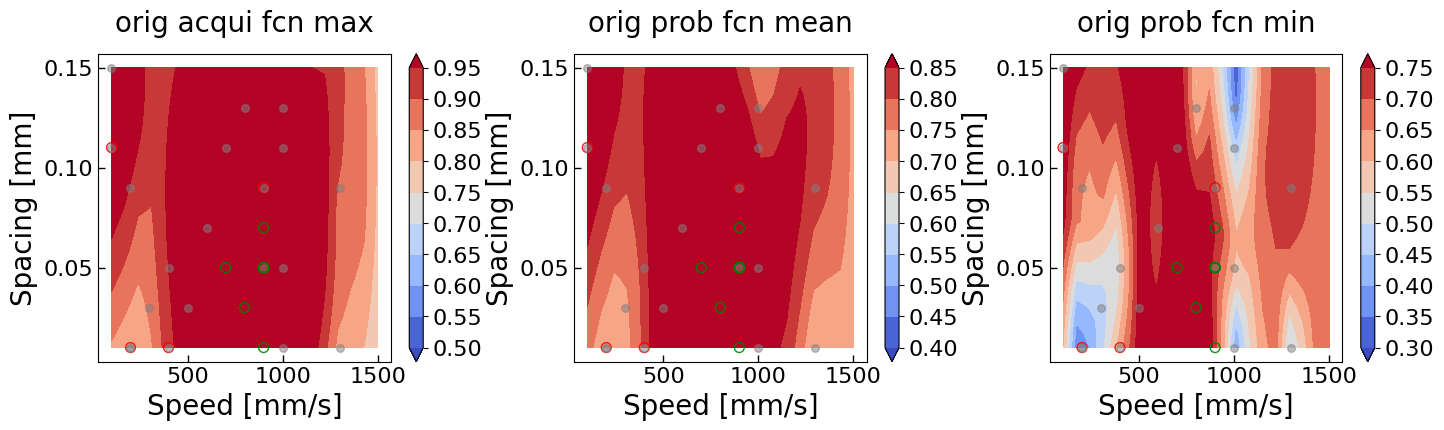

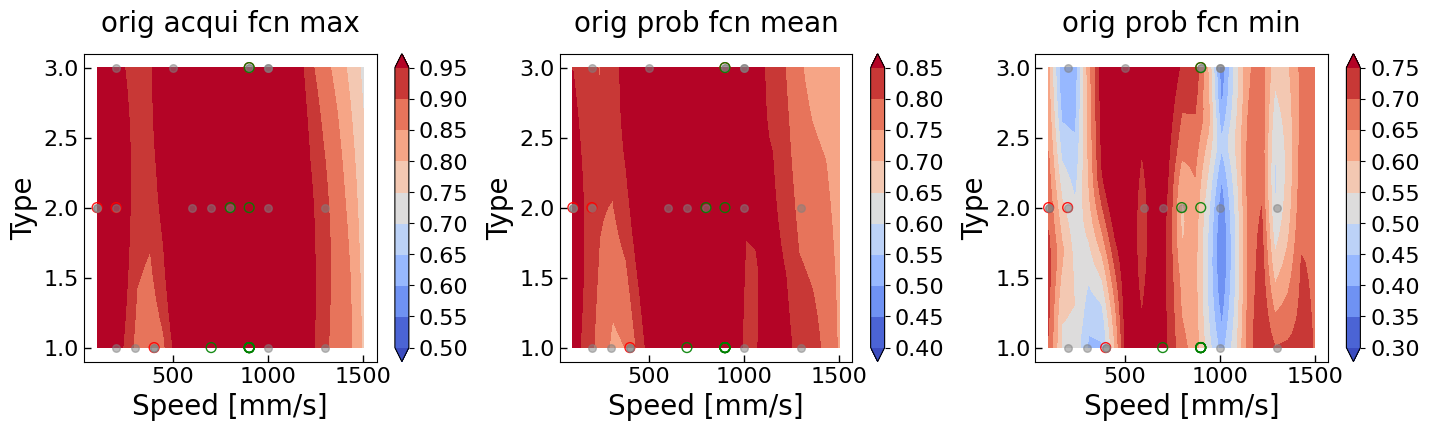

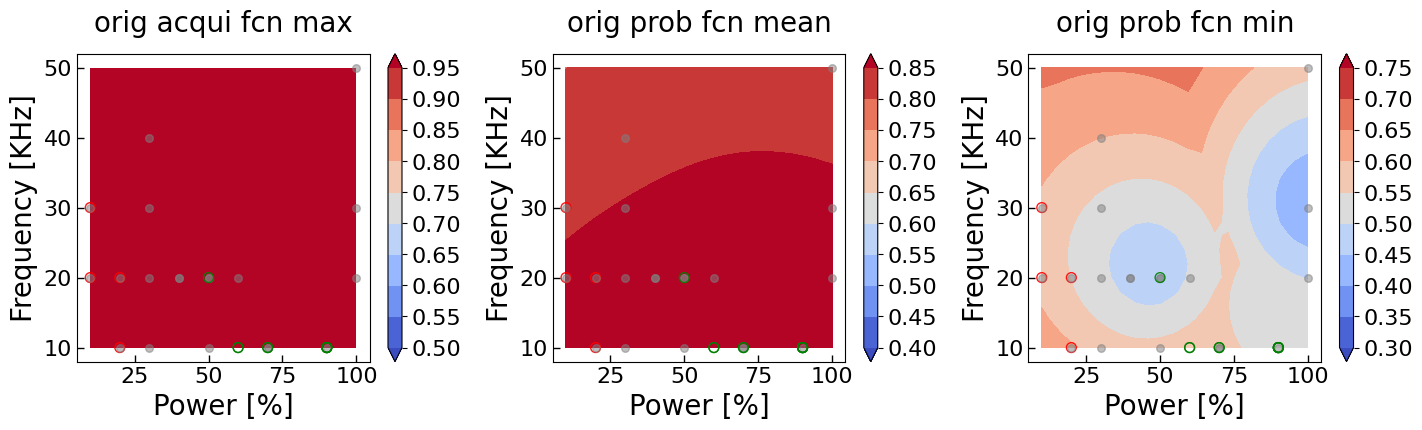

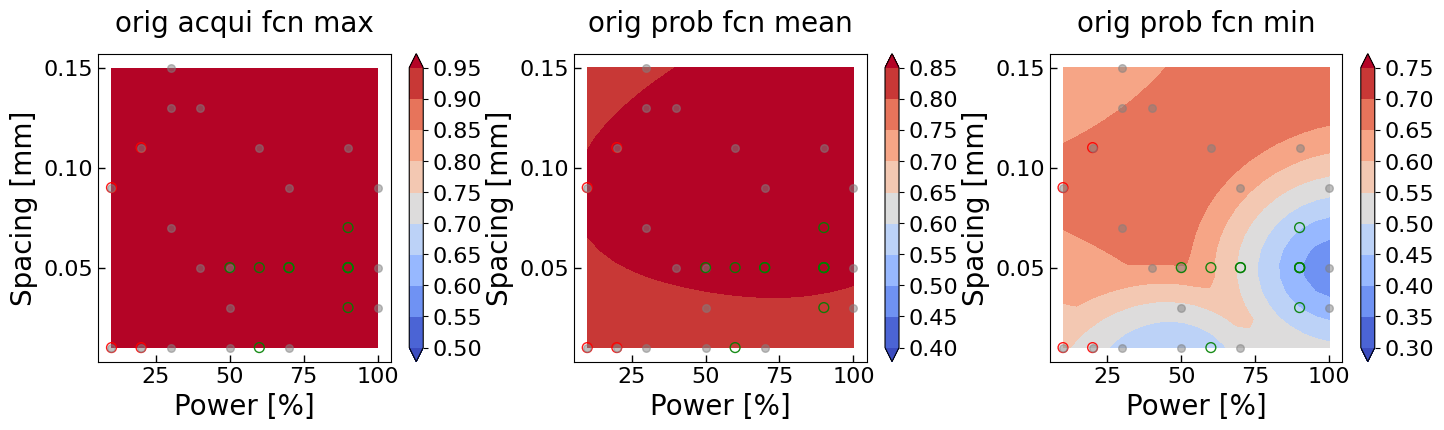

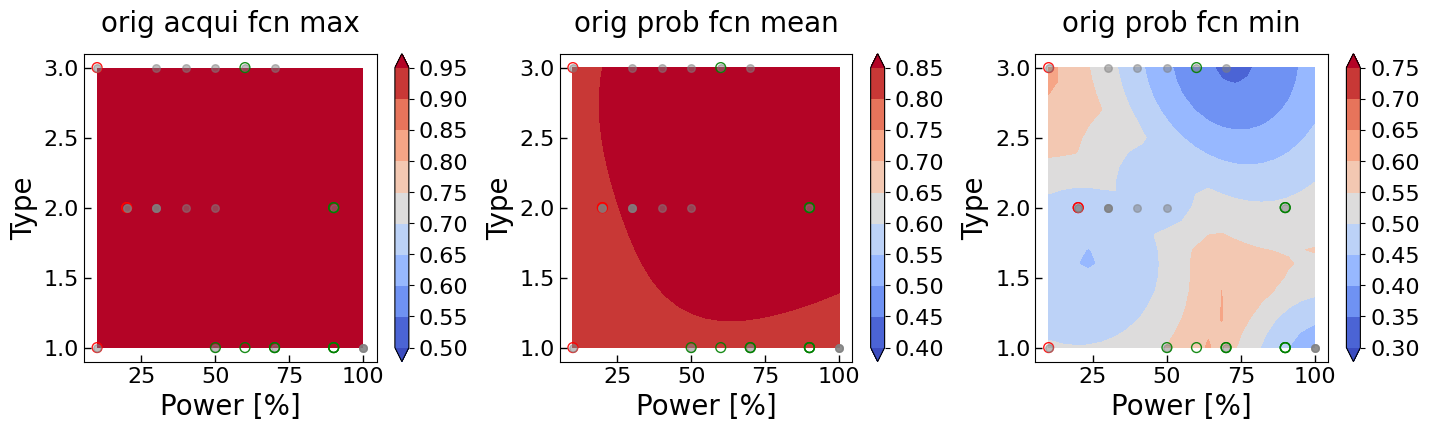

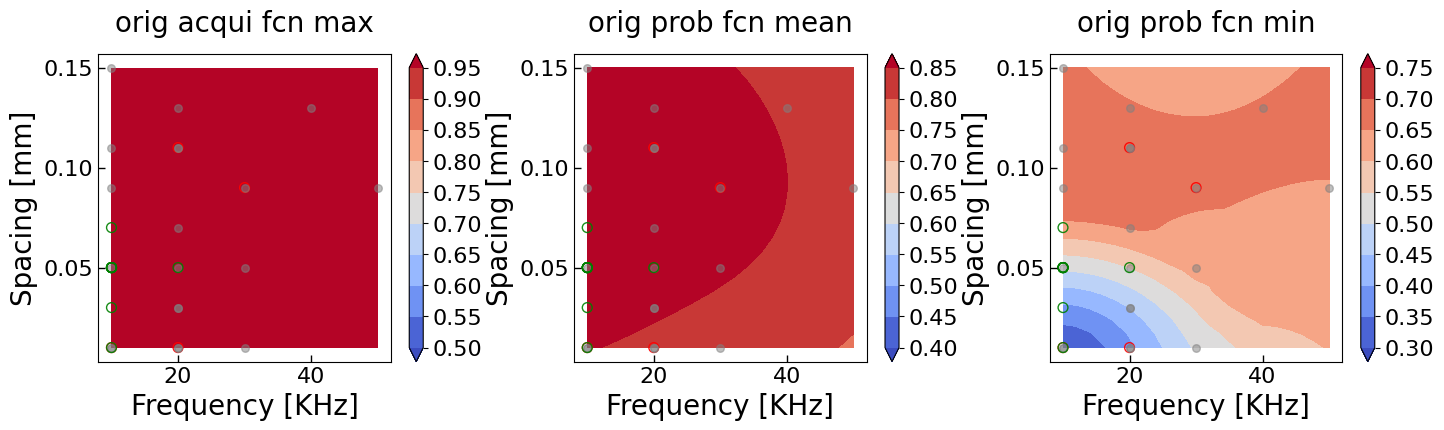

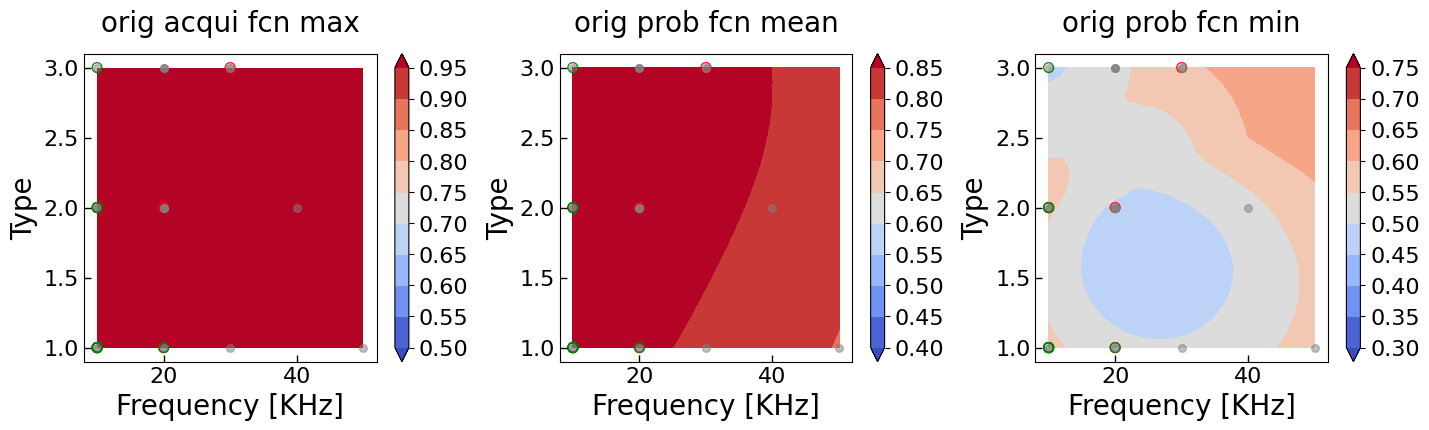

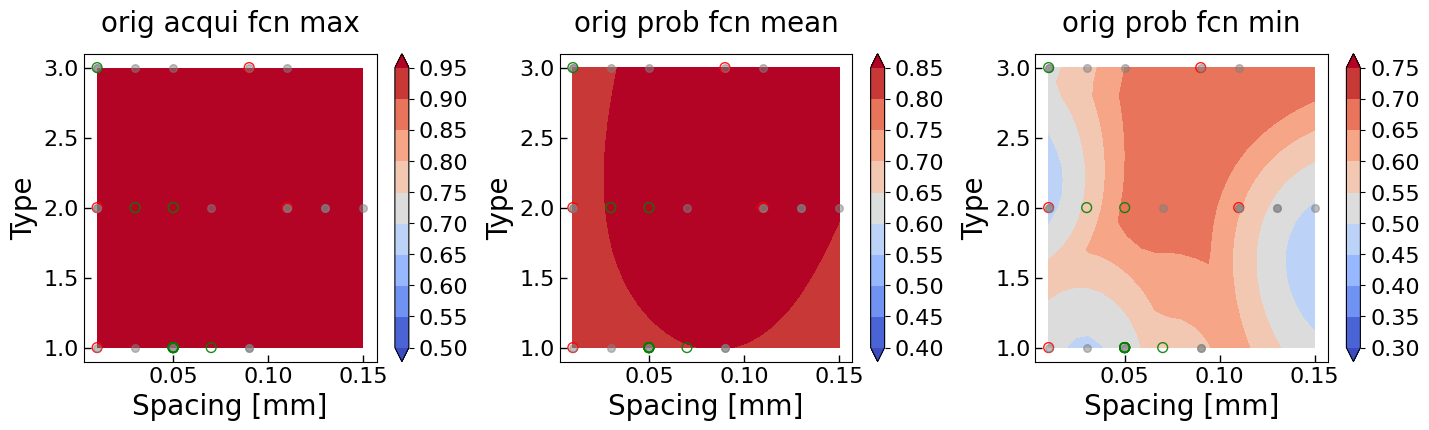

In [26]:
design = RandomDesign(parameter_space)
x_sampled = design.get_samples(200)
x_columns = df_film.iloc[:,1:7].columns
for i in range(input_dim):
    for j in range(input_dim-i-1):
        ind1 = i
        ind2 = j+i+1
        n_steps =21
        x1x2y_pred, x1x2y_var =[[],[]]
        for x1 in np.linspace(0, 1, n_steps):
            for x2 in np.linspace(0, 1, n_steps):
                x_temp = np.copy(x_sampled)
                x_temp[:,ind1] = x1
                x_temp[:,ind2] = x2
                yc_pr = f_raw_acq(x_temp)
                x1_org = x_denormalizer(x_temp)[0,ind1]
                x2_org = x_denormalizer(x_temp)[0,ind2]
                x1x2y_pred.append([x1_org, x2_org, np.max(yc_pr), np.mean(yc_pr), np.min(yc_pr)])
                
        x1c = np.array(x1x2y_pred, dtype=object)[:,0].reshape(n_steps, n_steps)
        x2c = np.array(x1x2y_pred, dtype=object)[:,1].reshape(n_steps, n_steps)
        yc_pr_max = np.array(x1x2y_pred, dtype=object)[:,2].reshape(n_steps, n_steps)
        yc_pr_mean = np.array(x1x2y_pred, dtype=object)[:,3].reshape(n_steps, n_steps)
        yc_pr_min = np.array(x1x2y_pred, dtype=object)[:,4].reshape(n_steps, n_steps)

        fs = 20
        title_pad = 16
        
        fig,axes = plt.subplots(1, 3, figsize=(17, 4), sharey = False, sharex = False)
        colorbar_offset = [0.5, 0.4, 0.3]
        for ax, y, c_offset in zip(axes, [yc_pr_max, yc_pr_mean, yc_pr_min],colorbar_offset):
            c_plt1 = ax.contourf(x1c, x2c, y/20,levels = np.arange(10)*0.05+c_offset, cmap='coolwarm', extend = 'both')# 
            cbar = fig.colorbar(c_plt1, ax= ax)
            cbar.ax.tick_params(labelsize=fs*0.8)
            ax.scatter(x_denormalizer(Xc[Yc[:,-1]==0])[:, ind1], 
                   x_denormalizer(Xc[Yc[:,-1]==0])[:, ind2], 
                   s = 50, facecolors='none', alpha = 0.9, edgecolor = 'red')
            ax.scatter(x_denormalizer(Xc)[:, ind1], 
                       x_denormalizer(Xc)[:, ind2], 
                       s = 30, facecolors='gray', alpha = 0.5, edgecolor = 'gray')
            ax.scatter(x_denormalizer(X_new)[:, ind1], 
                       x_denormalizer(X_new)[:, ind2], 
                       s = 50, facecolors='none', alpha = 0.9, edgecolor = 'green')

            ax.set_xlabel(str(x_columns[ind1]), fontsize = fs)
            ax.set_ylabel(str(x_columns[ind2]), fontsize = fs)

            x1_delta = (np.max(x1c)-np.min(x1c))*0.05
            x2_delta = (np.max(x2c)-np.min(x2c))*0.05
            ax.set_xlim(np.min(x1c)-x1_delta, np.max(x1c)+x1_delta)
            ax.set_ylim(np.min(x2c)-x2_delta, np.max(x2c)+x2_delta)
            ax.tick_params(direction='in', length=5, width=1, labelsize = fs*.8, grid_alpha = 0.5)


        axes[0].set_title('orig acqui fcn max', pad = title_pad, fontsize = fs)
        axes[1].set_title('orig prob fcn mean', pad = title_pad, fontsize = fs)
        axes[2].set_title('orig prob fcn min', pad = title_pad, fontsize = fs)
        plt.subplots_adjust(wspace = 0.3)
        plt.show()

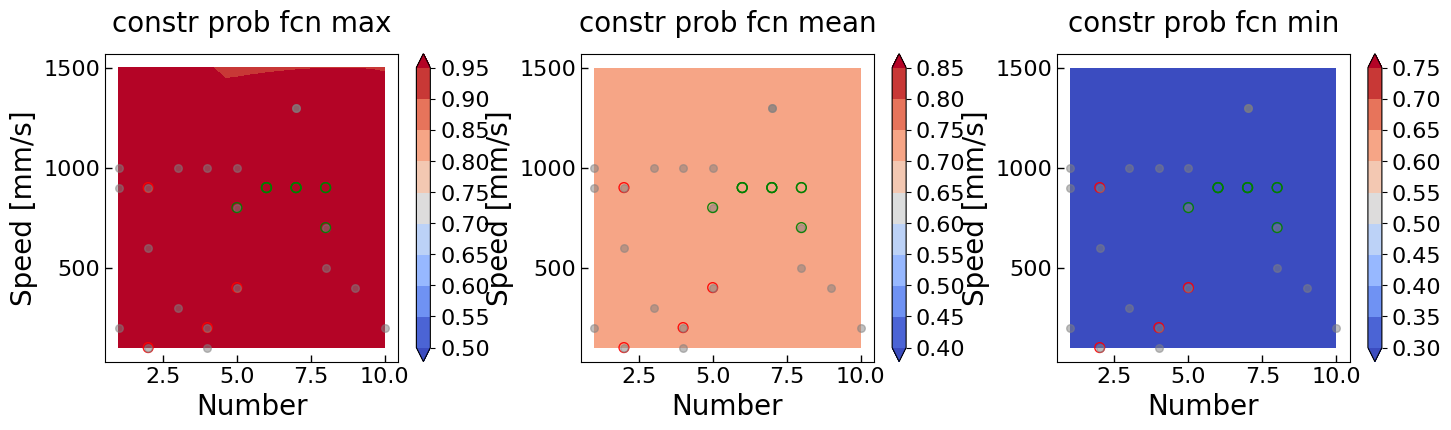

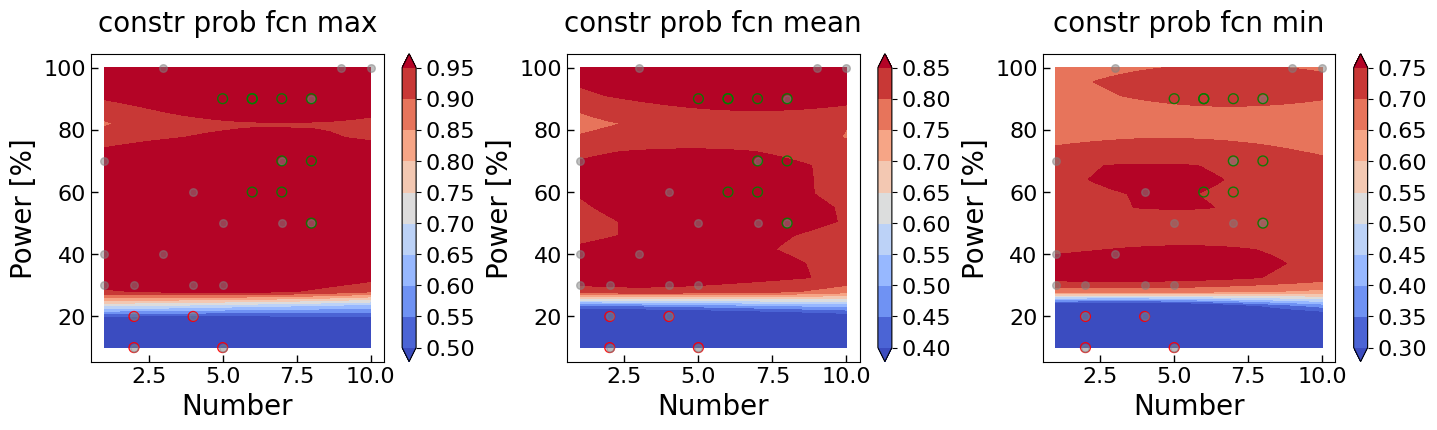

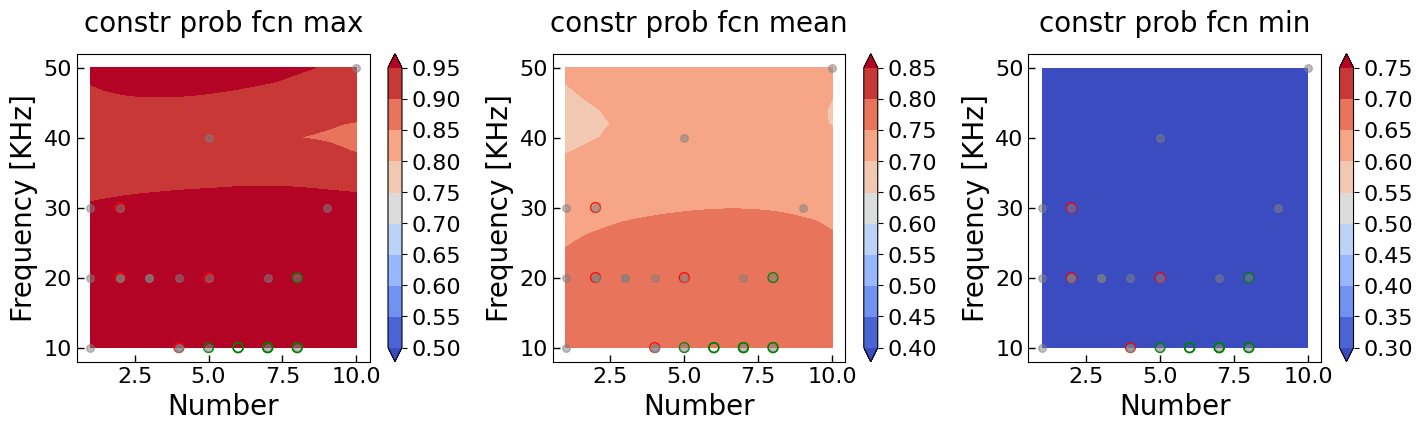

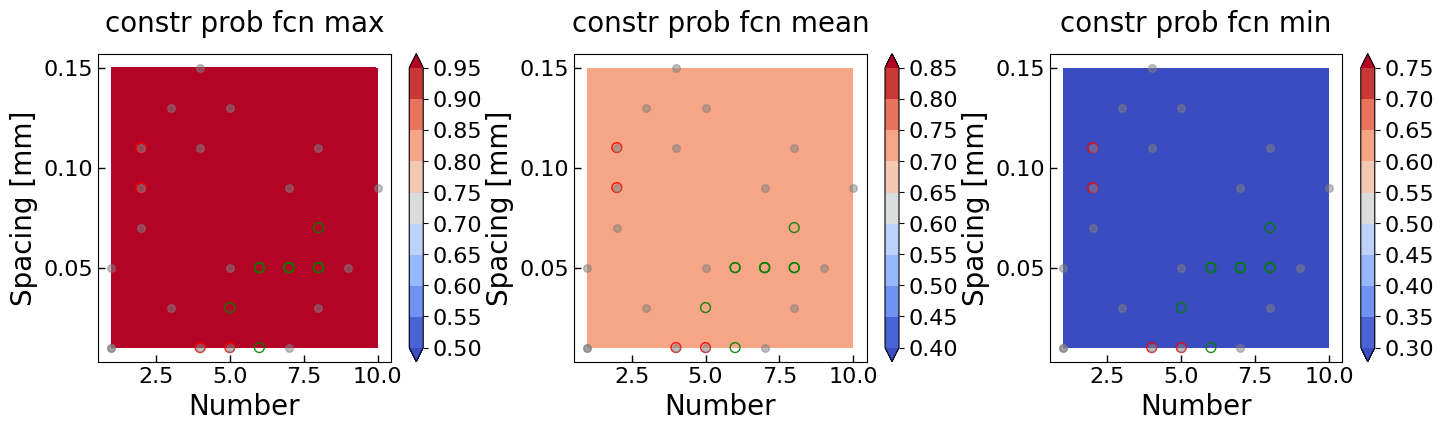

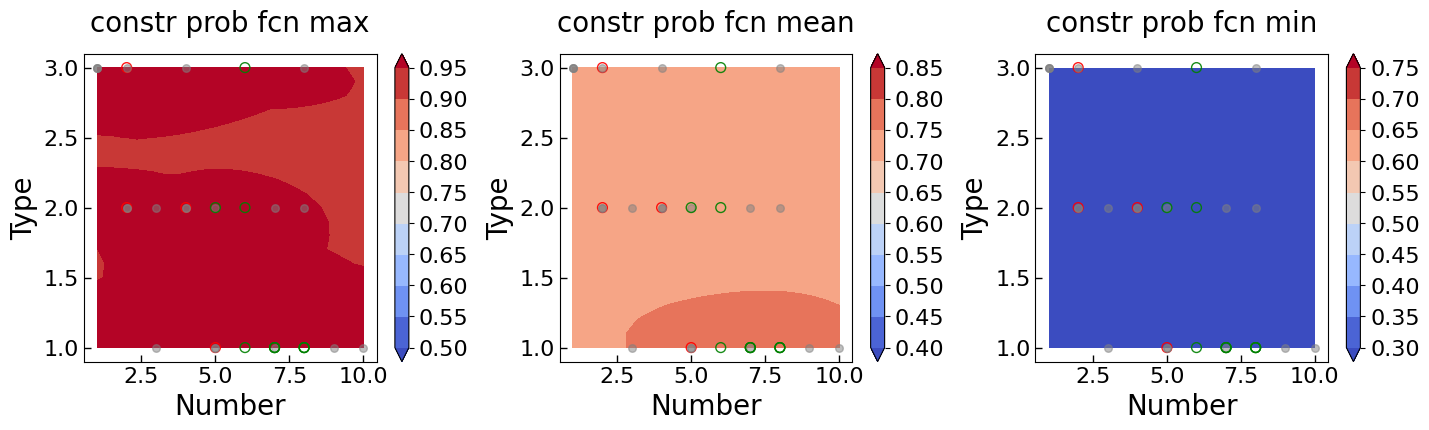

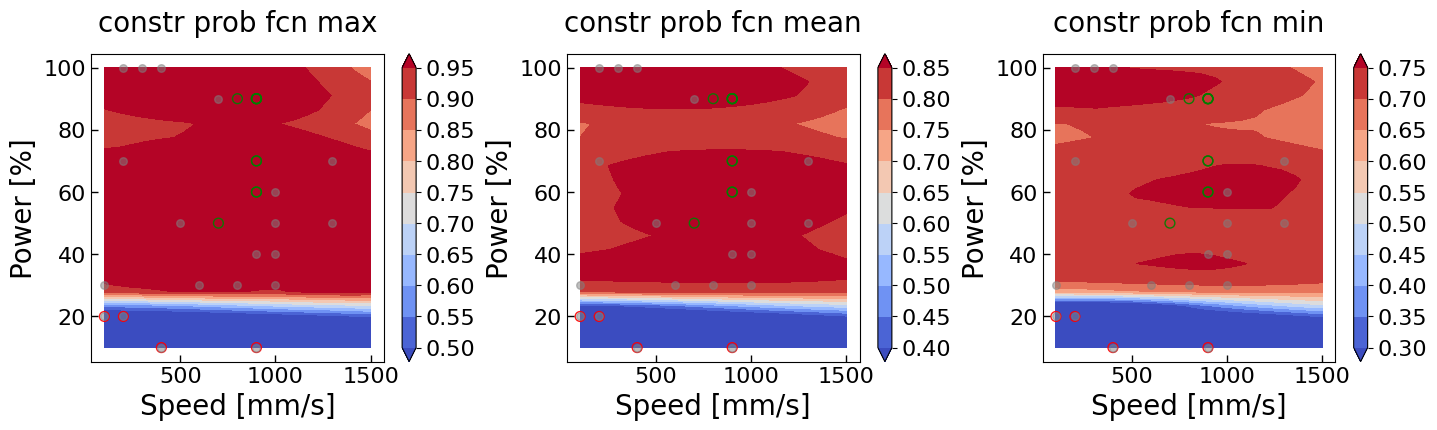

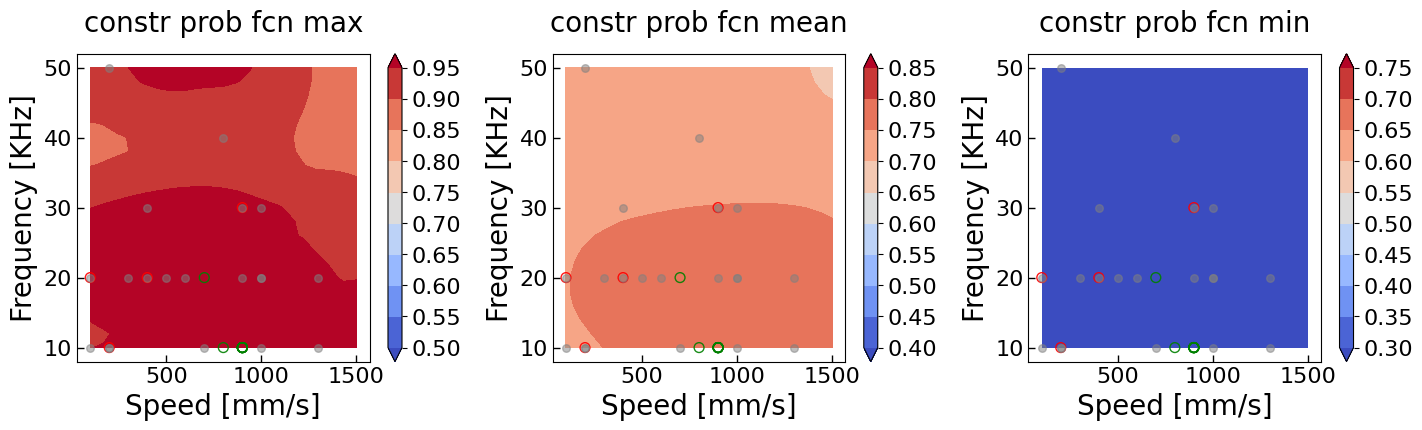

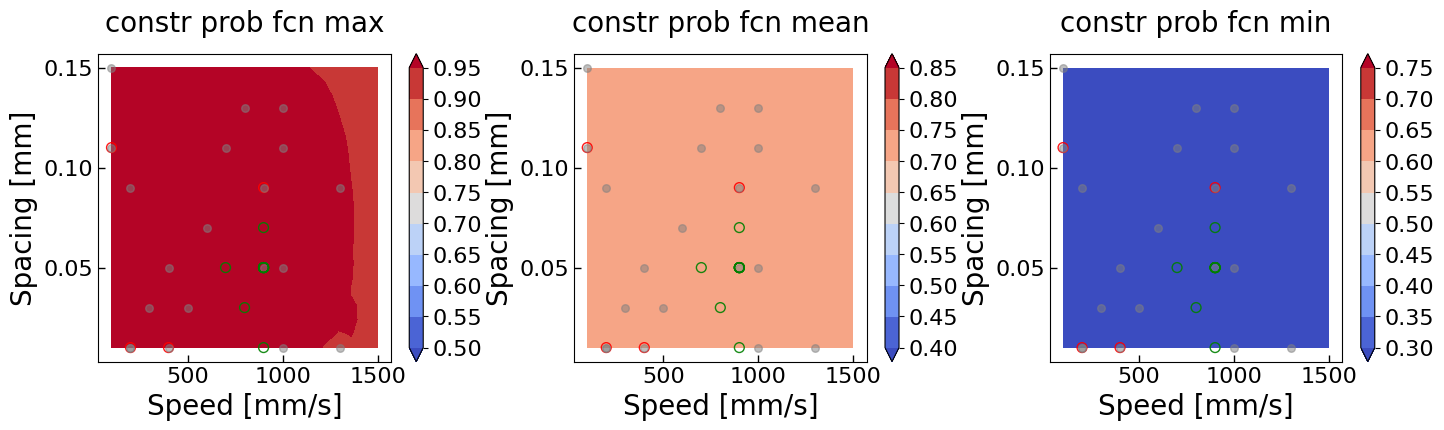

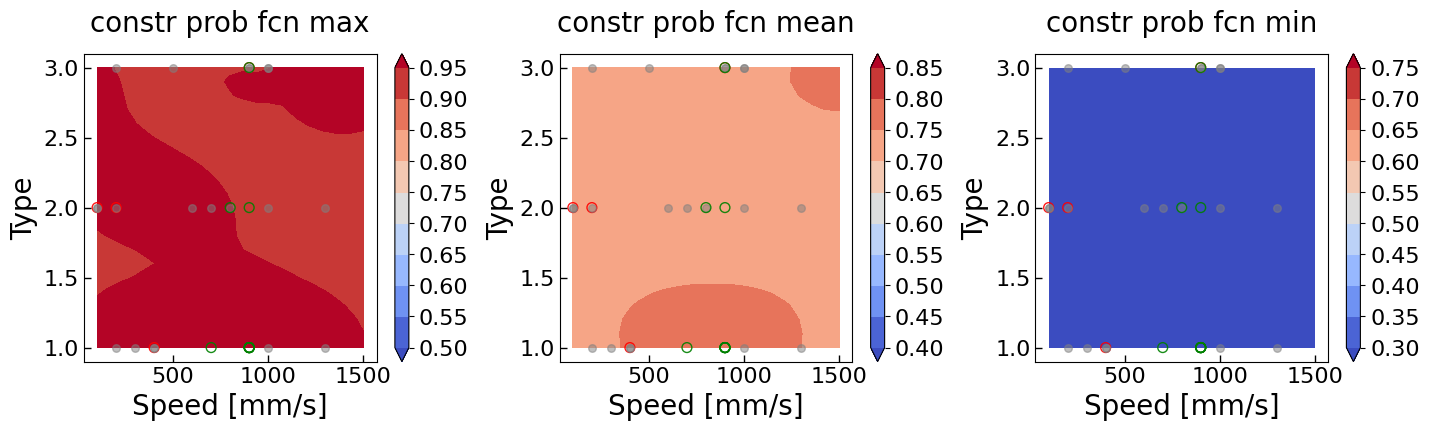

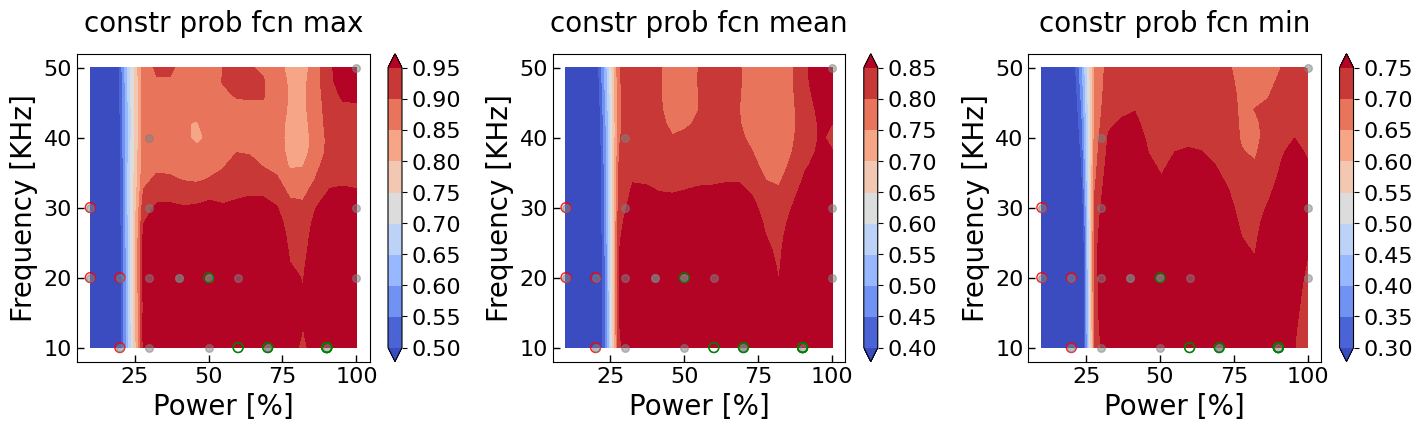

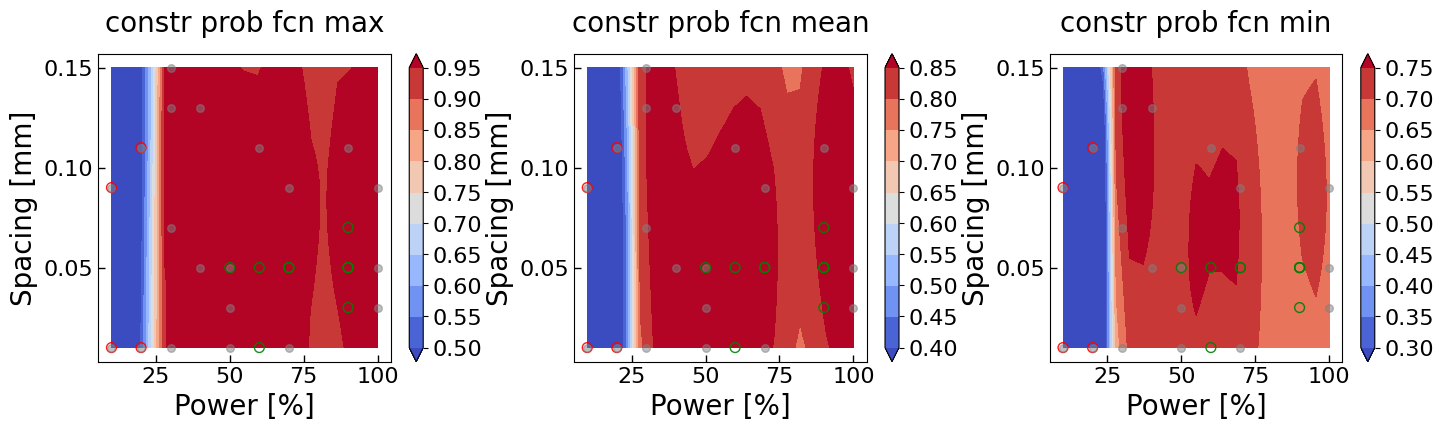

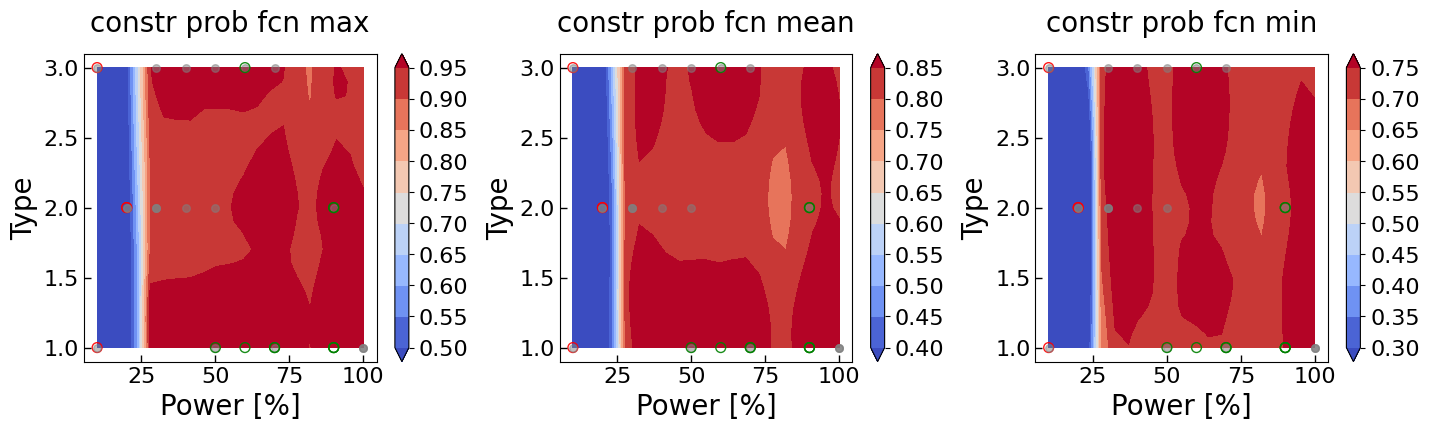

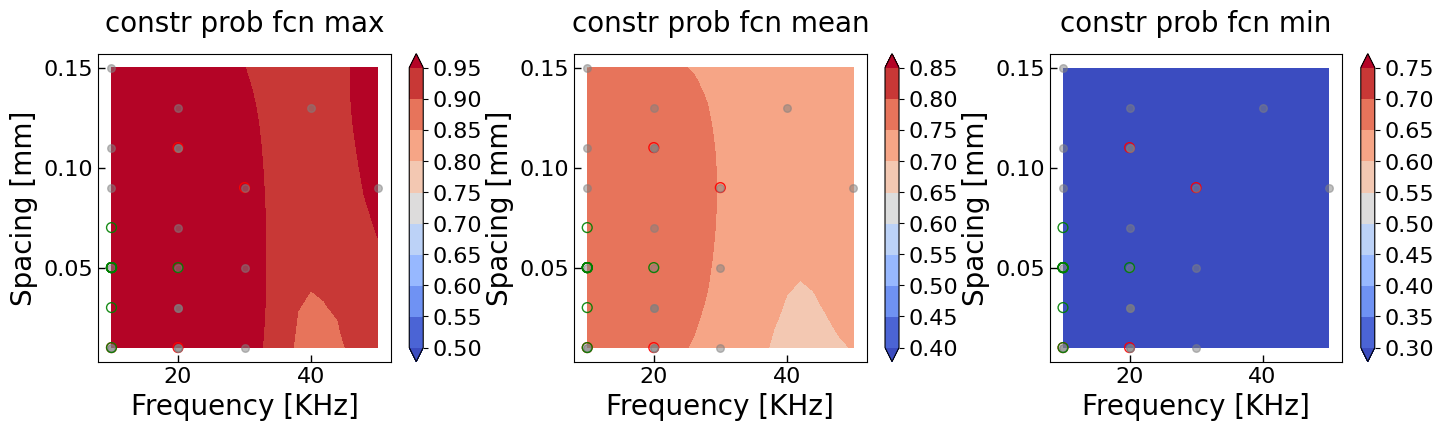

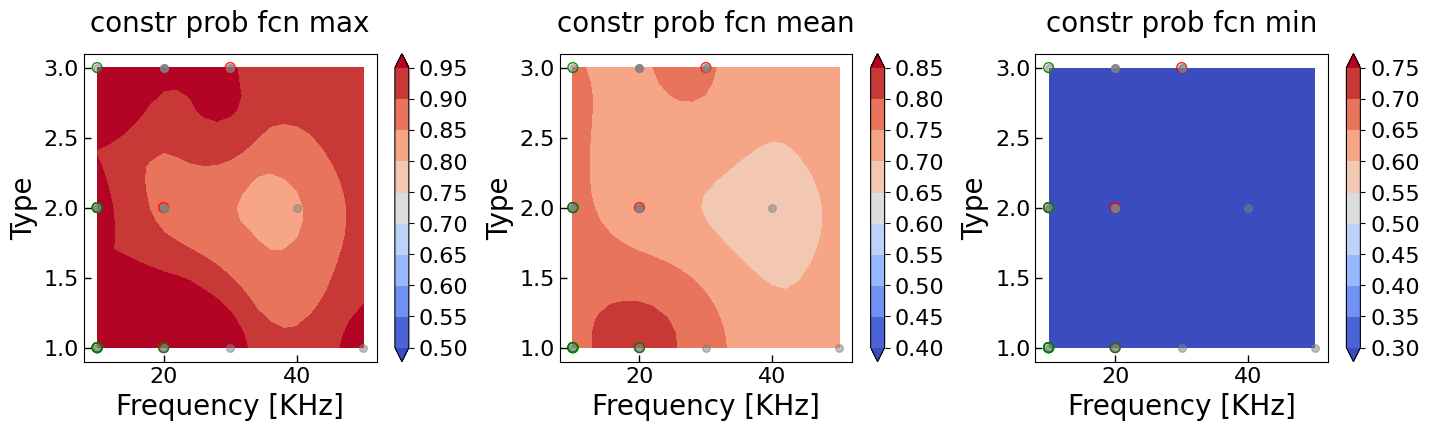

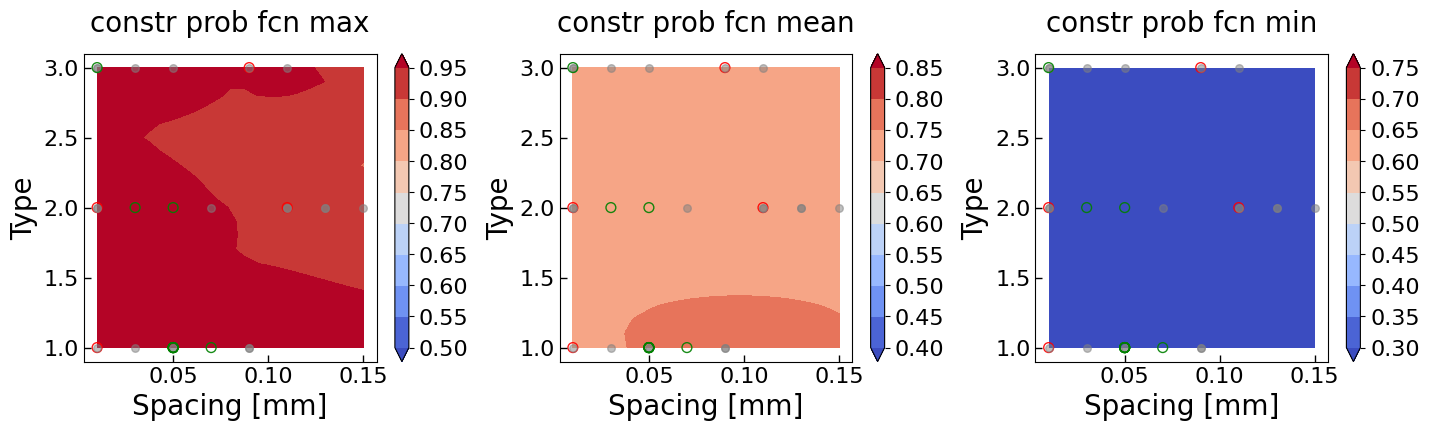

In [27]:
design = RandomDesign(parameter_space)
x_sampled = design.get_samples(200)
x_columns = df_film.iloc[:,1:7].columns
for i in range(input_dim):
    for j in range(input_dim-i-1):
        ind1 = i
        ind2 = j+i+1
        n_steps =21
        x1x2y_pred, x1x2y_var =[[],[]]
        for x1 in np.linspace(0, 1, n_steps):
            for x2 in np.linspace(0, 1, n_steps):
                x_temp = np.copy(x_sampled)
                x_temp[:,ind1] = x1
                x_temp[:,ind2] = x2
                yc_pr = f_cons_pr(x_temp)
                x1_org = x_denormalizer(x_temp)[0,ind1]
                x2_org = x_denormalizer(x_temp)[0,ind2]
                x1x2y_pred.append([x1_org, x2_org, np.max(yc_pr), np.mean(yc_pr), np.min(yc_pr)])
                
        x1c = np.array(x1x2y_pred, dtype=object)[:,0].reshape(n_steps, n_steps)
        x2c = np.array(x1x2y_pred, dtype=object)[:,1].reshape(n_steps, n_steps)
        yc_pr_max = np.array(x1x2y_pred, dtype=object)[:,2].reshape(n_steps, n_steps)
        yc_pr_mean = np.array(x1x2y_pred, dtype=object)[:,3].reshape(n_steps, n_steps)
        yc_pr_min = np.array(x1x2y_pred, dtype=object)[:,4].reshape(n_steps, n_steps)

        fs = 20
        title_pad = 16
        
        fig,axes = plt.subplots(1, 3, figsize=(17, 4), sharey = False, sharex = False)
        colorbar_offset = [0.5, 0.4, 0.3]
        for ax, y, c_offset in zip(axes, [yc_pr_max, yc_pr_mean, yc_pr_min],colorbar_offset):
            c_plt1 = ax.contourf(x1c, x2c, y,levels = np.arange(10)*0.05+c_offset, cmap='coolwarm', extend = 'both')# 
            cbar = fig.colorbar(c_plt1, ax= ax)
            cbar.ax.tick_params(labelsize=fs*0.8)
            ax.scatter(x_denormalizer(Xc[Yc[:,-1]==0])[:, ind1], 
                   x_denormalizer(Xc[Yc[:,-1]==0])[:, ind2], 
                   s = 50, facecolors='none', alpha = 0.9, edgecolor = 'red')
            ax.scatter(x_denormalizer(Xc)[:, ind1], 
                       x_denormalizer(Xc)[:, ind2], 
                       s = 30, facecolors='gray', alpha = 0.5, edgecolor = 'gray')
            ax.scatter(x_denormalizer(X_new)[:, ind1], 
                       x_denormalizer(X_new)[:, ind2], 
                       s = 50, facecolors='none', alpha = 0.9, edgecolor = 'green')

            ax.set_xlabel(str(x_columns[ind1]), fontsize = fs)
            ax.set_ylabel(str(x_columns[ind2]), fontsize = fs)

            x1_delta = (np.max(x1c)-np.min(x1c))*0.05
            x2_delta = (np.max(x2c)-np.min(x2c))*0.05
            ax.set_xlim(np.min(x1c)-x1_delta, np.max(x1c)+x1_delta)
            ax.set_ylim(np.min(x2c)-x2_delta, np.max(x2c)+x2_delta)
            ax.tick_params(direction='in', length=5, width=1, labelsize = fs*.8, grid_alpha = 0.5)


        axes[0].set_title('constr prob fcn max', pad = title_pad, fontsize = fs)
        axes[1].set_title('constr prob fcn mean', pad = title_pad, fontsize = fs)
        axes[2].set_title('constr prob fcn min', pad = title_pad, fontsize = fs)
        plt.subplots_adjust(wspace = 0.3)
        plt.show()